# MediaPipe Face Landmarker — DIMER guided task-inference notebook (standalone)

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/kurtvalcorza/mediapipe-face-landmarker-pipeline) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/mediapipe-face-landmarker-pipeline/blob/main/tutorials/mediapipe_face_landmarker_colab.ipynb) [![Upstream](https://img.shields.io/badge/Upstream-google--ai--edge%2Fmediapipe-181717?style=flat&logo=github&logoColor=white)](https://github.com/google-ai-edge/mediapipe) [![Model card](https://img.shields.io/badge/Upstream%20model%20card-Face%20Mesh%20V2-4285F4?style=flat)](https://storage.googleapis.com/mediapipe-assets/Model%20Card%20MediaPipe%20Face%20Mesh%20V2.pdf) [![License](https://img.shields.io/badge/License-Apache--2.0-blue.svg)](https://www.apache.org/licenses/LICENSE-2.0)

**Profile:** `TASK-INFERENCE`  
**Mode:** `GUIDED`  
**Notebook specification:** DIMER Notebook Specification 2.2 — **standalone** (§4)  
**Capability:** 478-point 3D facial landmark estimation, 52 blendshape scores and a 4 × 4 facial transformation matrix per face from a still image or a frame sequence, with landmark evaluation against annotated faces, robustness and blendshape sanity checks, and a CSV/JSON output contract

**This notebook is standalone.** Section 2 carries the repository's package (4 modules under `src/mediapipe_face_landmarker_pipeline/` and the pinned sample manifest, at revision `e49deff733c8`), the stage runner, the hash-locked requirements (19 packages), the pinned bundle manifest and the licence, and verifies every carried file against its SHA-256 before use, so the notebook keeps working after export even if the repository changes or disappears. Nothing is installed into the notebook kernel: a pinned `uv` (checked by size and SHA-256) builds an isolated Python environment from the lock with `--require-hashes`, and every stage runs there in its own process, so the hosted runtime's own packages are never replaced and no restart is needed. Its only external dependencies are PyPI, the managed CPython build that `uv` downloads, Google Cloud Storage for the task bundle at the immutable object generation `1683136941916318` (~3.8 MB, digest-verified before loading), and the public sample faces named in the Prerequisites. It was generated by `tools/build_notebook.py` (build_notebook.py/3.0-cpu); edit the repository and regenerate rather than editing cells.

**Run all:** Selecting **Run all** in a fresh Linux x86_64 runtime — a **CPU** runtime is enough; no GPU is used — builds an isolated Python environment from the carried hash-locked requirements (`mediapipe`, `numpy`, `pillow` and their dependencies) without touching the notebook kernel's own packages, then runs each stage below in its own process: it stages and digest-verifies the pinned 3.76 MB MediaPipe Face Landmarker task bundle from Google Cloud Storage, fetches 214 public face photographs and 112 annotation files (about 103 MB, every file pinned by size and SHA-256), validates every image and demonstrates the refusals, runs the task on one photograph and writes the full output contract, measures landmark accuracy on 102 annotated faces against two mean-shape baselines, measures robustness under rotation, downscaling, blur, brightness and JPEG compression, sanity-checks the blendshape scores on 102 neutral/smiling pairs, processes ten new composite faces and a 30-frame sequence in VIDEO mode, and writes one provenance record. The default path needs no repository clone, no DIMER worker or service, no credential, no upload dialog, no configuration edit and no runtime restart (NOTEBOOK_SPEC 2.2 §5). In the one local CPU run recorded for this revision (a 4-CPU Linux x86_64 container, not Colab) the model stages took under two minutes after the environment was built; a hosted Colab run has not yet been recorded.

**Bring Your Own Data:** After the canonical path completes, set `USE_BYOD = True` in Section 11 and run that cell to process your own image, or a zip of up to 20 images, through the same validation, inference and output contract (landmarks CSV, blendshapes CSV, transformation matrices JSON, overlays and a result record). Set `BYOD_PATH` to a file already in the runtime to skip the upload dialog, and `BYOD_NUM_FACES` (1..10) for group photographs. **Faces are personal data, and landmarks and blendshapes derived from them can be biometric data:** upload only images you are authorised to process in this runtime. Uploaded files and every output stay inside this runtime; nothing is sent to any service. BYOD is optional and never part of the default path.

The MediaPipe Face Landmarker (Google, 2023) is a fixed, pretrained pipeline of three small networks shipped together as one *task bundle*: a BlazeFace short-range **face detector** (Bazarevsky et al., 2019) finds each face and its rotation; a **face-mesh network** (Kartynnik et al., 2019; Grishchenko et al., 2020) predicts 478 landmarks — 468 points on the facial surface plus 10 iris points — in normalised image coordinates with a relative depth `z`; a **blendshape network** turns 146 of those landmarks into 52 scores in [0, 1] (`_neutral` plus 51 expression coefficients such as `jawOpen` or `mouthSmileLeft`); and the canonical-face geometry in the bundle yields a **facial transformation matrix** from a canonical 3D face to the camera. The `mediapipe` Tasks API (Lugaresi et al., 2019) runs it on the CPU.

Three facts shape everything this notebook measures. **Nothing is trained here:** the bundle is a fixed edge model, so this is a task-inference notebook — it evaluates and uses the model, it does not adapt it. **Landmarks have ground truth only where someone annotated it:** the dataset authors placed 189 points on each of 102 photographs, and 14 of them have an unambiguous MediaPipe counterpart; the notebook measures those 14, normalised by the distance between the eyes, beside two baselines that use no landmark network. **Blendshape scores have no ground truth here:** they drive an avatar rig and are not calibrated probabilities, so the notebook only checks that they move in the expected direction between a neutral and a smiling photograph of the same person — a sanity check, not an evaluation.

**This model does not recognise or identify people.** It outputs geometry and expression scores, not an identity, and the notebook never compares faces with each other. Faces are nevertheless personal data, and landmarks and blendshapes derived from them can be biometric data; the sample faces here were published under CC BY 4.0 by researchers whose participants gave signed consent for research and illustration use.

**Learning objectives:** by the end of this notebook you will be able to —

1. **Explain** the Input → Model → Output contract of the Face Landmarker: what a landmark, a blendshape score and a facial transformation matrix are, and which of the three networks in the bundle produces each (Sections 3, 5).
2. **Diagnose** an invalid input from a validation refusal, and **identify** what validation can and cannot check about a face image (Section 4).
3. **Interpret** a normalised mean error (NME) against annotated landmarks, and **compare** the model with two mean-shape baselines and across self-reported groups without over-reading small groups (Section 6).
4. **Distinguish** a detection from a correct localisation, using consistency and annotation errors under controlled perturbations (Section 7).
5. **Explain** why blendshape scores are not probabilities, and **apply** a paired sanity check whose expected direction is stated before it runs (Section 8).
6. **Apply** the same output contract to new images and a frame sequence, and **compare** IMAGE and VIDEO running modes (Section 9).
7. **Predict**, run and **explain** the effect of one change — the rotation angle — in an optional activity (Section 12).
8. **Write** an evidence-based conclusion that names the baseline, the main failure mode and the limits of 102 studio photographs (Conclusion).

**This notebook does not demonstrate:** face recognition, identification, verification or any comparison between faces (the model does none of these); emotion, age, gender or ethnicity inference (the self-reported attributes of the sample are used only to break down the error); fine-tuning or adaptation (the bundle is a fixed edge model); GPU or other delegates; the `live stream` running mode; hand, pose or full-body landmarks; and any claim that a blendshape score is a calibrated probability that an expression is present.

## How to use this notebook

**Who this notebook is for.** Learners who can open a hosted notebook (Google Colab or Jupyter), run cells in order and read short Python, and who want to see how a pretrained face-landmark model is evaluated honestly and used safely. No prior experience with face landmarks is assumed: each term is explained where it is first needed, and the glossary below collects them. No GPU is needed — a CPU runtime is enough. The **Prerequisites** give the details.

**Running it.** In Colab, keep the default CPU runtime and choose *Runtime → Run all*. The default path needs no edit, no upload, no account, no token and no runtime restart. Section 2 builds an isolated environment from hash-locked packages, which takes the longest; the model stages that follow take seconds to a minute each on a CPU. You can also run the notebook one cell at a time with *Shift + Enter*.

**Where the code runs.** The notebook kernel installs nothing and imports no model library. Each learner cell calls `run_stage('…')`, which runs one stage of the carried stage runner in its own process with the isolated environment's Python, streams what it prints, and stops the notebook with the stage's own error message if it fails. Stages hand results to each other only through files in the run directory — the verified bundle, the verified sample faces and JSON records. MediaPipe's own informational log lines (for example *Created TensorFlow Lite XNNPACK delegate for CPU*) go to `logs/<stage>.native.log` in the run directory instead of the cell output.

**Two kinds of cell.** *Learner cells* (Sections 4–12) are the machine-learning workflow; each runs one stage and prints compact dictionaries for you to read. *Infrastructure cells* (Sections 1–3: the runtime check, the carried code, the isolated install and the pinned-bundle staging) are collapsed and titled **Infrastructure**. You may run them without studying their implementation: they exist for reproducibility and provenance, not as prerequisite machine-learning knowledge. Open one with *Show code* if you are curious.

**Form controls.** Two learner cells start with fields that Colab renders as a form: `USE_BYOD`, `BYOD_PATH` and `BYOD_NUM_FACES` (Section 11), and `RUN_ACTIVITY` and `ACTIVITY_ROTATION` in the optional activity (Section 12). Leave them at their defaults for the first run: the notes and sample answers describe the default path.

**Section tags.** Each numbered heading carries one tag. **[Concept]** — what the model does and why. **[Evaluation practice]** — how the evidence is produced and how to read it. **[Engineering]** — reproducibility, provenance and packaging.

**Predict, then check.** Before each principal result a **Predict before running** prompt asks you to commit to an expectation; after it, **What to notice** describes normal output and a collapsed **Check your reasoning** answer follows each checkpoint. Write your own answer first, then open it. Exact numbers can vary slightly between CPUs and library builds, so the notes describe the shape of a normal result rather than fixed values.

## The task: Input → Model/System → Output

| Stage | Input | Model / system | Output |
|---|---|---|---|
| **Detect** | an RGB image | BlazeFace short-range face detector (`face_detector.tflite`) | a box and a rotation per face, up to `num_faces` |
| **Landmarks** | the face region, rotated upright | face-mesh network (`face_landmarks_detector.tflite`) | 478 landmarks: `x`, `y` as fractions of the image width and height, `z` a relative depth on the same scale as `x` |
| **Blendshapes** | 146 of the landmarks | blendshape network (`face_blendshapes.tflite`) | 52 named scores in [0, 1] (`_neutral` + 51 coefficients) |
| **Pose** | the landmarks | canonical-face geometry (`geometry_pipeline_metadata_landmarks.binarypb`) | a 4 × 4 facial transformation matrix (canonical face → camera) |
| **Evaluation** | 102 annotated photographs | 14 landmarks compared with the authors' annotation, beside two mean-shape baselines | NME per face, detection rate, failure rate, group breakdown |

Every output row carries an `image_id` and a `face_id`, and every landmark row a `landmark_id` (0..477), so a value can always be traced to the image, face and mesh point it came from.

## Roadmap

| Section | Tag | What happens | What you read |
|---|---|---|---|
| 1. Check the runtime | [Engineering] | Linux x86_64 and disk checked; a fresh run directory | the machine and directories |
| 2. Carry the code, install the runtime | [Engineering] | carried files verified; an isolated hash-locked environment | versions |
| 3. Pin, stage and verify the bundle | [Engineering] | the task bundle downloaded and digest-checked, member by member | the four members |
| 4. Sample faces and validation | [Evaluation practice] | 214 photographs fetched and validated; four refusals | counts, refusals |
| 5. Run the task on one photograph | [Concept] | landmarks, blendshapes, matrix; `num_faces`; a no-face image | the output contract |
| 6. Landmark accuracy | [Evaluation practice] | NME on 102 annotated faces vs two baselines; groups | the principal result |
| 7. Robustness | [Evaluation practice] | rotation, scale, blur, brightness, JPEG on 20 faces | where it breaks |
| 8. Blendshape sanity check | [Concept] | neutral vs smiling photographs of the same 102 people | the paired direction |
| 9. New images and VIDEO mode | [Concept] | ten composite faces exported; a 30-frame sequence | new-data outputs |
| 10. Export and provenance | [Engineering] | one result record; every file listed | the provenance |
| 11. Bring your own data (optional) | [Engineering] | your image or zip through the same contract (off by default) | your outputs |
| 12. Optional activity | [Concept] | change the rotation angle (off by default) | your comparison |
| Troubleshooting | [Engineering] | common hosted-runtime failures | when something fails |
| Interpretation and conclusion | [Evaluation practice] | limits and an evidence-based conclusion | your conclusion |

**Fast path.** Short on time? Run all, then read Sections 5, 6 and 8 and the conclusion: they carry the principal results. The canonical path ends with Section 10; Sections 11 and 12 change nothing unless you switch them on.

<details>
<summary><strong>Glossary</strong> — open when a term is unfamiliar</summary>

| Term | Meaning in this notebook |
|---|---|
| **Landmark** | A named point on the face, such as the inner corner of the left eye, given as image coordinates. |
| **Face mesh** | MediaPipe's fixed set of 468 surface landmarks; point *k* is always the same place on every face. |
| **Iris landmarks** | Points 468–477: five per iris; 468 and 473 are the iris centres. |
| **Normalised coordinates** | `x` and `y` as fractions of the image width and height (0..1); multiply by the width or height for pixels. |
| **`z` (relative depth)** | Depth of a landmark relative to the face centre, on roughly the same scale as `x`; smaller is nearer the camera. Not a metric distance. |
| **Subject's left / image left** | MediaPipe names points for the person in the photograph; in an unmirrored photo the subject's right eye is on the image left. |
| **Blendshape** | A coefficient of a facial-animation rig (for example `jawOpen`); the 52 scores here drive an avatar, they are not probabilities. |
| **Facial transformation matrix** | A 4 × 4 matrix mapping a canonical 3D face model into the camera's coordinate frame: head rotation and position. |
| **Task bundle** | MediaPipe's `.task` file: a zip of the models and metadata one task needs. |
| **Face detector** | The first network: finds faces and their rotation; the mesh network runs only on detected faces. |
| **IMAGE / VIDEO mode** | IMAGE runs the detector on every image; VIDEO reuses the previous frame's landmarks to place the face region (tracking) and needs increasing timestamps. |
| **Annotation template** | The dataset authors' 189 hand-placed points per photograph (`.tem` file); 14 are matched to mesh points. |
| **Inter-ocular distance (IOD)** | Distance between the two eye centres, each the midpoint of that eye's corners, from the annotation. |
| **NME** | Normalised mean error: the mean distance between predicted and annotated points divided by the IOD. 0.02 means 2 % of the eye distance. |
| **Failure rate at 0.10** | The share of faces whose NME exceeds 0.10. |
| **CED** | Cumulative error distribution: for each NME value, the share of faces at or below it. |
| **Mean-shape baseline** | A prediction that ignores the image content: the average annotated shape, placed in the image (or in the detector's box). |
| **Leave-one-out** | Each face's baseline is computed from the other faces only, so a face never predicts itself. |
| **Detection rate** | The share of images in which the model returned a face. |
| **Consistency NME** | The prediction on a perturbed image, mapped back to the original coordinates, compared with the prediction on the original. |
| **Rank AUC** | The chance that a randomly chosen smiling photograph scores higher than a randomly chosen neutral one; 0.5 is chance. |
| **Sign test** | A test of whether "higher in the pair" happens more often than a coin flip would give. |
| **Biometric data** | Measurements of a person's body, such as face geometry, that can single the person out; protected in many jurisdictions. |
| **Digest (SHA-256)** | A fingerprint of a file's bytes; a single changed byte changes it. |
| **Hash-locked environment** | A separate Python environment built from a requirements file that pins every package to one version and one set of SHA-256 digests. |
| **Stage** | One step of the workflow run as its own process by `run_stage`. |
| **BYOD** | Bring Your Own Data: an optional switch to run the same contract on your own images. |

</details>

## Prerequisites

- **Runtime:** a fresh **Linux x86_64** runtime — a Google Colab CPU runtime is enough, and so is Kaggle or a Linux Jupyter kernel. The kernel's own Python version does not matter: the notebook installs nothing into it, and runs every stage with CPython 3.12.12 in an isolated environment built from 19 hash-locked packages (`mediapipe` 1.0.0, `numpy` 2.5.3, `pillow` 12.3.0). Inference runs on the CPU through TFLite's XNNPACK delegate in the bundle's float16 weights; no GPU or other accelerator is used, and a GPU runtime gives no speed-up here. About 0.2 GB of disk is needed for the bundle and the sample faces and about 1.5 GB for the isolated environment.
- **Knowledge:** what an image coordinate is (x to the right, y down, in pixels or as a fraction of the width and height), what a mean and a median are, and how to read a Python dictionary printed by a cell. No prior experience with face landmarks is assumed: each term is explained where it is first needed, and the glossary collects them.
- **Model file:** one MediaPipe task bundle, `face_landmarker.task` (a stored zip of three TFLite flatbuffers and one binary protobuf). TFLite flatbuffers are data read by the TFLite interpreter; nothing is unpickled and no code is downloaded with the model. The bundle is released under Apache-2.0.
- **Data contract:** an image Pillow can decode, 64..8192 px on each side, at most 40,000,000 pixels and 50 MB; it is converted to 8-bit RGB (any conversion is reported) and an EXIF orientation is applied (reported). `num_faces` is 1..10. Validation is structural: it cannot tell whether an image contains a face — the detector decides, and zero faces is a valid result.
- **Sample data:** the 102 neutral and 102 smiling front-facing photographs of the Face Research Lab London Set (DeBruine & Jones, 2017; 1350 × 1350 px; CC BY 4.0) with the authors' 189-point annotation templates and the participants' self-reported age, gender and ethnicity, and ten composite faces (DeBruine, 2016; CC BY 4.0), each the average of four London Set faces. All participants gave signed consent for their images to be used in lab-based and web-based studies and to illustrate research. The files are read from the public GitHub repository `debruine/webmorphR.stim` at one immutable commit, and each is pinned by size and SHA-256.
- **Privacy:** Faces are personal data and the landmarks and blendshapes derived from them can be biometric data. Do not upload confidential, restricted, sensitive or personal images — including photographs of people who have not agreed to this processing — unless you are authorised to process them in this runtime. Nothing in this notebook sends an image or a result to any service; the default path uploads nothing.
- **External access:** Google Cloud Storage (`storage.googleapis.com`), to fetch the pinned task bundle `mediapipe-models/face_landmarker/face_landmarker` version `float16/1` (~3.8 MB) at object generation `1683136941916318`; `raw.githubusercontent.com`, for the digest-pinned sample faces; PyPI (`files.pythonhosted.org`), for the pinned `uv` wheel and the 19 hash-locked packages; and the managed CPython build (python-build-standalone) that `uv` downloads for the isolated environment. No repository clone and no credentials are required; nothing is installed from this repository.

## 1. Check the runtime · [Engineering]

> **Infrastructure.** The code cells in Sections 1–3 are collapsed. You may run them without studying their implementation; they exist for reproducibility and provenance. The learning activities start in Section 4.

**Input:** a fresh hosted runtime. **System:** checks that it is Linux x86_64 with enough free disk, and creates a new run directory. **Output:** the machine, the CPU count and the directories this run will use. Each run writes to a new directory under `outputs/mediapipe_face_landmarker/`, so an earlier export cannot be mistaken for a current result. The verified bundle and sample faces are kept in `weights/` and reused by a later run.

In [1]:
# @title Infrastructure: check the runtime and disk; create a fresh run directory
import hashlib
import json
import os
import platform
import shutil
import subprocess
import tempfile
import time
import uuid
from pathlib import Path

SESSION_START = time.perf_counter()
if platform.system() != 'Linux' or platform.machine() != 'x86_64':
    raise RuntimeError('This notebook needs a Linux x86_64 runtime (Google Colab, Kaggle, or a Linux x86_64 Jupyter kernel): its locked environment is built for manylinux x86_64 wheels. A CPU runtime is enough; no GPU is used.')
STEM = 'mediapipe_face_landmarker'
ROOT = Path.cwd() / 'outputs' / STEM / uuid.uuid4().hex[:12]
ROOT.mkdir(parents=True)
WEIGHTS = Path.cwd() / 'weights'
WEIGHTS.mkdir(exist_ok=True)
ENV_ROOT = Path(tempfile.gettempdir()) / (STEM + '_env_' + ROOT.name)
staged_gib = sum(p.stat().st_size for p in WEIGHTS.rglob('*') if p.is_file()) / 1024**3
need = {'weights': max(0.0, 0.2 - staged_gib), 'environment': 1.5}
free = {'weights': shutil.disk_usage(WEIGHTS).free / 1024**3, 'environment': shutil.disk_usage(tempfile.gettempdir()).free / 1024**3}
if os.stat(WEIGHTS).st_dev == os.stat(tempfile.gettempdir()).st_dev:
    short = free['weights'] < need['weights'] + need['environment']
else:
    short = free['weights'] < need['weights'] or free['environment'] < need['environment']
if short:
    raise RuntimeError(f'Not enough free disk: need about {need} GiB, free {free} GiB. Start a fresh runtime (see Troubleshooting).')
print({'machine': platform.machine(), 'cpus': os.cpu_count(), 'kernel_python': platform.python_version(), 'run_directory': str(ROOT), 'weights': str(WEIGHTS), 'environment': str(ENV_ROOT), 'free_gib': {k: round(v, 1) for k, v in free.items()}})

{'machine': 'x86_64', 'cpus': 2, 'kernel_python': '3.13.15', 'run_directory': '/content/outputs/mediapipe_face_landmarker/6fc1c4b2efed', 'weights': '/content/weights', 'environment': '/tmp/mediapipe_face_landmarker_env_6fc1c4b2efed', 'free_gib': {'weights': 205.3, 'environment': 205.3}}


**Expected result:** one dictionary naming the machine (`x86_64`), the number of CPUs, the kernel's Python version, the run directory, the weights directory, the isolated environment's directory and the free disk. If the cell stops with a platform or disk message, see **Troubleshooting**.

## 2. Carry the code and install the locked runtime · [Engineering]

> **Infrastructure.** The next two code cells are collapsed. The first **is** the repository's code, carried so that this notebook works on its own; the second builds the environment every stage runs in.

The first cell holds, as text, the files the workflow needs: the package's four modules under `src/mediapipe_face_landmarker_pipeline/` (identity constants, bundle verification and staging, validation, the landmarker wrapper and output contract, the sample loader and the metrics), the pinned sample manifest, the stage runner `tutorial_stages.py`, the hash-locked `requirements.txt` (19 packages), the bundle manifest and the licence. It writes each file into the run directory and checks its SHA-256 against `CARRIED_HASHES`, stopping on any mismatch. The text is the repository's files byte for byte; the repository's parity test (`tests/test_notebook_parity.py`) fails whenever the two diverge, so what runs here is what the repository tests. Nothing in this cell runs a model.

In [2]:
# @title Infrastructure: write and verify the carried package, stage runner, lock and manifests
CARRIED_FILES = {'src/mediapipe_face_landmarker_pipeline/__init__.py': '"""DIMER pipeline for the MediaPipe Face Landmarker task bundle (478 3D landmarks, 52 blendshapes, transformation matrix).\n\nImporting the package imports NumPy and Pillow only; ``mediapipe`` is imported when a landmarker is built, so the bundle\nand input checks run (and refuse) without it.\n"""\n\nfrom __future__ import annotations\n\nfrom .metrics import (\n    FAILURE_NME,\n    PERTURBATION_KINDS,\n    apply_affine,\n    bootstrap_ci,\n    inter_ocular_distance,\n    invert_affine,\n    mean_shape_box,\n    mean_shape_image,\n    nme_iod,\n    paired_sanity,\n    perturb,\n    point_errors,\n    rank_auc,\n    summarize_nme,\n)\nfrom .pipeline import (\n    ARCHITECTURE_SOURCE,\n    BLENDSHAPE_FIELDS,\n    BLENDSHAPE_NAMES,\n    BUNDLE_NAME,\n    DEFAULT_CONFIDENCE,\n    EXPECTED_MEMBERS,\n    INPUT_SCHEMA,\n    LANDMARK_FIELDS,\n    MANIFEST_NAME,\n    MAX_FILE_BYTES,\n    MAX_IMAGE_PIXELS,\n    MAX_IMAGE_SIDE,\n    MAX_NUM_FACES,\n    MIN_IMAGE_SIDE,\n    MODEL_BYTES,\n    MODEL_ID,\n    MODEL_KEY,\n    MODEL_LICENSE,\n    MODEL_REVISION,\n    MODEL_SHA256,\n    MODEL_SOURCE_URL,\n    MODEL_VERSION,\n    NUM_BLENDSHAPES,\n    NUM_LANDMARKS,\n    SCORE_SEMANTICS,\n    FaceLandmarkerPipeline,\n    blendshape_rows,\n    bundle_url,\n    contact_sheet,\n    detect_face_boxes,\n    draw_overlay,\n    face_summary,\n    inspect_bundle,\n    landmark_rows,\n    matrix_records,\n    pixel_coordinates,\n    read_manifest,\n    stage_bundle,\n    validate_confidence,\n    validate_image,\n    validate_num_faces,\n    verify_bundle,\n    write_csv,\n    write_json,\n)\nfrom .samples import (\n    EYE_CORNERS,\n    LANDMARK_MAP,\n    LANDMARK_NAMES,\n    MEDIAPIPE_INDICES,\n    TEMPLATE_INDICES,\n    age_band,\n    fetch_samples,\n    load_manifest,\n    manifest_digest,\n    parse_template,\n    read_info,\n    read_template,\n    sample_records,\n    template_subset,\n)\n\n__all__ = [\n    "ARCHITECTURE_SOURCE", "BLENDSHAPE_FIELDS", "BLENDSHAPE_NAMES", "BUNDLE_NAME", "DEFAULT_CONFIDENCE", "EXPECTED_MEMBERS",\n    "EYE_CORNERS", "FAILURE_NME", "INPUT_SCHEMA", "LANDMARK_FIELDS", "LANDMARK_MAP", "LANDMARK_NAMES", "MANIFEST_NAME",\n    "MAX_FILE_BYTES", "MAX_IMAGE_PIXELS", "MAX_IMAGE_SIDE", "MAX_NUM_FACES", "MEDIAPIPE_INDICES", "MIN_IMAGE_SIDE",\n    "MODEL_BYTES", "MODEL_ID", "MODEL_KEY", "MODEL_LICENSE", "MODEL_REVISION", "MODEL_SHA256", "MODEL_SOURCE_URL",\n    "MODEL_VERSION", "NUM_BLENDSHAPES", "NUM_LANDMARKS", "PERTURBATION_KINDS", "SCORE_SEMANTICS", "TEMPLATE_INDICES",\n    "FaceLandmarkerPipeline", "age_band", "apply_affine", "blendshape_rows", "bootstrap_ci", "bundle_url", "contact_sheet",\n    "detect_face_boxes", "draw_overlay", "face_summary", "fetch_samples", "inspect_bundle", "inter_ocular_distance",\n    "invert_affine", "landmark_rows", "load_manifest", "manifest_digest", "matrix_records", "mean_shape_box",\n    "mean_shape_image", "nme_iod", "paired_sanity", "parse_template", "perturb", "pixel_coordinates", "point_errors",\n    "rank_auc", "read_info", "read_manifest", "read_template", "sample_records", "stage_bundle", "summarize_nme",\n    "template_subset", "validate_confidence", "validate_image", "validate_num_faces", "verify_bundle", "write_csv",\n    "write_json",\n]  # fmt: skip\n', 'src/mediapipe_face_landmarker_pipeline/pipeline.py': '"""MediaPipe Face Landmarker: pinned task bundle, input validation, inference and the output contract.\n\nThe upstream model is Google\'s MediaPipe Face Landmarker task bundle ``face_landmarker.task`` (float16, version 1),\npublished on Google Cloud Storage. The bundle is a stored (uncompressed) zip of three TFLite flatbuffers - a BlazeFace\nshort-range face detector, the 478-point face-mesh landmark network and the 52-output blendshape network - and a\nbinary protobuf with the canonical-face geometry used for the facial transformation matrix. It is executed by the\n``mediapipe`` Tasks API (``FaceLandmarker``) from PyPI; nothing is unpickled and no code is fetched with the model.\n\nThis module\n\n* pins the bundle by object generation, byte size, SHA-256 and the SHA-256 of each zip member, stages it from the\n  pinned generation only, and refuses on any mismatch (``stage_bundle``, ``verify_bundle``);\n* validates an image before the model runs - decodable, size and pixel ceilings, colour-mode conversion reported\n  (``validate_image``) - and the requested number of faces (``validate_num_faces``);\n* runs the landmarker in IMAGE or VIDEO mode (``FaceLandmarkerPipeline``) and turns its result into named,\n  identified rows: 478 landmarks per face (normalised x, y, z and pixel coordinates), 52 blendshape scores with names,\n  and the 4 x 4 facial transformation matrix (``landmark_rows``, ``blendshape_rows``, ``matrix_records``).\n\n``mediapipe`` is imported only inside the functions that run the model, so validation and verification work (and\nrefuse) without it.\n"""\n# ruff: noqa: E501  -- refusal messages name the rule, the limit and the corrective action in one line\nfrom __future__ import annotations\n\nimport csv\nimport hashlib\nimport io\nimport json\nimport os\nimport tempfile\nimport time\nimport urllib.request\nimport zipfile\nfrom collections.abc import Iterable, Sequence\nfrom pathlib import Path\nfrom typing import Any\n\nimport numpy as np\nfrom PIL import Image, ImageDraw, ImageOps\n\n# ---- identity (MODEL_ASSET_SPEC §4: canonical id, immutable revision, digest) ------------------------------------------\n\nMODEL_ID = "mediapipe-models/face_landmarker/face_landmarker"\nMODEL_VERSION = "float16/1"\nMODEL_REVISION = "1683136941916318"\nMODEL_LICENSE = "Apache-2.0"\nMODEL_KEY = "mediapipe-face-landmarker-float16-v1"\nMODEL_SHA256 = "64184e229b263107bc2b804c6625db1341ff2bb731874b0bcc2fe6544e0bc9ff"\nMODEL_BYTES = 3758596\nARCHITECTURE_SOURCE = "google-ai-edge/mediapipe"\nBUNDLE_NAME = "face_landmarker.task"\nMODEL_SOURCE_URL = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"\nMANIFEST_NAME = "dimer-base-manifest.json"\nDEFAULT_WEIGHTS_DIR = Path(__file__).resolve().parents[2] / "weights" / MODEL_KEY\nEXPECTED_MEMBERS = (\n    "face_detector.tflite",\n    "face_landmarks_detector.tflite",\n    "geometry_pipeline_metadata_landmarks.binarypb",\n    "face_blendshapes.tflite",\n)\nDETECTOR_MEMBER = "face_detector.tflite"\n\n# ---- output contract ---------------------------------------------------------------------------------------------------\n\nNUM_LANDMARKS = 478  # 468 face-mesh points + 10 iris points (468-472 subject\'s right iris, 473-477 subject\'s left iris)\nBLENDSHAPE_NAMES = (\n    "_neutral", "browDownLeft", "browDownRight", "browInnerUp", "browOuterUpLeft", "browOuterUpRight", "cheekPuff",\n    "cheekSquintLeft", "cheekSquintRight", "eyeBlinkLeft", "eyeBlinkRight", "eyeLookDownLeft", "eyeLookDownRight",\n    "eyeLookInLeft", "eyeLookInRight", "eyeLookOutLeft", "eyeLookOutRight", "eyeLookUpLeft", "eyeLookUpRight",\n    "eyeSquintLeft", "eyeSquintRight", "eyeWideLeft", "eyeWideRight", "jawForward", "jawLeft", "jawOpen", "jawRight",\n    "mouthClose", "mouthDimpleLeft", "mouthDimpleRight", "mouthFrownLeft", "mouthFrownRight", "mouthFunnel", "mouthLeft",\n    "mouthLowerDownLeft", "mouthLowerDownRight", "mouthPressLeft", "mouthPressRight", "mouthPucker", "mouthRight",\n    "mouthRollLower", "mouthRollUpper", "mouthShrugLower", "mouthShrugUpper", "mouthSmileLeft", "mouthSmileRight",\n    "mouthStretchLeft", "mouthStretchRight", "mouthUpperUpLeft", "mouthUpperUpRight", "noseSneerLeft", "noseSneerRight",\n)  # fmt: skip\nNUM_BLENDSHAPES = len(BLENDSHAPE_NAMES)  # 52, index 0 is the `_neutral` placeholder category\nLANDMARK_FIELDS = ("image_id", "face_id", "landmark_id", "x", "y", "z", "x_px", "y_px", "z_px")\nBLENDSHAPE_FIELDS = ("image_id", "face_id", "blendshape_index", "blendshape", "score")\nSCORE_SEMANTICS = (\n    "Blendshape scores are network outputs in [0, 1] that drive an avatar rig; they are not calibrated probabilities "\n    "that an expression is present, and the pipeline applies no threshold to them."\n)\n\n# ---- operational ceilings (VAL6) ---------------------------------------------------------------------------------------\n\nMIN_IMAGE_SIDE = 64\nMAX_IMAGE_SIDE = 8192\nMAX_IMAGE_PIXELS = 40_000_000\nMAX_FILE_BYTES = 50 * 1024 * 1024\nMAX_NUM_FACES = 10\nDEFAULT_CONFIDENCE = 0.5  # upstream default for detection, presence and tracking confidence\nINPUT_SCHEMA = {\n    "modality": "a still image (JPEG, PNG, BMP, WebP or any other format Pillow decodes) or a sequence of frames",\n    "colour": "decoded and converted to 8-bit RGB; any conversion (greyscale, palette, alpha, CMYK, 16-bit) is reported, never silent",\n    "orientation": "an EXIF orientation tag is applied before inference and reported",\n    "sides": f"{MIN_IMAGE_SIDE}..{MAX_IMAGE_SIDE} px on each side",\n    "pixels": f"at most {MAX_IMAGE_PIXELS:,} pixels",\n    "file_bytes": f"at most {MAX_FILE_BYTES:,} bytes",\n    "num_faces": f"1..{MAX_NUM_FACES} faces requested; MediaPipe returns at most that many, and zero faces is a valid result",\n    "validation": "structural only: validation cannot tell whether an image contains a face; the detector decides that",\n}\n\nImage.MAX_IMAGE_PIXELS = MAX_IMAGE_PIXELS * 2  # Pillow\'s own decompression-bomb guard, above the documented ceiling\n\n\n# ---- bundle verification and staging -----------------------------------------------------------------------------------\n\n\ndef sha256_bytes(data: bytes) -> str:\n    return hashlib.sha256(data).hexdigest()\n\n\ndef sha256_file(path: Path) -> str:\n    digest = hashlib.sha256()\n    with Path(path).open("rb") as handle:\n        for block in iter(lambda: handle.read(1 << 20), b""):\n            digest.update(block)\n    return digest.hexdigest()\n\n\ndef _strict_json(text: str) -> Any:\n    def no_duplicates(pairs):\n        keys = [k for k, _ in pairs]\n        if len(keys) != len(set(keys)):\n            raise ValueError(f"manifest has duplicate keys: {sorted({k for k in keys if keys.count(k) > 1})}")\n        return dict(pairs)\n\n    return json.loads(text, object_pairs_hook=no_duplicates)\n\n\ndef read_manifest(weights_dir: Path | str = DEFAULT_WEIGHTS_DIR) -> dict[str, Any]:\n    """The bundle manifest, checked against the pinned identity of this module."""\n    path = Path(weights_dir) / MANIFEST_NAME\n    if not path.is_file():\n        raise FileNotFoundError(f"{path} is missing: copy weights/{MODEL_KEY}/{MANIFEST_NAME} from the repository before staging")\n    manifest = _strict_json(path.read_text(encoding="utf-8"))\n    expected = {"modelId": MODEL_ID, "revision": MODEL_REVISION, "version": MODEL_VERSION, "modelKey": MODEL_KEY, "license": MODEL_LICENSE}\n    for key, value in expected.items():\n        if manifest.get(key) != value:\n            raise ValueError(f"manifest {key} = {manifest.get(key)!r} != pinned {value!r}; the manifest and the package disagree")\n    files = manifest.get("files", [])\n    if [f.get("path") for f in files] != [BUNDLE_NAME] or files[0].get("bytes") != MODEL_BYTES or files[0].get("sha256") != MODEL_SHA256:\n        raise ValueError(f"manifest must list exactly {BUNDLE_NAME} with {MODEL_BYTES} bytes and sha256 {MODEL_SHA256}")\n    members = [m.get("path") for m in manifest.get("bundleMembers", [])]\n    if sorted(members) != sorted(EXPECTED_MEMBERS):\n        raise ValueError(f"manifest bundleMembers {members} != expected {list(EXPECTED_MEMBERS)}")\n    return manifest\n\n\ndef _check_member_name(name: str) -> None:\n    if name.startswith(("/", "\\\\")) or ".." in Path(name).parts or ":" in name or "\\\\" in name:\n        raise ValueError(f"unsafe member path in the task bundle: {name!r}")\n\n\ndef inspect_bundle(data: bytes) -> list[dict[str, Any]]:\n    """Name, size, compression and SHA-256 of every zip member, refusing unsafe member paths. Nothing is extracted."""\n    members = []\n    with zipfile.ZipFile(io.BytesIO(data)) as bundle:\n        for info in bundle.infolist():\n            _check_member_name(info.filename)\n            if info.is_dir() or (info.external_attr >> 16) & 0o170000 == 0o120000:\n                raise ValueError(f"directory or symlink member in the task bundle: {info.filename!r}")\n            payload = bundle.read(info)\n            members.append(\n                {\n                    "path": info.filename,\n                    "bytes": info.file_size,\n                    "sha256": sha256_bytes(payload),\n                    "compression": "stored" if info.compress_type == zipfile.ZIP_STORED else str(info.compress_type),\n                }\n            )\n    return members\n\n\ndef verify_bundle(weights_dir: Path | str = DEFAULT_WEIGHTS_DIR) -> dict[str, Any]:\n    """Byte size and SHA-256 of the bundle, then every member\'s name, size and SHA-256 against the manifest.\n\n    Raises ``ValueError`` naming the first file or member that differs; nothing falls back to another source.\n    """\n    weights_dir = Path(weights_dir)\n    manifest = read_manifest(weights_dir)\n    path = weights_dir / BUNDLE_NAME\n    if not path.is_file():\n        raise FileNotFoundError(f"{path} is missing: stage it with stage_bundle(allow_download=True)")\n    data = path.read_bytes()\n    if len(data) != MODEL_BYTES:\n        raise ValueError(f"{BUNDLE_NAME}: size {len(data)} != manifest {MODEL_BYTES}; delete the file and stage it again")\n    digest = sha256_bytes(data)\n    if digest != MODEL_SHA256:\n        raise ValueError(f"{BUNDLE_NAME}: sha256 {digest} != manifest {MODEL_SHA256}; delete the file and stage it again")\n    members = inspect_bundle(data)\n    expected = {m["path"]: m for m in manifest["bundleMembers"]}\n    if sorted(m["path"] for m in members) != sorted(expected):\n        raise ValueError(f"bundle members {[m[\'path\'] for m in members]} != manifest {sorted(expected)}")\n    for member in members:\n        want = expected[member["path"]]\n        if member["bytes"] != want["bytes"] or member["sha256"] != want["sha256"]:\n            raise ValueError(f"bundle member {member[\'path\']}: size/sha256 {member[\'bytes\']}/{member[\'sha256\']} != manifest {want[\'bytes\']}/{want[\'sha256\']}")\n    return {\n        "model_id": MODEL_ID,\n        "version": MODEL_VERSION,\n        "revision": MODEL_REVISION,\n        "sha256": digest,\n        "bytes": len(data),\n        "members": members,\n        "path": str(path),\n    }\n\n\ndef bundle_url() -> str:\n    """The download URL pinned to the immutable object generation (never the mutable object name alone)."""\n    return f"{MODEL_SOURCE_URL}?generation={MODEL_REVISION}"\n\n\ndef stage_bundle(weights_dir: Path | str = DEFAULT_WEIGHTS_DIR, *, allow_download: bool = False, retries: int = 3) -> list[str]:\n    """Fetch the bundle from the pinned generation if it is absent; return the names fetched (empty when cached).\n\n    The download is written to a temporary file and moved into place only after its size and SHA-256 match.\n    """\n    weights_dir = Path(weights_dir)\n    read_manifest(weights_dir)\n    target = weights_dir / BUNDLE_NAME\n    if target.is_file():\n        return []\n    if not allow_download:\n        raise FileNotFoundError(f"{target} is missing and allow_download is False")\n    data = b""\n    for attempt in range(retries):\n        try:\n            with urllib.request.urlopen(bundle_url(), timeout=120) as response:\n                data = response.read(MODEL_BYTES + 1)\n            break\n        except OSError:\n            if attempt == retries - 1:\n                raise\n            time.sleep(2**attempt)\n    if len(data) != MODEL_BYTES or sha256_bytes(data) != MODEL_SHA256:\n        raise ValueError(f"downloaded {BUNDLE_NAME}: {len(data)} bytes with sha256 {sha256_bytes(data)}, pinned {MODEL_BYTES} / {MODEL_SHA256}; refusing it")\n    with tempfile.NamedTemporaryFile(dir=weights_dir, delete=False) as handle:\n        handle.write(data)\n    os.replace(handle.name, target)\n    return [BUNDLE_NAME]\n\n\ndef bundle_member(weights_dir: Path | str, name: str) -> bytes:\n    """One member of the verified bundle, read from the zip in memory (used for the bundled face detector)."""\n    verify_bundle(weights_dir)\n    if name not in EXPECTED_MEMBERS:\n        raise ValueError(f"{name!r} is not a member of {BUNDLE_NAME}")\n    with zipfile.ZipFile(Path(weights_dir) / BUNDLE_NAME) as bundle:\n        return bundle.read(name)\n\n\n# ---- input validation --------------------------------------------------------------------------------------------------\n\n\ndef validate_num_faces(num_faces: Any) -> int:\n    if isinstance(num_faces, bool) or not isinstance(num_faces, int | np.integer):\n        raise ValueError(f"num_faces must be an integer in 1..{MAX_NUM_FACES}, got {num_faces!r}")\n    if not 1 <= int(num_faces) <= MAX_NUM_FACES:\n        raise ValueError(f"num_faces must be in 1..{MAX_NUM_FACES}, got {num_faces}")\n    return int(num_faces)\n\n\ndef validate_confidence(name: str, value: Any) -> float:\n    if isinstance(value, bool) or not isinstance(value, int | float) or not 0.0 <= float(value) <= 1.0:\n        raise ValueError(f"{name} must be a number in 0.0..1.0, got {value!r}")\n    return float(value)\n\n\ndef validate_image(source: str | Path | bytes | Image.Image, *, image_id: str | None = None) -> tuple[Image.Image, dict[str, Any]]:\n    """Decode an image and check the input contract before any model runs.\n\n    Returns the 8-bit RGB image and a report naming every change made to it (EXIF transpose, colour conversion).\n    Raises ``ValueError`` naming the failed rule and the corrective action.\n    """\n    changes: list[str] = []\n    if isinstance(source, Image.Image):\n        image = source\n        label = image_id or "in-memory image"\n        size_bytes = None\n    else:\n        if isinstance(source, bytes | bytearray):\n            data = bytes(source)\n            label = image_id or "uploaded bytes"\n        else:\n            path = Path(source)\n            label = image_id or path.name\n            if not path.is_file():\n                raise ValueError(f"{label}: file not found at {path}; check the path")\n            if path.stat().st_size > MAX_FILE_BYTES:\n                raise ValueError(f"{label}: file is {path.stat().st_size:,} bytes, above the {MAX_FILE_BYTES:,}-byte ceiling; re-encode or downscale it")\n            data = path.read_bytes()\n        size_bytes = len(data)\n        if size_bytes > MAX_FILE_BYTES:\n            raise ValueError(f"{label}: {size_bytes:,} bytes, above the {MAX_FILE_BYTES:,}-byte ceiling; re-encode or downscale it")\n        try:\n            probe = Image.open(io.BytesIO(data))\n            probe.verify()\n            image = Image.open(io.BytesIO(data))\n            width, height = image.size\n            if width * height > MAX_IMAGE_PIXELS:\n                raise ValueError(f"{label}: {width} x {height} = {width * height:,} pixels, above the {MAX_IMAGE_PIXELS:,}-pixel ceiling; downscale it")\n            image.load()\n        except ValueError:\n            raise\n        except Exception as exc:  # noqa: BLE001 - Pillow raises many types for undecodable input\n            raise ValueError(f"{label}: not a decodable image ({type(exc).__name__}: {exc}); supply a JPEG or PNG photograph") from exc\n    width, height = image.size\n    if min(width, height) < MIN_IMAGE_SIDE or max(width, height) > MAX_IMAGE_SIDE:\n        raise ValueError(f"{label}: {width} x {height} px; each side must be within {MIN_IMAGE_SIDE}..{MAX_IMAGE_SIDE} px; resize the image")\n    if width * height > MAX_IMAGE_PIXELS:\n        raise ValueError(f"{label}: {width} x {height} = {width * height:,} pixels, above the {MAX_IMAGE_PIXELS:,}-pixel ceiling; downscale it")\n    transposed = ImageOps.exif_transpose(image)\n    if transposed.size != image.size or transposed.tobytes() != image.tobytes():\n        changes.append("EXIF orientation applied")\n        image = transposed\n    mode = image.mode\n    if mode != "RGB":\n        if mode in ("RGBA", "LA", "PA") or (mode == "P" and "transparency" in image.info):\n            changes.append(f"{mode} -> RGB (alpha channel dropped)")\n        else:\n            changes.append(f"{mode} -> RGB")\n        image = image.convert("RGB")\n    report = {\n        "image_id": label,\n        "width": image.size[0],\n        "height": image.size[1],\n        "source_mode": mode,\n        "bytes": size_bytes,\n        "changes": changes,\n        "accepted": True,\n    }\n    return image, report\n\n\n# ---- inference ---------------------------------------------------------------------------------------------------------\n\n\ndef _quiet_native_logs() -> None:\n    os.environ.setdefault("GLOG_minloglevel", "2")\n    os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")\n\n\nclass FaceLandmarkerPipeline:\n    """The MediaPipe Tasks ``FaceLandmarker`` over the verified bundle, with blendshapes and transformation matrices on.\n\n    ``running_mode`` is ``"IMAGE"`` (each image independently: the face detector runs on every call) or ``"VIDEO"``\n    (frames in timestamp order: the landmarks of one frame seed the face region of the next, and the detector runs\n    only when tracking is lost). Use the pipeline as a context manager or call ``close()``.\n    """\n\n    def __init__(\n        self,\n        bundle_path: Path | str,\n        *,\n        num_faces: int = 1,\n        running_mode: str = "IMAGE",\n        min_face_detection_confidence: float = DEFAULT_CONFIDENCE,\n        min_face_presence_confidence: float = DEFAULT_CONFIDENCE,\n        min_tracking_confidence: float = DEFAULT_CONFIDENCE,\n    ) -> None:\n        if running_mode not in ("IMAGE", "VIDEO"):\n            raise ValueError(f"running_mode must be \'IMAGE\' or \'VIDEO\', got {running_mode!r}")\n        self.bundle_path = Path(bundle_path)\n        self.config = {\n            "num_faces": validate_num_faces(num_faces),\n            "running_mode": running_mode,\n            "min_face_detection_confidence": validate_confidence("min_face_detection_confidence", min_face_detection_confidence),\n            "min_face_presence_confidence": validate_confidence("min_face_presence_confidence", min_face_presence_confidence),\n            "min_tracking_confidence": validate_confidence("min_tracking_confidence", min_tracking_confidence),\n            "output_face_blendshapes": True,\n            "output_facial_transformation_matrixes": True,\n            "delegate": "CPU",\n        }\n        _quiet_native_logs()\n        from mediapipe.tasks.python import BaseOptions, vision\n\n        options = vision.FaceLandmarkerOptions(\n            base_options=BaseOptions(model_asset_path=str(self.bundle_path), delegate=BaseOptions.Delegate.CPU),\n            running_mode=getattr(vision.RunningMode, running_mode),\n            num_faces=self.config["num_faces"],\n            min_face_detection_confidence=self.config["min_face_detection_confidence"],\n            min_face_presence_confidence=self.config["min_face_presence_confidence"],\n            min_tracking_confidence=self.config["min_tracking_confidence"],\n            output_face_blendshapes=True,\n            output_facial_transformation_matrixes=True,\n        )\n        self._landmarker = vision.FaceLandmarker.create_from_options(options)\n        self._last_timestamp_ms = -1\n\n    @classmethod\n    def from_weights(cls, weights_dir: Path | str = DEFAULT_WEIGHTS_DIR, **kwargs: Any) -> FaceLandmarkerPipeline:\n        """Verify the staged bundle (size, SHA-256, members) and build the landmarker from it."""\n        record = verify_bundle(weights_dir)\n        return cls(record["path"], **kwargs)\n\n    def close(self) -> None:\n        if getattr(self, "_landmarker", None) is not None:\n            self._landmarker.close()\n            self._landmarker = None\n\n    def __enter__(self) -> FaceLandmarkerPipeline:\n        return self\n\n    def __exit__(self, *exc: Any) -> None:\n        self.close()\n\n    @staticmethod\n    def _mp_image(image: Image.Image):\n        import mediapipe as mp\n\n        array = np.ascontiguousarray(np.asarray(image.convert("RGB"), dtype=np.uint8))\n        return mp.Image(image_format=mp.ImageFormat.SRGB, data=array)\n\n    @staticmethod\n    def _faces(result: Any) -> list[dict[str, Any]]:\n        faces = []\n        for face_id, landmarks in enumerate(result.face_landmarks):\n            coords = np.array([[p.x, p.y, p.z] for p in landmarks], dtype=np.float64)\n            if coords.shape != (NUM_LANDMARKS, 3):\n                raise RuntimeError(f"landmarker returned {coords.shape[0]} landmarks, expected {NUM_LANDMARKS}")\n            blend = result.face_blendshapes[face_id] if result.face_blendshapes else []\n            names = tuple(c.category_name for c in blend)\n            if names != BLENDSHAPE_NAMES:\n                raise RuntimeError(f"landmarker returned blendshapes {names[:3]}..., expected the {NUM_BLENDSHAPES} pinned names")\n            matrix = np.array(result.facial_transformation_matrixes[face_id], dtype=np.float64).reshape(4, 4)\n            faces.append(\n                {\n                    "face_id": face_id,\n                    "landmarks": coords,\n                    "blendshapes": [float(c.score) for c in blend],\n                    "transformation_matrix": matrix,\n                }\n            )\n        return faces\n\n    def detect(self, image: Image.Image) -> list[dict[str, Any]]:\n        """IMAGE mode: faces in MediaPipe\'s returned order; an empty list when no face is found."""\n        if self.config["running_mode"] != "IMAGE":\n            raise RuntimeError("detect() needs running_mode=\'IMAGE\'; use detect_frame() in VIDEO mode")\n        return self._faces(self._landmarker.detect(self._mp_image(image)))\n\n    def detect_frame(self, image: Image.Image, timestamp_ms: int) -> list[dict[str, Any]]:\n        """VIDEO mode: one frame; timestamps must increase strictly."""\n        if self.config["running_mode"] != "VIDEO":\n            raise RuntimeError("detect_frame() needs running_mode=\'VIDEO\'")\n        if int(timestamp_ms) <= self._last_timestamp_ms:\n            raise ValueError(f"timestamp_ms must increase strictly: {timestamp_ms} after {self._last_timestamp_ms}")\n        self._last_timestamp_ms = int(timestamp_ms)\n        return self._faces(self._landmarker.detect_for_video(self._mp_image(image), int(timestamp_ms)))\n\n\ndef detect_face_boxes(weights_dir: Path | str, image: Image.Image, *, min_detection_confidence: float = DEFAULT_CONFIDENCE) -> list[dict[str, Any]]:\n    """Run only the bundle\'s own face detector (``face_detector.tflite``, read from the verified zip in memory).\n\n    Returns boxes as ``{x, y, width, height, score}`` in pixels. Used by the detector-box mean-shape baseline.\n    """\n    _quiet_native_logs()\n    from mediapipe.tasks.python import BaseOptions, vision\n\n    detector_bytes = bundle_member(weights_dir, DETECTOR_MEMBER)\n    options = vision.FaceDetectorOptions(\n        base_options=BaseOptions(model_asset_buffer=detector_bytes, delegate=BaseOptions.Delegate.CPU),\n        min_detection_confidence=validate_confidence("min_detection_confidence", min_detection_confidence),\n    )\n    with vision.FaceDetector.create_from_options(options) as detector:\n        result = detector.detect(FaceLandmarkerPipeline._mp_image(image))\n    boxes = []\n    for detection in result.detections:\n        box = detection.bounding_box\n        boxes.append({"x": box.origin_x, "y": box.origin_y, "width": box.width, "height": box.height, "score": float(detection.categories[0].score)})\n    return boxes\n\n\n# ---- output contract ---------------------------------------------------------------------------------------------------\n\n\ndef pixel_coordinates(landmarks: np.ndarray, width: int, height: int) -> np.ndarray:\n    """Normalised (x, y, z) -> pixels. z uses the image width as its scale, as MediaPipe documents for z."""\n    landmarks = np.asarray(landmarks, dtype=np.float64)\n    return np.stack([landmarks[:, 0] * width, landmarks[:, 1] * height, landmarks[:, 2] * width], axis=1)\n\n\ndef landmark_rows(image_id: str, faces: Sequence[dict[str, Any]], width: int, height: int) -> list[dict[str, Any]]:\n    """One row per (face, landmark): normalised x, y, z and pixel x, y, z; ids keep every row traceable (OUT4)."""\n    rows = []\n    for face in faces:\n        pixels = pixel_coordinates(face["landmarks"], width, height)\n        for landmark_id, ((x, y, z), (xp, yp, zp)) in enumerate(zip(face["landmarks"], pixels, strict=True)):\n            rows.append(\n                {\n                    "image_id": image_id,\n                    "face_id": face["face_id"],\n                    "landmark_id": landmark_id,\n                    "x": round(float(x), 6),\n                    "y": round(float(y), 6),\n                    "z": round(float(z), 6),\n                    "x_px": round(float(xp), 2),\n                    "y_px": round(float(yp), 2),\n                    "z_px": round(float(zp), 2),\n                }\n            )\n    return rows\n\n\ndef blendshape_rows(image_id: str, faces: Sequence[dict[str, Any]]) -> list[dict[str, Any]]:\n    rows = []\n    for face in faces:\n        for index, (name, score) in enumerate(zip(BLENDSHAPE_NAMES, face["blendshapes"], strict=True)):\n            rows.append({"image_id": image_id, "face_id": face["face_id"], "blendshape_index": index, "blendshape": name, "score": round(float(score), 6)})\n    return rows\n\n\ndef matrix_records(image_id: str, faces: Sequence[dict[str, Any]]) -> list[dict[str, Any]]:\n    """The 4 x 4 facial transformation matrix per face (canonical face model -> camera space, row-major)."""\n    return [{"image_id": image_id, "face_id": f["face_id"], "matrix": np.round(f["transformation_matrix"], 6).tolist()} for f in faces]\n\n\ndef face_summary(faces: Sequence[dict[str, Any]], width: int, height: int, top: int = 5) -> list[dict[str, Any]]:\n    """A compact, printable view of each face: pixel box of the landmarks and the strongest blendshapes."""\n    out = []\n    for face in faces:\n        px = pixel_coordinates(face["landmarks"], width, height)\n        order = np.argsort(face["blendshapes"])[::-1][:top]\n        out.append(\n            {\n                "face_id": face["face_id"],\n                "landmark_box_px": [round(float(px[:, 0].min()), 1), round(float(px[:, 1].min()), 1), round(float(px[:, 0].max()), 1), round(float(px[:, 1].max()), 1)],\n                "top_blendshapes": {BLENDSHAPE_NAMES[i]: round(float(face["blendshapes"][i]), 3) for i in order},\n            }\n        )\n    return out\n\n\ndef write_csv(rows: Iterable[dict[str, Any]], path: Path | str, fields: Sequence[str]) -> Path:\n    path = Path(path)\n    path.parent.mkdir(parents=True, exist_ok=True)\n    with path.open("w", newline="", encoding="utf-8") as handle:\n        writer = csv.DictWriter(handle, fieldnames=list(fields))\n        writer.writeheader()\n        for row in rows:\n            writer.writerow(row)\n    return path\n\n\ndef write_json(value: Any, path: Path | str) -> Path:\n    path = Path(path)\n    path.parent.mkdir(parents=True, exist_ok=True)\n    path.write_text(json.dumps(value, indent=2, default=_json_default) + "\\n", encoding="utf-8")\n    return path\n\n\ndef _json_default(value: Any) -> Any:\n    if isinstance(value, np.ndarray):\n        return value.tolist()\n    if isinstance(value, np.generic):\n        return value.item()\n    if isinstance(value, Path):\n        return str(value)\n    raise TypeError(f"not JSON-serialisable: {type(value).__name__}")\n\n\ndef draw_overlay(\n    image: Image.Image,\n    faces: Sequence[dict[str, Any]],\n    *,\n    highlight: Sequence[int] = (),\n    ground_truth: np.ndarray | None = None,\n    max_side: int = 900,\n) -> Image.Image:\n    """Landmarks drawn on a copy of the image: all 478 points (white), `highlight` indices (orange), and optional\n    ground-truth points (cyan crosses). The copy is downscaled so its longer side is at most `max_side`."""\n    canvas = image.convert("RGB").copy()\n    width, height = canvas.size\n    scale = min(1.0, max_side / max(width, height))\n    if scale < 1.0:\n        canvas = canvas.resize((round(width * scale), round(height * scale)), Image.Resampling.LANCZOS)\n    draw = ImageDraw.Draw(canvas)\n    radius = max(1, round(1.5 * canvas.size[0] / 600))\n    for face in faces:\n        px = pixel_coordinates(face["landmarks"], width, height)[:, :2] * scale\n        for x, y in px:\n            draw.ellipse([x - radius / 2, y - radius / 2, x + radius / 2, y + radius / 2], fill=(255, 255, 255))\n        for index in highlight:\n            x, y = px[index]\n            draw.ellipse([x - radius * 1.6, y - radius * 1.6, x + radius * 1.6, y + radius * 1.6], outline=(255, 140, 0), width=max(1, radius))\n    if ground_truth is not None:\n        arm = radius * 3\n        for x, y in np.asarray(ground_truth, dtype=np.float64)[:, :2] * scale:\n            draw.line([x - arm, y, x + arm, y], fill=(0, 220, 255), width=max(1, radius))\n            draw.line([x, y - arm, x, y + arm], fill=(0, 220, 255), width=max(1, radius))\n    return canvas\n\n\ndef contact_sheet(images: Sequence[Image.Image], *, columns: int = 5, tile: int = 300, labels: Sequence[str] | None = None) -> Image.Image:\n    """Tiles of equal size in a grid, each optionally labelled in its top-left corner."""\n    rows = max(1, (len(images) + columns - 1) // columns)\n    sheet = Image.new("RGB", (tile * columns, tile * rows), "white")\n    draw = ImageDraw.Draw(sheet)\n    for i, image in enumerate(images):\n        thumb = ImageOps.contain(image.convert("RGB"), (tile, tile))\n        x, y = tile * (i % columns), tile * (i // columns)\n        sheet.paste(thumb, (x + (tile - thumb.size[0]) // 2, y + (tile - thumb.size[1]) // 2))\n        if labels:\n            draw.rectangle([x, y, x + 8 * len(labels[i]) + 6, y + 16], fill=(0, 0, 0))\n            draw.text((x + 3, y + 2), labels[i], fill=(255, 255, 255))\n    return sheet\n', 'src/mediapipe_face_landmarker_pipeline/samples.py': '"""Digest-pinned sample faces with annotated landmarks, and the mapping from their templates to MediaPipe indices.\n\nEvery sample is read from the public GitHub repository ``debruine/webmorphR.stim`` at one immutable commit, and every\nfile is checked against the byte size and SHA-256 recorded in ``sample_manifest.json`` before it is decoded.\n\n* **neutral** - 102 front-facing neutral photographs of the Face Research Lab London Set (DeBruine & Jones, 2017;\n  CC BY 4.0), 1350 x 1350 px, each with a 189-point WebMorph template (``.tem``) placed by the dataset authors. Every\n  pictured person gave signed consent for the images to be used in lab-based and web-based studies and to illustrate\n  research. The participants\' self-reported age, gender and ethnicity come from ``london_info.csv``.\n* **smiling** - smiling photographs of the same 102 people (no templates): the blendshape sanity check pairs each\n  smiling photograph with its neutral one.\n* **composite** - ten composite faces, each the average of four London Set faces (DeBruine, 2016; CC BY 4.0), with\n  templates: the new-data images of the tutorial.\n\n``LANDMARK_MAP`` pairs 14 template points with the MediaPipe mesh index at the same anatomical location. "Left" and\n"right" in the template\'s point names are image left and right; MediaPipe\'s indices are named for the subject, so the\ntemplate\'s "left pupil" (image left) is the subject\'s right iris centre, MediaPipe index 468.\n"""\n# ruff: noqa: E501\nfrom __future__ import annotations\n\nimport csv\nimport hashlib\nimport json\nimport time\nimport urllib.request\nfrom concurrent.futures import ThreadPoolExecutor\nfrom pathlib import Path\nfrom typing import Any\n\nimport numpy as np\n\nMANIFEST_PATH = Path(__file__).with_name("sample_manifest.json")\nTEMPLATE_POINTS = 189\n\n# (name, WebMorph FRL template index, MediaPipe mesh index). Template names quoted from the FRL template definition\n# (webmorphR, CC BY 4.0); "left"/"right" there are image sides.\nLANDMARK_MAP: tuple[tuple[str, int, int], ...] = (\n    ("right_iris_centre", 0, 468),  # FRL "left pupil" (image left)\n    ("left_iris_centre", 1, 473),  # FRL "right pupil"\n    ("right_eye_outer_corner", 18, 33),  # FRL "outside corner of left eye"\n    ("right_eye_inner_corner", 22, 133),  # FRL "inside corner of left eye"\n    ("left_eye_inner_corner", 23, 362),  # FRL "inside corner of right eye"\n    ("left_eye_outer_corner", 27, 263),  # FRL "outside corner of right eye"\n    ("subnasale", 55, 2),  # FRL "bottom-centre of nose"\n    ("mouth_right_corner", 87, 61),  # FRL "left corner of the mouth"\n    ("mouth_left_corner", 93, 291),  # FRL "right corner of the mouth"\n    ("upper_lip_top_centre", 90, 0),  # FRL "centre of top of upper lip"\n    ("upper_lip_bottom_centre", 96, 13),  # FRL "centre of bottom of upper lip"\n    ("lower_lip_top_centre", 101, 14),  # FRL "centre of top of lower lip"\n    ("lower_lip_bottom_centre", 106, 17),  # FRL "centre of bottom of lower lip"\n    ("chin_bottom_centre", 129, 152),  # FRL "bottom centre of the chin"\n)\nLANDMARK_NAMES = tuple(name for name, _, _ in LANDMARK_MAP)\nTEMPLATE_INDICES = tuple(t for _, t, _ in LANDMARK_MAP)\nMEDIAPIPE_INDICES = tuple(m for _, _, m in LANDMARK_MAP)\n# Eye centres for the inter-ocular distance: midpoints of each eye\'s two corners (as the upstream model card defines IOD).\nEYE_CORNERS = ((LANDMARK_NAMES.index("right_eye_outer_corner"), LANDMARK_NAMES.index("right_eye_inner_corner")), (LANDMARK_NAMES.index("left_eye_inner_corner"), LANDMARK_NAMES.index("left_eye_outer_corner")))\n\n\ndef load_manifest(path: Path = MANIFEST_PATH) -> dict[str, Any]:\n    manifest = json.loads(Path(path).read_text(encoding="utf-8"))\n    if manifest.get("format") != "dimer_sample_manifest" or len(manifest.get("commit", "")) != 40:\n        raise ValueError("sample_manifest.json must name its format and a 40-hex commit")\n    paths = [f["path"] for f in manifest["files"]]\n    if len(paths) != len(set(paths)):\n        raise ValueError("sample_manifest.json lists a path twice")\n    for entry in manifest["files"]:\n        if entry["path"].startswith("/") or ".." in Path(entry["path"]).parts:\n            raise ValueError(f"unsafe sample path {entry[\'path\']!r}")\n    return manifest\n\n\ndef manifest_digest(path: Path = MANIFEST_PATH) -> str:\n    return hashlib.sha256(Path(path).read_bytes()).hexdigest()\n\n\ndef _fetch_one(base_url: str, entry: dict[str, Any], cache_dir: Path, retries: int = 4) -> tuple[str, bool]:\n    target = cache_dir / entry["path"]\n    if target.is_file():\n        data = target.read_bytes()\n        if len(data) == entry["bytes"] and hashlib.sha256(data).hexdigest() == entry["sha256"]:\n            return entry["path"], False\n        target.unlink()\n    data = b""\n    for attempt in range(retries):\n        try:\n            with urllib.request.urlopen(base_url + entry["path"], timeout=60) as response:\n                data = response.read(entry["bytes"] + 1)\n            break\n        except OSError:\n            if attempt == retries - 1:\n                raise\n            time.sleep(2**attempt)\n    digest = hashlib.sha256(data).hexdigest()\n    if len(data) != entry["bytes"] or digest != entry["sha256"]:\n        raise ValueError(f"sample {entry[\'path\']}: fetched {len(data)} bytes with sha256 {digest}, pinned {entry[\'bytes\']} / {entry[\'sha256\']}; refusing it")\n    target.parent.mkdir(parents=True, exist_ok=True)\n    partial = target.with_suffix(target.suffix + ".part")\n    partial.write_bytes(data)\n    partial.replace(target)\n    return entry["path"], True\n\n\ndef fetch_samples(cache_dir: Path | str, *, roles: tuple[str, ...] | None = None, workers: int = 8, manifest: dict[str, Any] | None = None) -> dict[str, Any]:\n    """Fetch (or re-verify from the cache) every pinned sample file of the given roles; refuse any mismatch."""\n    manifest = manifest or load_manifest()\n    cache_dir = Path(cache_dir)\n    entries = [e for e in manifest["files"] if roles is None or e["role"] in roles]\n    with ThreadPoolExecutor(max_workers=workers) as pool:\n        results = list(pool.map(lambda e: _fetch_one(manifest["base_url"], e, cache_dir), entries))\n    return {\n        "files": len(entries),\n        "fetched": sum(1 for _, new in results if new),\n        "reused_from_cache": sum(1 for _, new in results if not new),\n        "bytes": sum(e["bytes"] for e in entries),\n        "commit": manifest["commit"],\n        "cache_dir": str(cache_dir),\n    }\n\n\ndef read_template(path: Path | str) -> np.ndarray:\n    """A WebMorph ``.tem`` file -> (189, 2) pixel coordinates."""\n    return parse_template(Path(path).read_text(encoding="utf-8"))\n\n\ndef parse_template(text: str) -> np.ndarray:\n    """WebMorph template text -> (189, 2) pixel coordinates. The header line is the point count."""\n    lines = [line.strip() for line in text.splitlines()]\n    try:\n        count = int(lines[0])\n        points = np.array([[float(v) for v in line.split()[:2]] for line in lines[1 : 1 + count]], dtype=np.float64)\n    except (ValueError, IndexError) as exc:\n        raise ValueError(f"not a WebMorph template: {exc}") from exc\n    if count != TEMPLATE_POINTS or points.shape != (TEMPLATE_POINTS, 2) or not np.isfinite(points).all():\n        raise ValueError(f"template must hold {TEMPLATE_POINTS} finite points, found {points.shape}")\n    return points\n\n\ndef template_subset(points: np.ndarray) -> np.ndarray:\n    """The 14 evaluated template points, in ``LANDMARK_MAP`` order."""\n    return np.asarray(points, dtype=np.float64)[list(TEMPLATE_INDICES)]\n\n\ndef read_info(path: Path | str) -> dict[str, dict[str, Any]]:\n    """``london_info.csv`` -> {face_id: {age, gender, ethnicity}}; ``NA`` ages become None."""\n    out = {}\n    with Path(path).open(encoding="utf-8", newline="") as handle:\n        for row in csv.DictReader(handle):\n            age = row["face_age"]\n            out[row["face_id"]] = {"age": int(age) if age.isdigit() else None, "gender": row["face_gender"], "ethnicity": row["face_eth"]}\n    return out\n\n\ndef age_band(age: int | None) -> str:\n    if age is None:\n        return "not reported"\n    if age < 25:\n        return "18-24"\n    if age < 35:\n        return "25-34"\n    return "35+"\n\n\ndef sample_records(cache_dir: Path | str, manifest: dict[str, Any] | None = None) -> dict[str, list[dict[str, Any]]]:\n    """The fetched samples as records: ``neutral`` and ``composite`` carry template paths; ``smiling`` pairs by face id."""\n    manifest = manifest or load_manifest()\n    cache_dir = Path(cache_dir)\n    by_role: dict[str, list[dict[str, Any]]] = {}\n    for entry in manifest["files"]:\n        by_role.setdefault(entry["role"], []).append(entry)\n    info_entry = by_role["info"][0]\n    info = read_info(cache_dir / info_entry["path"])\n    records: dict[str, list[dict[str, Any]]] = {"neutral": [], "smiling": [], "composite": []}\n    for role in ("neutral", "smiling", "composite"):\n        for entry in by_role.get(role, []):\n            stem = Path(entry["path"]).stem\n            face_id = stem.split("_")[0] if role != "composite" else stem\n            record = {"id": f"{role}/{stem}", "face_id": face_id, "set": role, "image_path": cache_dir / entry["path"], "sha256": entry["sha256"]}\n            if role in ("neutral", "composite"):\n                record["template_path"] = cache_dir / entry["path"].replace(".jpg", ".tem")\n            if role in ("neutral", "smiling"):\n                record["info"] = info[face_id]\n            records[role].append(record)\n    return records\n', 'src/mediapipe_face_landmarker_pipeline/metrics.py': '"""Landmark and blendshape sanity metrics, mean-shape baselines and controlled perturbations (NumPy and Pillow only).\n\n* ``nme_iod`` - mean 2D point-to-point error over the evaluated points divided by the inter-ocular distance (IOD),\n  the distance between the two eye centres, each the midpoint of that eye\'s corners. This is the normalisation the\n  upstream model card uses ("IOD MAE"); here the IOD comes from the annotated template, never from the prediction.\n* ``summarize_nme`` - mean, median, standard deviation, 90th percentile, maximum and the failure rate at\n  ``FAILURE_NME`` over the faces that were detected, plus the detection rate over all images.\n* Two baselines that use no landmark network: the leave-one-out mean of the annotated points in image pixels\n  (``mean_shape_image``), and the leave-one-out mean shape expressed in face-detector box coordinates and placed in\n  each image\'s own detector box (``mean_shape_box``).\n* ``perturb`` - rotation, downscaling, Gaussian blur, brightness and JPEG re-encoding, each with the exact 2 x 3 affine\n  map from original to perturbed pixel coordinates, so a prediction on the perturbed image can be mapped back and\n  compared with the prediction on the original (landmark consistency) and with the transformed annotation.\n* ``paired_sanity`` - for an expression pair (neutral and smiling photographs of the same person): how often the\n  smiling score is higher, the median paired difference, and the rank AUC separating the two sets.\n"""\n# ruff: noqa: E501\nfrom __future__ import annotations\n\nimport io\nimport math\nfrom collections.abc import Sequence\nfrom typing import Any\n\nimport numpy as np\nfrom PIL import Image, ImageEnhance, ImageFilter\n\nFAILURE_NME = 0.10  # a face whose NME exceeds 10 % of the IOD counts as a localisation failure (a common convention)\nPERTURBATION_KINDS = ("none", "rotate", "roll", "scale", "blur", "brightness", "jpeg")\n\n\ndef eye_centres(points: np.ndarray, eye_corners: Sequence[tuple[int, int]]) -> np.ndarray:\n    points = np.asarray(points, dtype=np.float64)\n    return np.stack([(points[a] + points[b]) / 2.0 for a, b in eye_corners])\n\n\ndef inter_ocular_distance(points: np.ndarray, eye_corners: Sequence[tuple[int, int]]) -> float:\n    centres = eye_centres(points, eye_corners)\n    distance = float(np.linalg.norm(centres[0] - centres[1]))\n    if not distance > 0:\n        raise ValueError("inter-ocular distance is zero: the annotation\'s eye corners coincide")\n    return distance\n\n\ndef point_errors(predicted: np.ndarray, truth: np.ndarray) -> np.ndarray:\n    """Euclidean distance per point (pixels) between (K, 2) arrays."""\n    predicted = np.asarray(predicted, dtype=np.float64)[:, :2]\n    truth = np.asarray(truth, dtype=np.float64)[:, :2]\n    if predicted.shape != truth.shape:\n        raise ValueError(f"shape mismatch: predicted {predicted.shape} vs truth {truth.shape}")\n    return np.linalg.norm(predicted - truth, axis=1)\n\n\ndef nme_iod(predicted: np.ndarray, truth: np.ndarray, iod: float) -> float:\n    return float(point_errors(predicted, truth).mean() / iod)\n\n\ndef summarize_nme(values: Sequence[float | None]) -> dict[str, Any]:\n    """`None` marks an image where no face was detected: it counts against the detection rate, not the NME."""\n    detected = np.array([v for v in values if v is not None], dtype=np.float64)\n    total = len(values)\n    if detected.size == 0:\n        return {"images": total, "detected": 0, "detection_rate": 0.0}\n    return {\n        "images": total,\n        "detected": int(detected.size),\n        "detection_rate": round(detected.size / total, 4) if total else 0.0,\n        "nme_mean": round(float(detected.mean()), 5),\n        "nme_median": round(float(np.median(detected)), 5),\n        "nme_std": round(float(detected.std(ddof=1)) if detected.size > 1 else 0.0, 5),\n        "nme_p90": round(float(np.percentile(detected, 90)), 5),\n        "nme_max": round(float(detected.max()), 5),\n        "failure_rate_at_0.10": round(float((detected > FAILURE_NME).mean()), 4),\n    }\n\n\ndef bootstrap_ci(values: Sequence[float], *, seed: int = 0, n_boot: int = 2000, level: float = 0.95) -> tuple[float, float]:\n    """Percentile bootstrap interval of the mean over images (resampling images, seeded)."""\n    data = np.asarray(values, dtype=np.float64)\n    rng = np.random.default_rng(seed)\n    means = data[rng.integers(0, data.size, size=(n_boot, data.size))].mean(axis=1)\n    low, high = np.percentile(means, [(1 - level) / 2 * 100, (1 + level) / 2 * 100])\n    return round(float(low), 5), round(float(high), 5)\n\n\n# ---- baselines ---------------------------------------------------------------------------------------------------------\n\n\ndef mean_shape_image(truths: Sequence[np.ndarray]) -> list[np.ndarray]:\n    """Leave-one-out mean of the annotated points in image pixels: \'assume the face is where this set\'s faces are\'."""\n    stack = np.stack([np.asarray(t, dtype=np.float64) for t in truths])\n    total = stack.sum(axis=0)\n    n = stack.shape[0]\n    if n < 2:\n        raise ValueError("the leave-one-out baseline needs at least two annotated faces")\n    return [(total - stack[i]) / (n - 1) for i in range(n)]\n\n\ndef _box_coords(points: np.ndarray, box: dict[str, float]) -> np.ndarray:\n    return (np.asarray(points, dtype=np.float64) - [box["x"], box["y"]]) / [box["width"], box["height"]]\n\n\ndef mean_shape_box(truths: Sequence[np.ndarray], boxes: Sequence[dict[str, float] | None]) -> list[np.ndarray | None]:\n    """Leave-one-out mean shape in face-box coordinates, placed in each image\'s own detector box.\n\n    Images whose detector found no face get ``None`` (a baseline miss). Only images with a box contribute to the mean.\n    """\n    normalised = [None if box is None else _box_coords(t, box) for t, box in zip(truths, boxes, strict=True)]\n    usable = [n for n in normalised if n is not None]\n    if len(usable) < 2:\n        raise ValueError("the box baseline needs at least two images with a detected face")\n    total = np.sum(usable, axis=0)\n    out: list[np.ndarray | None] = []\n    for norm, box in zip(normalised, boxes, strict=True):\n        if box is None or norm is None:\n            out.append(None)\n            continue\n        mean = (total - norm) / (len(usable) - 1)\n        out.append(mean * [box["width"], box["height"]] + [box["x"], box["y"]])\n    return out\n\n\n# ---- perturbations -----------------------------------------------------------------------------------------------------\n\n\ndef apply_affine(matrix: np.ndarray, points: np.ndarray) -> np.ndarray:\n    points = np.asarray(points, dtype=np.float64)[:, :2]\n    return points @ np.asarray(matrix, dtype=np.float64)[:, :2].T + np.asarray(matrix, dtype=np.float64)[:, 2]\n\n\ndef invert_affine(matrix: np.ndarray) -> np.ndarray:\n    full = np.vstack([np.asarray(matrix, dtype=np.float64), [0.0, 0.0, 1.0]])\n    return np.linalg.inv(full)[:2]\n\n\ndef perturb(image: Image.Image, kind: str, value: float) -> tuple[Image.Image, np.ndarray]:\n    """A perturbed copy of `image` and the 2 x 3 affine map from original to perturbed pixel coordinates.\n\n    * ``none`` - the image unchanged (the reference row of a perturbation table).\n    * ``rotate`` - in-plane rotation by `value` degrees counter-clockwise about the centre; the canvas expands so no\n      pixel is lost (black fill). ``roll`` - the same rotation on a canvas of unchanged size (corners are cut off),\n      as in the frames of a video where the head tilts.\n    * ``scale`` - downscale by factor `value` (0 < value <= 1), as when the face is further from the camera.\n    * ``blur`` - Gaussian blur with radius `value` px. ``brightness`` - multiply brightness by `value`.\n    * ``jpeg`` - re-encode as JPEG at quality `value`.\n    """\n    image = image.convert("RGB")\n    width, height = image.size\n    identity = np.array([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]])\n    if kind == "none":\n        return image.copy(), identity\n    if kind in ("rotate", "roll"):\n        rotated = image.rotate(value, resample=Image.Resampling.BICUBIC, expand=kind == "rotate", fillcolor=(0, 0, 0))\n        theta = math.radians(value)\n        cos, sin = math.cos(theta), math.sin(theta)\n        cx, cy = width / 2.0, height / 2.0\n        ncx, ncy = rotated.size[0] / 2.0, rotated.size[1] / 2.0\n        # Pillow rotates counter-clockwise on screen (y axis pointing down): x\' = c(x-cx) + s(y-cy), y\' = -s(x-cx) + c(y-cy)\n        matrix = np.array([[cos, sin, ncx - cos * cx - sin * cy], [-sin, cos, ncy + sin * cx - cos * cy]])\n        return rotated, matrix\n    if kind == "scale":\n        if not 0 < value <= 1:\n            raise ValueError("scale factor must be in (0, 1]")\n        size = (max(1, round(width * value)), max(1, round(height * value)))\n        scaled = image.resize(size, Image.Resampling.LANCZOS)\n        return scaled, np.array([[size[0] / width, 0.0, 0.0], [0.0, size[1] / height, 0.0]])\n    if kind == "blur":\n        return image.filter(ImageFilter.GaussianBlur(radius=float(value))), identity\n    if kind == "brightness":\n        return ImageEnhance.Brightness(image).enhance(float(value)), identity\n    if kind == "jpeg":\n        buffer = io.BytesIO()\n        image.save(buffer, format="JPEG", quality=int(value))\n        return Image.open(io.BytesIO(buffer.getvalue())).convert("RGB"), identity\n    raise ValueError(f"unknown perturbation {kind!r}; expected one of {PERTURBATION_KINDS}")\n\n\n# ---- blendshape sanity -------------------------------------------------------------------------------------------------\n\n\ndef rank_auc(positives: Sequence[float], negatives: Sequence[float]) -> float:\n    """P(score of a random positive > score of a random negative), ties counted as one half (Mann-Whitney AUC)."""\n    pos = np.asarray(positives, dtype=np.float64)\n    neg = np.asarray(negatives, dtype=np.float64)\n    greater = (pos[:, None] > neg[None, :]).sum()\n    ties = (pos[:, None] == neg[None, :]).sum()\n    return float((greater + 0.5 * ties) / (pos.size * neg.size))\n\n\ndef sign_test_p(successes: int, trials: int) -> float:\n    """Two-sided exact binomial (sign) test against p = 0.5."""\n    if trials == 0:\n        return 1.0\n    k = min(successes, trials - successes)\n    tail = sum(math.comb(trials, i) for i in range(0, k + 1)) / 2**trials\n    return float(min(1.0, 2 * tail))\n\n\ndef paired_sanity(neutral: Sequence[float], expressive: Sequence[float]) -> dict[str, Any]:\n    """Paired comparison of one score on neutral vs expressive photographs of the same people."""\n    neutral_arr = np.asarray(neutral, dtype=np.float64)\n    expressive_arr = np.asarray(expressive, dtype=np.float64)\n    if neutral_arr.shape != expressive_arr.shape or neutral_arr.size == 0:\n        raise ValueError("paired_sanity needs two equal-length, non-empty score lists")\n    diff = expressive_arr - neutral_arr\n    higher = int((diff > 0).sum())\n    nonzero = int((diff != 0).sum())\n    return {\n        "pairs": int(diff.size),\n        "expressive_higher": higher,\n        "fraction_expressive_higher": round(higher / diff.size, 4),\n        "median_neutral": round(float(np.median(neutral_arr)), 4),\n        "median_expressive": round(float(np.median(expressive_arr)), 4),\n        "median_paired_difference": round(float(np.median(diff)), 4),\n        "rank_auc": round(rank_auc(expressive_arr, neutral_arr), 4),\n        "sign_test_p": sign_test_p(higher, nonzero),\n    }\n', 'src/mediapipe_face_landmarker_pipeline/sample_manifest.json': '{\n "format": "dimer_sample_manifest",\n "formatVersion": 1,\n "repository": "debruine/webmorphR.stim",\n "commit": "fa8b78fda2d659bb74ce62fcd99c4407551d2a77",\n "base_url": "https://raw.githubusercontent.com/debruine/webmorphR.stim/fa8b78fda2d659bb74ce62fcd99c4407551d2a77/",\n "sets": {\n  "neutral": {\n   "title": "Face Research Lab London Set (neutral, front)",\n   "license": "CC-BY-4.0",\n   "doi": "10.6084/m9.figshare.5047666.v5"\n  },\n  "smiling": {\n   "title": "Face Research Lab London Set (smiling, front)",\n   "license": "CC-BY-4.0",\n   "doi": "10.6084/m9.figshare.5047666.v5"\n  },\n  "info": {\n   "title": "Face Research Lab London Set participant information",\n   "license": "CC-BY-4.0",\n   "doi": "10.6084/m9.figshare.5047666.v5"\n  },\n  "composite": {\n   "title": "Young adult composite faces",\n   "license": "CC-BY-4.0",\n   "doi": "10.6084/m9.figshare.4055130.v1"\n  }\n },\n "files": [\n  {\n   "path": "data-raw/london_info.csv",\n   "role": "info",\n   "bytes": 2078,\n   "sha256": "3cde9e7471b4bb895a78b351eec868298008d61cfe545900b1f7e37a97ed935b"\n  },\n  {\n   "path": "inst/neutral_front/001_03.jpg",\n   "role": "neutral",\n   "bytes": 441614,\n   "sha256": "bccc0f2594c27555d370988cc186c8706f65c15e2b95e2bf7ace01df3702e709"\n  },\n  {\n   "path": "inst/neutral_front/001_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "8f2b07e45c34a98b50db47dd0928ca8bf809508e9efdfbdfc8472468f9b4079a"\n  },\n  {\n   "path": "inst/smiling_front/001_08.jpg",\n   "role": "smiling",\n   "bytes": 673297,\n   "sha256": "bd9ef85794d7fb2aaac1b2f231e346a74514d7583376030b760d7fd7b62e537b"\n  },\n  {\n   "path": "inst/neutral_front/002_03.jpg",\n   "role": "neutral",\n   "bytes": 328799,\n   "sha256": "1bec350f15da8d51fa8ce324109922029c6154a28a570f2ffde70640c5d9b408"\n  },\n  {\n   "path": "inst/neutral_front/002_03.tem",\n   "role": "neutral_template",\n   "bytes": 3235,\n   "sha256": "469d50c9f2f2e267f8718e8243ea216c50337211f34b0af32efeaaaac23cfdfd"\n  },\n  {\n   "path": "inst/smiling_front/002_08.jpg",\n   "role": "smiling",\n   "bytes": 581499,\n   "sha256": "0fee1dff658d385eb581545156f86cd4bb1b87603ec0b1a75c78b535686123e8"\n  },\n  {\n   "path": "inst/neutral_front/003_03.jpg",\n   "role": "neutral",\n   "bytes": 339627,\n   "sha256": "09b6c406bce6ad1217b1803f2920eddb809e8cd8063744ffb4be7cbe0a9880d6"\n  },\n  {\n   "path": "inst/neutral_front/003_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "6e11531f1d1bcde0d01d7849b9fac8c0a8562265637e550f1b32cbec44b8096f"\n  },\n  {\n   "path": "inst/smiling_front/003_08.jpg",\n   "role": "smiling",\n   "bytes": 574342,\n   "sha256": "05628e7d8d2e37cb4fa42bd66d8ef73b9ac70c378fd91ca2cee7cbda71d3cd76"\n  },\n  {\n   "path": "inst/neutral_front/004_03.jpg",\n   "role": "neutral",\n   "bytes": 362790,\n   "sha256": "12da92b848491c361529c65400e4e4248b79f692d76174fbcff5fa485b1776ed"\n  },\n  {\n   "path": "inst/neutral_front/004_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "35cdfb4f861600b0adaacc02de57ba029408b8c42227962423627a9b48f578ec"\n  },\n  {\n   "path": "inst/smiling_front/004_08.jpg",\n   "role": "smiling",\n   "bytes": 573696,\n   "sha256": "fdf6d1ccf4c088d72eadec782fbeb43d5f96f27d692d08744e348ec3a195abe6"\n  },\n  {\n   "path": "inst/neutral_front/005_03.jpg",\n   "role": "neutral",\n   "bytes": 333504,\n   "sha256": "b43d409894a9f61834ee5b73465e03fd253e067ff27a0ef61a4a871d12377102"\n  },\n  {\n   "path": "inst/neutral_front/005_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "a703143b908fa736a23f9777a395e6b2e522db2efa9f9c86ec136a73c455a613"\n  },\n  {\n   "path": "inst/smiling_front/005_08.jpg",\n   "role": "smiling",\n   "bytes": 570369,\n   "sha256": "4f34b12cbd72752a319904bbe35e99f3e6614b5752b5587bc2679dd1053f12b2"\n  },\n  {\n   "path": "inst/neutral_front/006_03.jpg",\n   "role": "neutral",\n   "bytes": 323357,\n   "sha256": "8aa6c8a102e5e1380559dc600819fc45ff9a2f86f61148666c014440d931436f"\n  },\n  {\n   "path": "inst/neutral_front/006_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "12000946541ab8c844ee0042c0644b8a04e639432190a798d986a7629d6d818e"\n  },\n  {\n   "path": "inst/smiling_front/006_08.jpg",\n   "role": "smiling",\n   "bytes": 561662,\n   "sha256": "fde1780e97aa55481e542221971990d994c84ed9fce765846b737427b33843bb"\n  },\n  {\n   "path": "inst/neutral_front/007_03.jpg",\n   "role": "neutral",\n   "bytes": 327614,\n   "sha256": "a09e0ebe5b9ea4b952e7e7c38b88e0da92a5b5f73c728a716ef9f27a070306a5"\n  },\n  {\n   "path": "inst/neutral_front/007_03.tem",\n   "role": "neutral_template",\n   "bytes": 3227,\n   "sha256": "503e97ce06504a329ed0565cb4dcb3161a21ee63952136c47116c7cc530ce274"\n  },\n  {\n   "path": "inst/smiling_front/007_08.jpg",\n   "role": "smiling",\n   "bytes": 591695,\n   "sha256": "14f879385423cdda1f8a1bc83803dbc33f8cff38be0d4f612857c27425b126c3"\n  },\n  {\n   "path": "inst/neutral_front/008_03.jpg",\n   "role": "neutral",\n   "bytes": 322371,\n   "sha256": "e6b97e35c9573f8cfe90b7272c99c7081a3588c875a8a97223d2d4f69549f9d3"\n  },\n  {\n   "path": "inst/neutral_front/008_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "836d80906f45cad5208e4a32daf83fb056c367a87cb1cec5c3286e9861459f39"\n  },\n  {\n   "path": "inst/smiling_front/008_08.jpg",\n   "role": "smiling",\n   "bytes": 563853,\n   "sha256": "3a7cf05a16ffb30e515731050c7e886abdf3266298107cb5319b623f34459b26"\n  },\n  {\n   "path": "inst/neutral_front/009_03.jpg",\n   "role": "neutral",\n   "bytes": 329134,\n   "sha256": "db8036dda2eddcfd20c18a455a1bb76d3255f88cfe10e763bffff56050a9cbaa"\n  },\n  {\n   "path": "inst/neutral_front/009_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "9829adf80638ce1c9da81c7ab641ab4a3699cbe88118d76c30691db6eb4d5ab3"\n  },\n  {\n   "path": "inst/smiling_front/009_08.jpg",\n   "role": "smiling",\n   "bytes": 538852,\n   "sha256": "20e32a4326a62ca46f11dcde9cde2952bc44cffbc589bbe047e3ce5d042e93bf"\n  },\n  {\n   "path": "inst/neutral_front/010_03.jpg",\n   "role": "neutral",\n   "bytes": 289602,\n   "sha256": "fe7c68d73e9521b0e4e198042b652e9488a820b6ec750c5fdf69e2da7cb9ef30"\n  },\n  {\n   "path": "inst/neutral_front/010_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "0cdbc1daa74d1bc1450aca092f4142ffac8df4978c3a100c6720073a53e08a1f"\n  },\n  {\n   "path": "inst/smiling_front/010_08.jpg",\n   "role": "smiling",\n   "bytes": 526168,\n   "sha256": "cbc08413ff71b1b0de3a6ec3e91af3bf285f012b118de63eea541d0b324d313f"\n  },\n  {\n   "path": "inst/neutral_front/011_03.jpg",\n   "role": "neutral",\n   "bytes": 312807,\n   "sha256": "b9531c2654879bf22d0982a3643fa78463aaf44bb43408a4dc972c3ea1d7f70e"\n  },\n  {\n   "path": "inst/neutral_front/011_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "3b5b9d4d55115079d96a4b87d68cc22c881f555054099805b7c00123c6e970cf"\n  },\n  {\n   "path": "inst/smiling_front/011_08.jpg",\n   "role": "smiling",\n   "bytes": 563617,\n   "sha256": "2decf0572057ea0ffcc1ba8cbbd0d84f25dd4ff59c235723ab8dcd850567fbbe"\n  },\n  {\n   "path": "inst/neutral_front/012_03.jpg",\n   "role": "neutral",\n   "bytes": 350022,\n   "sha256": "ffd980101b6017ee6b7024549a97daa8097ee58b7bea46a835177b2ba54ddd76"\n  },\n  {\n   "path": "inst/neutral_front/012_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "253b6e076d5f65abf6eafb4ad8e0c21b55f1ef918afeb1e6c6f89930193e5fa2"\n  },\n  {\n   "path": "inst/smiling_front/012_08.jpg",\n   "role": "smiling",\n   "bytes": 589414,\n   "sha256": "a0f21a8a1ed260b4f980836b1fb20fbb286aa54d6ac8347bdc5a3f5398a68a0b"\n  },\n  {\n   "path": "inst/neutral_front/013_03.jpg",\n   "role": "neutral",\n   "bytes": 415549,\n   "sha256": "8be2339c3c83c164aef63bd63b7a52ba3597445fcc1f3ed443b4574087dac395"\n  },\n  {\n   "path": "inst/neutral_front/013_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "c02ebd237ee5c5e49da2224c35f19bd615e307e63bc5c1dbe58443fa28eed456"\n  },\n  {\n   "path": "inst/smiling_front/013_08.jpg",\n   "role": "smiling",\n   "bytes": 696643,\n   "sha256": "f99e0e96eb00e8fc257154f651932182321da7d80ffe5f02ea25408b23008636"\n  },\n  {\n   "path": "inst/neutral_front/014_03.jpg",\n   "role": "neutral",\n   "bytes": 318798,\n   "sha256": "cef0fcffd75cfe9a66f47a4186b7f300521dbf5d72c92e4f1904c0f74479c3a6"\n  },\n  {\n   "path": "inst/neutral_front/014_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "6d92637a83997e58ac4a86793275885fdf87a2f5cf90b47989269d7d05ccf8e1"\n  },\n  {\n   "path": "inst/smiling_front/014_08.jpg",\n   "role": "smiling",\n   "bytes": 577328,\n   "sha256": "d14b071c7a4b6a4f543889cf71e1620bf38ab5aece6ddc165529503e4ea4f9ce"\n  },\n  {\n   "path": "inst/neutral_front/016_03.jpg",\n   "role": "neutral",\n   "bytes": 349985,\n   "sha256": "2ee06de3cf9d1351d25f36e06618d2618fe9a19b281ab8340085dc2ad96dd7f4"\n  },\n  {\n   "path": "inst/neutral_front/016_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "fc8ba671dd3b13359a452d01427ee8552c0558ca7a11b2235c4111e309785b00"\n  },\n  {\n   "path": "inst/smiling_front/016_08.jpg",\n   "role": "smiling",\n   "bytes": 560003,\n   "sha256": "ca90549626dcf10321747bacc3dfcb521221d660da0363993290c776ef70a22f"\n  },\n  {\n   "path": "inst/neutral_front/017_03.jpg",\n   "role": "neutral",\n   "bytes": 312319,\n   "sha256": "7987a24b150928ef253b7ee2878b8b13db40a756370938fc0e8d5936d05f6003"\n  },\n  {\n   "path": "inst/neutral_front/017_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "50e6c7758f5e2adf88f069d3b487f7be00f567464f0c514193957655a9f1b1ec"\n  },\n  {\n   "path": "inst/smiling_front/017_08.jpg",\n   "role": "smiling",\n   "bytes": 561847,\n   "sha256": "d3be75dd052e95c544cd5808f1b630fecb9aa77ba3f60acda29c63314c77a0ec"\n  },\n  {\n   "path": "inst/neutral_front/018_03.jpg",\n   "role": "neutral",\n   "bytes": 272301,\n   "sha256": "0ae815d94af24f1e4744413889040d4ae75e8bfde7d3122a2dc678231292df2d"\n  },\n  {\n   "path": "inst/neutral_front/018_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "8ededaa72b7afbeb41b2da67c8362466797ed600b7606ff6c26e9c1074d937fb"\n  },\n  {\n   "path": "inst/smiling_front/018_08.jpg",\n   "role": "smiling",\n   "bytes": 454700,\n   "sha256": "fd7397cb8b5cc449e32a904a53f46d3d15300f032dcb3a3aa563ef166a5acc61"\n  },\n  {\n   "path": "inst/neutral_front/019_03.jpg",\n   "role": "neutral",\n   "bytes": 302172,\n   "sha256": "85452aa9b7a3c9a339b38bd69de0e3a2299678e14b26b5291f2b14128f77f762"\n  },\n  {\n   "path": "inst/neutral_front/019_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "2b82f33a05c3fbbeea710787afb72b01565168188f58619bea4160beda8bde32"\n  },\n  {\n   "path": "inst/smiling_front/019_08.jpg",\n   "role": "smiling",\n   "bytes": 535755,\n   "sha256": "860505df8887ea0aa89fbe6f661cf3841730e75706bafa75ca7e3f8e09b8c2b2"\n  },\n  {\n   "path": "inst/neutral_front/020_03.jpg",\n   "role": "neutral",\n   "bytes": 351692,\n   "sha256": "df23d0ebb268059f562459c17dea4864615f126fae75d4e7fa3abd114172f038"\n  },\n  {\n   "path": "inst/neutral_front/020_03.tem",\n   "role": "neutral_template",\n   "bytes": 3227,\n   "sha256": "1d4109c16b3c2ddf11e712b3b94701df33cf1a04e88ebe8400b91fcc4744b11a"\n  },\n  {\n   "path": "inst/smiling_front/020_08.jpg",\n   "role": "smiling",\n   "bytes": 605245,\n   "sha256": "cb03d624b01a62461764815e484cb222e84052059043930781a30dee0187ddfd"\n  },\n  {\n   "path": "inst/neutral_front/021_03.jpg",\n   "role": "neutral",\n   "bytes": 315867,\n   "sha256": "79a946ee6e12592609f1c860ccbda565ef63f3fd95b61fbaea1abe1a493bb008"\n  },\n  {\n   "path": "inst/neutral_front/021_03.tem",\n   "role": "neutral_template",\n   "bytes": 3223,\n   "sha256": "de24c9e26e25111c8db87f307096b64d69952b679362dacd08dcd71f1afee5b1"\n  },\n  {\n   "path": "inst/smiling_front/021_08.jpg",\n   "role": "smiling",\n   "bytes": 564624,\n   "sha256": "82c42a25c889221a75f85236fc0ebc80f2f0615923544f5151d62243094261c8"\n  },\n  {\n   "path": "inst/neutral_front/022_03.jpg",\n   "role": "neutral",\n   "bytes": 325751,\n   "sha256": "89fe474a773c06f6755279304a4099a61bdaee8c2102011414127c785e2429e8"\n  },\n  {\n   "path": "inst/neutral_front/022_03.tem",\n   "role": "neutral_template",\n   "bytes": 3223,\n   "sha256": "0350bf81006bf7678742b82fa28f413e6791808f432205cecf67ca14feb98d7b"\n  },\n  {\n   "path": "inst/smiling_front/022_08.jpg",\n   "role": "smiling",\n   "bytes": 540572,\n   "sha256": "2144bce13f32595e9dcf53a8c08e859adf6d8b492b4f4e740d8643d536c032b3"\n  },\n  {\n   "path": "inst/neutral_front/024_03.jpg",\n   "role": "neutral",\n   "bytes": 348365,\n   "sha256": "422a58bf6432653c306b2162ab0a575a9dfb585e1e837726b4e9ddf2ae3c9103"\n  },\n  {\n   "path": "inst/neutral_front/024_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "08d227d9d9f081e111d5bb4158ba0ca41b5acb09e44db5063d99f75e5a5e4261"\n  },\n  {\n   "path": "inst/smiling_front/024_08.jpg",\n   "role": "smiling",\n   "bytes": 566772,\n   "sha256": "b9fae7cdfb4ca36ab22c8c06e43a3f6f6ee3b65e461ef1bd0630931ec4d58b8b"\n  },\n  {\n   "path": "inst/neutral_front/025_03.jpg",\n   "role": "neutral",\n   "bytes": 343482,\n   "sha256": "a4b10825a7a3a3c71c70ee28a2e8ca456c8c10d90fe6ea59b65b4953fff4b93f"\n  },\n  {\n   "path": "inst/neutral_front/025_03.tem",\n   "role": "neutral_template",\n   "bytes": 3234,\n   "sha256": "14e294a0a182dbf6008403e8640a1c7262287885010395a1ba23642c3bc08177"\n  },\n  {\n   "path": "inst/smiling_front/025_08.jpg",\n   "role": "smiling",\n   "bytes": 591578,\n   "sha256": "afdccc32ea510df4ea434d08ad4256f6a21073b8fb93cc69145b755a4b735700"\n  },\n  {\n   "path": "inst/neutral_front/026_03.jpg",\n   "role": "neutral",\n   "bytes": 312392,\n   "sha256": "80b6a38185c2a651fe046775d426f321464174bd5b1f3178fe2e5b6a8ca0e684"\n  },\n  {\n   "path": "inst/neutral_front/026_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "0dc0c883e1af28703bf7e355027b5f2a2915e50d00427c0d910eab421c51f1b2"\n  },\n  {\n   "path": "inst/smiling_front/026_08.jpg",\n   "role": "smiling",\n   "bytes": 551809,\n   "sha256": "ea3c9bfddaab61c0a434301c4765a6e6cbd9f998734f3fe0353012bf92b56fd6"\n  },\n  {\n   "path": "inst/neutral_front/027_03.jpg",\n   "role": "neutral",\n   "bytes": 306785,\n   "sha256": "7e717e4ccc7a690c8800f1cafdef15c514e73a7a81993bb396db26c22ee37317"\n  },\n  {\n   "path": "inst/neutral_front/027_03.tem",\n   "role": "neutral_template",\n   "bytes": 3223,\n   "sha256": "3d11e0ae2162a8a68fa3303d1c150119a80200056e9bafe1cf01f1e2eb9bc30b"\n  },\n  {\n   "path": "inst/smiling_front/027_08.jpg",\n   "role": "smiling",\n   "bytes": 548663,\n   "sha256": "f37d24edc1f9efb0bae6b95dcac8543e7601341a757709805e23467fc64e0d4d"\n  },\n  {\n   "path": "inst/neutral_front/029_03.jpg",\n   "role": "neutral",\n   "bytes": 322446,\n   "sha256": "72a813a9860e3b92859d1204f312702b69fbe294e5f7135758225677da0da4ee"\n  },\n  {\n   "path": "inst/neutral_front/029_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "0bb4dcff96c902b0d89ebc107eb44d506473122307200f8a776eda2fa1514bdb"\n  },\n  {\n   "path": "inst/smiling_front/029_08.jpg",\n   "role": "smiling",\n   "bytes": 568772,\n   "sha256": "e75bd362f72147b9715d1f7c90f051521d7f16ab6c427cb169cd06d583b5e9d3"\n  },\n  {\n   "path": "inst/neutral_front/030_03.jpg",\n   "role": "neutral",\n   "bytes": 312178,\n   "sha256": "714269b47c6db1a85f7b14c1fe8cab0d03fbd88de5380d26c638028c8531fe98"\n  },\n  {\n   "path": "inst/neutral_front/030_03.tem",\n   "role": "neutral_template",\n   "bytes": 3227,\n   "sha256": "7dd658bdb8af90c17d3d1dd643d96f25622980cec0285c4bb35483aa3c51b27a"\n  },\n  {\n   "path": "inst/smiling_front/030_08.jpg",\n   "role": "smiling",\n   "bytes": 533774,\n   "sha256": "79e26d4ff8c03ac7866c85c2faf270efd4a83273d19dc9b9f0788b2ba10dbe89"\n  },\n  {\n   "path": "inst/neutral_front/031_03.jpg",\n   "role": "neutral",\n   "bytes": 320404,\n   "sha256": "e08256c9ab774a8416769e45ab04d8a4a37ced7ca657fa018a8f29b3d8bb9dc1"\n  },\n  {\n   "path": "inst/neutral_front/031_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "7b2043ced13b1ae09fc59761dc103d2323a3d9a2183644c306c724224405c8b9"\n  },\n  {\n   "path": "inst/smiling_front/031_08.jpg",\n   "role": "smiling",\n   "bytes": 553848,\n   "sha256": "6dbfe84f13f633f66129bb1fb6842cfd11cce90d7a7b850600c5d35777c688e2"\n  },\n  {\n   "path": "inst/neutral_front/032_03.jpg",\n   "role": "neutral",\n   "bytes": 297895,\n   "sha256": "a9b07dec972d93f84449120fbd085f1ef4a4d4f76addac69751d9b596919df0b"\n  },\n  {\n   "path": "inst/neutral_front/032_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "247cffbb9a2e11176f88b69d32932852c82c6ea604355d952081f2069336d155"\n  },\n  {\n   "path": "inst/smiling_front/032_08.jpg",\n   "role": "smiling",\n   "bytes": 518789,\n   "sha256": "9eed9c29a32f08aeb6dbeaaeb9cfa230520fcd92d6d4609fc96f78b330004eaf"\n  },\n  {\n   "path": "inst/neutral_front/033_03.jpg",\n   "role": "neutral",\n   "bytes": 311898,\n   "sha256": "acda86e876fcecb592c4a0d7a5494dd98a5d0ef2e9259848e47577ce4f08c947"\n  },\n  {\n   "path": "inst/neutral_front/033_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "c3910e1387a7137bc7ba2db22472322dda24e7d0f1c146bbd779e53a27a40665"\n  },\n  {\n   "path": "inst/smiling_front/033_08.jpg",\n   "role": "smiling",\n   "bytes": 548208,\n   "sha256": "3b79b7413b51c15ad6c3fda44ca29a9d70e15d69a1098ba36c527e676ef8f12e"\n  },\n  {\n   "path": "inst/neutral_front/034_03.jpg",\n   "role": "neutral",\n   "bytes": 296084,\n   "sha256": "07b04c75100af85c6826e787b763c54967c4c7158fc19d0504791b8296051fcc"\n  },\n  {\n   "path": "inst/neutral_front/034_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "077bc12ec3ba4a86260f990c3f4bdc38f6a5400f09352a06e7136b71df49b59c"\n  },\n  {\n   "path": "inst/smiling_front/034_08.jpg",\n   "role": "smiling",\n   "bytes": 555052,\n   "sha256": "4b24990e66e74338fa60c4c7164c4a3451249a16e9b41c78917196050a700fd9"\n  },\n  {\n   "path": "inst/neutral_front/036_03.jpg",\n   "role": "neutral",\n   "bytes": 378528,\n   "sha256": "7a9369cc01284d3a9887e926c8999ac8b8ec94ff52b975fcc878248e5e243cb7"\n  },\n  {\n   "path": "inst/neutral_front/036_03.tem",\n   "role": "neutral_template",\n   "bytes": 3236,\n   "sha256": "3a281b46a344636b49a96ac299f3cbe76ba4cac12abbf098e982b87597a94d5a"\n  },\n  {\n   "path": "inst/smiling_front/036_08.jpg",\n   "role": "smiling",\n   "bytes": 538082,\n   "sha256": "a6ac93d7e9b78616344f530d8038f3e0e372b6f967fccbdb3eb472f91df9aa16"\n  },\n  {\n   "path": "inst/neutral_front/037_03.jpg",\n   "role": "neutral",\n   "bytes": 387897,\n   "sha256": "1934782ca229c530b48efbe7fc44ee102a2d7965dfa2421b4e0eeb14a4ebaed1"\n  },\n  {\n   "path": "inst/neutral_front/037_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "14d60eb4818250b9154a274eba01b8a86f83d4b0d6eda4dff3ae9b272a76dd54"\n  },\n  {\n   "path": "inst/smiling_front/037_08.jpg",\n   "role": "smiling",\n   "bytes": 573757,\n   "sha256": "07603787c7cb852f2df13059d2b66f173a8bff1a4b469a2835c50fdf8d27d566"\n  },\n  {\n   "path": "inst/neutral_front/038_03.jpg",\n   "role": "neutral",\n   "bytes": 452982,\n   "sha256": "011bdfe57c33a2639b01368a119d2d636f054113966f2a600ef3c341e0264d25"\n  },\n  {\n   "path": "inst/neutral_front/038_03.tem",\n   "role": "neutral_template",\n   "bytes": 3233,\n   "sha256": "9f3dea4880c26af4eda5776933e2f95d37b6d10e1f2ef02191c69cfe06f855bf"\n  },\n  {\n   "path": "inst/smiling_front/038_08.jpg",\n   "role": "smiling",\n   "bytes": 601499,\n   "sha256": "92283c9724ad5d6c484e2f556e1066fcad81d42c74fe80c3ed26d03e470c91a7"\n  },\n  {\n   "path": "inst/neutral_front/039_03.jpg",\n   "role": "neutral",\n   "bytes": 421678,\n   "sha256": "d04538c868ca3862cd1c632aa590147e1e6612a6a531bc49a2553c42f4fa269e"\n  },\n  {\n   "path": "inst/neutral_front/039_03.tem",\n   "role": "neutral_template",\n   "bytes": 3237,\n   "sha256": "56646a75fea9ba3b90df7ca29d2283c46f7e4fd92b1e5eba6c35571e38632db2"\n  },\n  {\n   "path": "inst/smiling_front/039_08.jpg",\n   "role": "smiling",\n   "bytes": 596446,\n   "sha256": "a509b9de6a39b475f647da045f3c3b937111e702e9c406dcb25a72f006bf1d59"\n  },\n  {\n   "path": "inst/neutral_front/041_03.jpg",\n   "role": "neutral",\n   "bytes": 444660,\n   "sha256": "844d1f16483acc0c6ccb900906db98cb95ee140ff96ae03eaec9586474f9cd9c"\n  },\n  {\n   "path": "inst/neutral_front/041_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "fae7e472720848e2e9e624e02b539fe9c9ff56e322370624c2a578babc6d4a34"\n  },\n  {\n   "path": "inst/smiling_front/041_08.jpg",\n   "role": "smiling",\n   "bytes": 599652,\n   "sha256": "112b258a916d215dc7e676732efc1b3b3e0eae61aa9d140678bd8f658e1ab3cb"\n  },\n  {\n   "path": "inst/neutral_front/042_03.jpg",\n   "role": "neutral",\n   "bytes": 405084,\n   "sha256": "466cdc5da375091d4d03f7ef6e4c84fc91b83892ee4772605cbb47e6c3f9b2ed"\n  },\n  {\n   "path": "inst/neutral_front/042_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "94010a9f8882afb11653a1956d0be372031f87fbcfb409751c04ca9c87bf9cd2"\n  },\n  {\n   "path": "inst/smiling_front/042_08.jpg",\n   "role": "smiling",\n   "bytes": 586162,\n   "sha256": "9cc0762f9e540110e7a5d0549455a3751b156260d8b8a2c94843ab9e88889dd2"\n  },\n  {\n   "path": "inst/neutral_front/043_03.jpg",\n   "role": "neutral",\n   "bytes": 378909,\n   "sha256": "3c50efd3353c63f4dcf0f7b1a5a32457a2cf8f2a868867c175796d2eae536bbb"\n  },\n  {\n   "path": "inst/neutral_front/043_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "7fa4be759f68822ebfb6ad1d8a0ec552d2dcefa586da2d5ba86953bf71cf0fe2"\n  },\n  {\n   "path": "inst/smiling_front/043_08.jpg",\n   "role": "smiling",\n   "bytes": 506049,\n   "sha256": "edf3abe4347a3b0bfe3a6d98dfe3216198bae06538568c6ffe4d5343f9dfaeaa"\n  },\n  {\n   "path": "inst/neutral_front/044_03.jpg",\n   "role": "neutral",\n   "bytes": 441053,\n   "sha256": "a383b27afd018ff352e0db2435b9b4d9785cf72b848bea875587632646cd2c91"\n  },\n  {\n   "path": "inst/neutral_front/044_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "bd4ac1664ea849d831aa2b17bff1b6e035798464cfdd1642be0c6fddac4bb4bc"\n  },\n  {\n   "path": "inst/smiling_front/044_08.jpg",\n   "role": "smiling",\n   "bytes": 549795,\n   "sha256": "5c2adf1540b3f6035dfdefe9ad2a7b094482bf011b12fcd5aafc8f5d08895bda"\n  },\n  {\n   "path": "inst/neutral_front/045_03.jpg",\n   "role": "neutral",\n   "bytes": 372981,\n   "sha256": "5af522a4697fd5acd3259efc73a811ab6717fd59c62d9b8f93334475e8995225"\n  },\n  {\n   "path": "inst/neutral_front/045_03.tem",\n   "role": "neutral_template",\n   "bytes": 3227,\n   "sha256": "77c344f5f87da58cda2936b41a97e9ee3719efd09e29da27497b8237d7c5fee0"\n  },\n  {\n   "path": "inst/smiling_front/045_08.jpg",\n   "role": "smiling",\n   "bytes": 548216,\n   "sha256": "73dd5e7df4280f21886de4030e6815da7af0b09a92c764090bb2a7cac04df73a"\n  },\n  {\n   "path": "inst/neutral_front/061_03.jpg",\n   "role": "neutral",\n   "bytes": 350803,\n   "sha256": "3bdff96c5f19f6caaa08de79ddfa96eac72c20099a28762eb51781e3f2c5f06e"\n  },\n  {\n   "path": "inst/neutral_front/061_03.tem",\n   "role": "neutral_template",\n   "bytes": 3227,\n   "sha256": "707ed11e2162e162bcf8f5b1181f1f20a40d9545864a2552be090508e74e4c54"\n  },\n  {\n   "path": "inst/smiling_front/061_08.jpg",\n   "role": "smiling",\n   "bytes": 524684,\n   "sha256": "18d10967f96fb7ef150f13a9d4069eed42f4ff4e431c55995ea0c66e40c84836"\n  },\n  {\n   "path": "inst/neutral_front/062_03.jpg",\n   "role": "neutral",\n   "bytes": 478293,\n   "sha256": "e4adae353bcd3037381b6efcefe478f13c1595234dc4eae7815dbbc0f4e7fb1c"\n  },\n  {\n   "path": "inst/neutral_front/062_03.tem",\n   "role": "neutral_template",\n   "bytes": 3230,\n   "sha256": "f84be0134a4713dc904081558ff7df62af3d7c2529fd687e4607e883cdb9826c"\n  },\n  {\n   "path": "inst/smiling_front/062_08.jpg",\n   "role": "smiling",\n   "bytes": 629133,\n   "sha256": "6219d241193559d6a220eb48b67e958dce2a7930e68cf360f4df12fb6f021e1b"\n  },\n  {\n   "path": "inst/neutral_front/063_03.jpg",\n   "role": "neutral",\n   "bytes": 417510,\n   "sha256": "d66d72d65d335431c87152a62c2f85a3984508988999b953f00ebb65bb4c912e"\n  },\n  {\n   "path": "inst/neutral_front/063_03.tem",\n   "role": "neutral_template",\n   "bytes": 3227,\n   "sha256": "dde4b798e2ce438e6295948922a2217da4975324c8690408df4c89efa2416959"\n  },\n  {\n   "path": "inst/smiling_front/063_08.jpg",\n   "role": "smiling",\n   "bytes": 550497,\n   "sha256": "da252e0491dac4dbae4b80a33970c81697370cc7f2ca79ea7faad41225d3975d"\n  },\n  {\n   "path": "inst/neutral_front/064_03.jpg",\n   "role": "neutral",\n   "bytes": 441566,\n   "sha256": "8c57b9dcbf78870b3671752ed47e4c113392cd814f7597500f0207c0009a9cd7"\n  },\n  {\n   "path": "inst/neutral_front/064_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "ce386c4b9761cbe2b944ac4a8bca1fe63a9a64da646fb876351ecc8874ad03ea"\n  },\n  {\n   "path": "inst/smiling_front/064_08.jpg",\n   "role": "smiling",\n   "bytes": 599069,\n   "sha256": "5a627095bff112476d43005958fb365659367ffffa03f23f0f6a5076d858123f"\n  },\n  {\n   "path": "inst/neutral_front/066_03.jpg",\n   "role": "neutral",\n   "bytes": 459195,\n   "sha256": "7489fe81f88ec6b0c684c1a69e66e2f3b6989b9717ebb449c5c3cd2b17dfd1d5"\n  },\n  {\n   "path": "inst/neutral_front/066_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "8146fafd78abb076d5ea31e56bf12899a616c13683f6c8b7f70e6c1f1f9c4afc"\n  },\n  {\n   "path": "inst/smiling_front/066_08.jpg",\n   "role": "smiling",\n   "bytes": 611269,\n   "sha256": "b1a3a3941beda306f2c9ff5e57968e0c198e88a443d47df19998c3047a021204"\n  },\n  {\n   "path": "inst/neutral_front/067_03.jpg",\n   "role": "neutral",\n   "bytes": 436983,\n   "sha256": "d48b0f2d508060677ec6ec73b18a3f64dba34cc487c2767b0e5033fc29060907"\n  },\n  {\n   "path": "inst/neutral_front/067_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "e4184e1354bb819ef9f2331c998badcf06bb5cdc6653a7866ef7f92b8a067b12"\n  },\n  {\n   "path": "inst/smiling_front/067_08.jpg",\n   "role": "smiling",\n   "bytes": 566456,\n   "sha256": "a6c7ca989136714214a5b51a750a3c686961e5a003895d47f148cc4368801126"\n  },\n  {\n   "path": "inst/neutral_front/068_03.jpg",\n   "role": "neutral",\n   "bytes": 411138,\n   "sha256": "3751fbcf6a2591dc3c2db21f1bf1d6f1100d3cc0f9db6a81cca67401e7b2388c"\n  },\n  {\n   "path": "inst/neutral_front/068_03.tem",\n   "role": "neutral_template",\n   "bytes": 3224,\n   "sha256": "38bd41d687a39e37847a2d93e9cb5f192003b29ad01217a773245fad9bd11122"\n  },\n  {\n   "path": "inst/smiling_front/068_08.jpg",\n   "role": "smiling",\n   "bytes": 552119,\n   "sha256": "d349deeae8f2a33ffcef5c7b85eaef431f8ed368ee355fec9f4336533136664d"\n  },\n  {\n   "path": "inst/neutral_front/069_03.jpg",\n   "role": "neutral",\n   "bytes": 425825,\n   "sha256": "f09765602480e44e2444dbff5c1ab51567f7f2f3c80bfc8b0db2ad4d9ebf444c"\n  },\n  {\n   "path": "inst/neutral_front/069_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "1ce8833743fa6d96c0505e7756fba8d19b077b655d3dc5c6f0aaacfc3a27f830"\n  },\n  {\n   "path": "inst/smiling_front/069_08.jpg",\n   "role": "smiling",\n   "bytes": 557947,\n   "sha256": "bd4d9b3551a9dd151872eaf75913764a49a964fe41b7b7d5b9adcc19c1ab5cb6"\n  },\n  {\n   "path": "inst/neutral_front/070_03.jpg",\n   "role": "neutral",\n   "bytes": 402367,\n   "sha256": "2cc9f63820ca72b6a86a61671bc83b0ca59c8793055f99f6ce045857ac5eef87"\n  },\n  {\n   "path": "inst/neutral_front/070_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "cf9c0e0fe4fd95bf5b9f0e118f5f3f18c996f21eb6087293d2bc66199cd702f3"\n  },\n  {\n   "path": "inst/smiling_front/070_08.jpg",\n   "role": "smiling",\n   "bytes": 572735,\n   "sha256": "7ca01b7ed1104546e4ce37b3ba0640a224a2393a87f58bced63d57ae553b1e1b"\n  },\n  {\n   "path": "inst/neutral_front/081_03.jpg",\n   "role": "neutral",\n   "bytes": 371450,\n   "sha256": "5a18a74da04e4b264fc287686eba58af65b5a487565c5be74fec003f1a660faa"\n  },\n  {\n   "path": "inst/neutral_front/081_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "5df29509a622e42c223ccb10568ed330bb28ca2dca0a6732c2226fce1febec1e"\n  },\n  {\n   "path": "inst/smiling_front/081_08.jpg",\n   "role": "smiling",\n   "bytes": 522134,\n   "sha256": "55abd76aa83e3f81635046cc44b5b1d1fb04a4fe3706ede7db677a7c3e518394"\n  },\n  {\n   "path": "inst/neutral_front/082_03.jpg",\n   "role": "neutral",\n   "bytes": 384293,\n   "sha256": "009ba3e948bba469a838356cba36a166a690eab04153cad9fe29031e20f84b84"\n  },\n  {\n   "path": "inst/neutral_front/082_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "63663515724824de66984f313f5b446f435f774e475cfe1cf3a4247e98972b6a"\n  },\n  {\n   "path": "inst/smiling_front/082_08.jpg",\n   "role": "smiling",\n   "bytes": 523816,\n   "sha256": "06ce73a90d9cc86e216ccc9843d306156eb5d3f9755de11dfd1d5a1f5f0d197a"\n  },\n  {\n   "path": "inst/neutral_front/083_03.jpg",\n   "role": "neutral",\n   "bytes": 350602,\n   "sha256": "f5949e526822e1114d80aa896e8a8e22b1e8746f313e4d3ef730360dbcb23285"\n  },\n  {\n   "path": "inst/neutral_front/083_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "c3725deb3fad4c90a5f477fab9c0e234103154e6fbfd9b4ec1c891a16f9126d4"\n  },\n  {\n   "path": "inst/smiling_front/083_08.jpg",\n   "role": "smiling",\n   "bytes": 508489,\n   "sha256": "dc17de32e2fda482f64d57cb13fe8568ce41450b6b3d457bdaf8bbe9dcc53c75"\n  },\n  {\n   "path": "inst/neutral_front/086_03.jpg",\n   "role": "neutral",\n   "bytes": 416098,\n   "sha256": "5b80bdfb5fedf2d85a70c2da8d5bfe78eaa0975ab93832008e9f690a840ef42b"\n  },\n  {\n   "path": "inst/neutral_front/086_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "2a03d4447962b198da4de86741d76d63b9bbfec98267a8b5eedaee1dcf0e8a10"\n  },\n  {\n   "path": "inst/smiling_front/086_08.jpg",\n   "role": "smiling",\n   "bytes": 547367,\n   "sha256": "94df6256b7eaacba7d3b35a6eda719e1ac5fb1fe043cf240dfc9716bc3e30750"\n  },\n  {\n   "path": "inst/neutral_front/087_03.jpg",\n   "role": "neutral",\n   "bytes": 414030,\n   "sha256": "d97c90806605d9f70a4a3f34f2accee6cb87a1c2f9db8cfdf0446e8e58333c48"\n  },\n  {\n   "path": "inst/neutral_front/087_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "f40474912572538f5e0b95305c6eac1299ba4c42c62acc0fb8de6a71698f915a"\n  },\n  {\n   "path": "inst/smiling_front/087_08.jpg",\n   "role": "smiling",\n   "bytes": 559036,\n   "sha256": "f608fe6854191c99b6c0d6cc30b2a2cc3ed675959a013d9d7cae47758eecbcb4"\n  },\n  {\n   "path": "inst/neutral_front/090_03.jpg",\n   "role": "neutral",\n   "bytes": 348003,\n   "sha256": "b59f71e1f41f7eecbf8cf3b136f65eda7384e231529317be1261524d418e4a3c"\n  },\n  {\n   "path": "inst/neutral_front/090_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "d64be980d783eeb62f204ef959ea8df9e483d6c346673cf230429fb0be2cb667"\n  },\n  {\n   "path": "inst/smiling_front/090_08.jpg",\n   "role": "smiling",\n   "bytes": 520095,\n   "sha256": "c008ece51d7ceacdb7514f2296abb726ca140d41730bd3f7ceb0968f797d3840"\n  },\n  {\n   "path": "inst/neutral_front/091_03.jpg",\n   "role": "neutral",\n   "bytes": 385420,\n   "sha256": "836f8f1d0c10a4a13cde14c246a0d7cb5bf4dfe40c088c46f23edd5b4562e3fd"\n  },\n  {\n   "path": "inst/neutral_front/091_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "125fd2855c145469ec190c8e38d18025426873ffc264f48c52b56386084217cc"\n  },\n  {\n   "path": "inst/smiling_front/091_08.jpg",\n   "role": "smiling",\n   "bytes": 537287,\n   "sha256": "3247f4f0d825c2a7bead95fd1c51ce2424861fb8332e34a80f10c0d32cf66a1f"\n  },\n  {\n   "path": "inst/neutral_front/092_03.jpg",\n   "role": "neutral",\n   "bytes": 429651,\n   "sha256": "fd13a2db7dfe0fa0cc755431a099d5e3c273f067200172893a57ef8fa9c753e0"\n  },\n  {\n   "path": "inst/neutral_front/092_03.tem",\n   "role": "neutral_template",\n   "bytes": 3230,\n   "sha256": "1155acdf9fb8e8cc083a3694ee0534105edbe56bd11352fbdb2cd3651714ce9f"\n  },\n  {\n   "path": "inst/smiling_front/092_08.jpg",\n   "role": "smiling",\n   "bytes": 616495,\n   "sha256": "3ec3425f8f608bb8d533a2f980022b894141e6fe38a7734d1bfe0a11ace5824d"\n  },\n  {\n   "path": "inst/neutral_front/094_03.jpg",\n   "role": "neutral",\n   "bytes": 405109,\n   "sha256": "f95346d1a2c49dd23ce408f1e029eb3a220bdcb9c04bc5c40539382c469cc174"\n  },\n  {\n   "path": "inst/neutral_front/094_03.tem",\n   "role": "neutral_template",\n   "bytes": 3227,\n   "sha256": "83a965ddb884130f25af5b9527dbbc0037b016b91bfcfb90d75ba456bd0d9ed8"\n  },\n  {\n   "path": "inst/smiling_front/094_08.jpg",\n   "role": "smiling",\n   "bytes": 555176,\n   "sha256": "122f8a15c7a4ba4f4dfea351502f3fbfe3076a9da300b634ce75b559b463fda7"\n  },\n  {\n   "path": "inst/neutral_front/096_03.jpg",\n   "role": "neutral",\n   "bytes": 401800,\n   "sha256": "b887443cd50d34d096a4ed79e8419d5a31747cb6259f7f81a66d60d7c96a1680"\n  },\n  {\n   "path": "inst/neutral_front/096_03.tem",\n   "role": "neutral_template",\n   "bytes": 3231,\n   "sha256": "907c44def895488d60485ec94e5a0bbe4affdf0ae21ed0e6406f6c900a2ce483"\n  },\n  {\n   "path": "inst/smiling_front/096_08.jpg",\n   "role": "smiling",\n   "bytes": 551344,\n   "sha256": "b780d2747ee66c9afe8d5ff70a30477cc72b1af2dc676486d528b3624ea686be"\n  },\n  {\n   "path": "inst/neutral_front/097_03.jpg",\n   "role": "neutral",\n   "bytes": 343363,\n   "sha256": "652fc705741d1de86d36498053beb943680c2d709bd2ee4b160e850da8db117a"\n  },\n  {\n   "path": "inst/neutral_front/097_03.tem",\n   "role": "neutral_template",\n   "bytes": 3228,\n   "sha256": "79f350fcbd47be01bd9a47dab8e43778b52780925882605e0cb55db68af2e248"\n  },\n  {\n   "path": "inst/smiling_front/097_08.jpg",\n   "role": "smiling",\n   "bytes": 527202,\n   "sha256": "69183877e4b72b8e5e8ec836b185ecfcca75ad8b156dd92975be7d8146ac3dcc"\n  },\n  {\n   "path": "inst/neutral_front/099_03.jpg",\n   "role": "neutral",\n   "bytes": 352511,\n   "sha256": "64351a56873cec8bfffa0286e5c5cf11d7f064739b159d281cae2c974960d122"\n  },\n  {\n   "path": "inst/neutral_front/099_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "7dd9252d6d43d945c270c2f9e58fa41b81710768a73dc0659fbff7085caa877a"\n  },\n  {\n   "path": "inst/smiling_front/099_08.jpg",\n   "role": "smiling",\n   "bytes": 532006,\n   "sha256": "666ec1cb9aec30a80e984c29e6c4a8a00cae1c6a891876e31d304957a7c3536f"\n  },\n  {\n   "path": "inst/neutral_front/100_03.jpg",\n   "role": "neutral",\n   "bytes": 342902,\n   "sha256": "09e526ae3627d290d312b6a0039f9984dcd651bf893b2bcd0d8cb73b320e0052"\n  },\n  {\n   "path": "inst/neutral_front/100_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "bc2a2c99a49b1e00e54aaeb61dc69c98b9b5b85961a3af178924e9b64986fc4b"\n  },\n  {\n   "path": "inst/smiling_front/100_08.jpg",\n   "role": "smiling",\n   "bytes": 518699,\n   "sha256": "8d264203bbedc46576c96401f109f8aa8da9bac688b6c0a0145c5f808f4e2ec1"\n  },\n  {\n   "path": "inst/neutral_front/101_03.jpg",\n   "role": "neutral",\n   "bytes": 373816,\n   "sha256": "7b409ab6229507d5ee6b068e7834184aab6fe048fdeb026247155870b1c66674"\n  },\n  {\n   "path": "inst/neutral_front/101_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "f5adc8d307f5e4171e56b02ebe7e40ec05dff5a882c75d4c6915e3f544930a21"\n  },\n  {\n   "path": "inst/smiling_front/101_08.jpg",\n   "role": "smiling",\n   "bytes": 533411,\n   "sha256": "99c99eab6ef546ea3d9f6a3a33b58f028cbce207db6f2f20e85547dd2cfca652"\n  },\n  {\n   "path": "inst/neutral_front/102_03.jpg",\n   "role": "neutral",\n   "bytes": 386724,\n   "sha256": "8ebd28e8665ee023e81cdc4c4ebddad730379e6a1f4fbcbea6c3e9e673523821"\n  },\n  {\n   "path": "inst/neutral_front/102_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "98764574ae41ec93fc7a0d17559be1761a3dff9e015afb615795d779e1d0daba"\n  },\n  {\n   "path": "inst/smiling_front/102_08.jpg",\n   "role": "smiling",\n   "bytes": 513391,\n   "sha256": "238b7f77dae5f6b4b73b0b9d1e86ec4c84b50194e63ac24ef8db2ad515eb1d13"\n  },\n  {\n   "path": "inst/neutral_front/103_03.jpg",\n   "role": "neutral",\n   "bytes": 383995,\n   "sha256": "5569f6ca06e682912a9ff3fe552a346c9524f0635bc275be4557622465a1445a"\n  },\n  {\n   "path": "inst/neutral_front/103_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "a5666353774a1978c158c395824a8231ab8abbb43f91acfa18a98e40c97fbcb8"\n  },\n  {\n   "path": "inst/smiling_front/103_08.jpg",\n   "role": "smiling",\n   "bytes": 530452,\n   "sha256": "e800e4f7defb7797665ad090efddd5c43447c1d8118c4c18d53fed69c195b7f5"\n  },\n  {\n   "path": "inst/neutral_front/104_03.jpg",\n   "role": "neutral",\n   "bytes": 362216,\n   "sha256": "af7884c3e22db939072b13ea6d57161e68d9d2d28df0ef8eab12ca0be2710ee8"\n  },\n  {\n   "path": "inst/neutral_front/104_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "9c7d036a0d4cef5742ad0056a6576d81901ea9ad4eff9f39796a4d3dae6f8f34"\n  },\n  {\n   "path": "inst/smiling_front/104_08.jpg",\n   "role": "smiling",\n   "bytes": 533014,\n   "sha256": "7d6ae1d4b01cec34dcc9d6e512a5126db36569a34d2e6253e7ff0e9ad5dab4a2"\n  },\n  {\n   "path": "inst/neutral_front/105_03.jpg",\n   "role": "neutral",\n   "bytes": 376431,\n   "sha256": "c434414ca6ab3360ccbc3166562fce1a7b30dcc2b379f0b9037866f2df6b8457"\n  },\n  {\n   "path": "inst/neutral_front/105_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "8c7012a27959bf964b52ba9f6293b46fc5aa742d9c89a4e8cffd625e997b7618"\n  },\n  {\n   "path": "inst/smiling_front/105_08.jpg",\n   "role": "smiling",\n   "bytes": 557603,\n   "sha256": "7e2bd85705b38286f74603d152f745b37fe8569e688bb39a6def81a7d6d8de5c"\n  },\n  {\n   "path": "inst/neutral_front/107_03.jpg",\n   "role": "neutral",\n   "bytes": 400907,\n   "sha256": "b1d74c32fdb003572f16efe5108d859e2e982149687031c606a78a487f8cbb65"\n  },\n  {\n   "path": "inst/neutral_front/107_03.tem",\n   "role": "neutral_template",\n   "bytes": 3229,\n   "sha256": "65584f0672ea169c894a053871094b4ed302f969480d1316b9df0996b7f4d577"\n  },\n  {\n   "path": "inst/smiling_front/107_08.jpg",\n   "role": "smiling",\n   "bytes": 549556,\n   "sha256": "27840fff66c17e21b51fb0de79ba2339be418d60a78646a00941b907f180e295"\n  },\n  {\n   "path": "inst/neutral_front/108_03.jpg",\n   "role": "neutral",\n   "bytes": 414247,\n   "sha256": "7ade197f7d88f9ef64e985d99c43bcf50930e90ab1fa1ec361d4f65c84982f90"\n  },\n  {\n   "path": "inst/neutral_front/108_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "209d901aa277649fcb641374e2db771c053e68f6e3ba05bc411eb17d067f216a"\n  },\n  {\n   "path": "inst/smiling_front/108_08.jpg",\n   "role": "smiling",\n   "bytes": 564145,\n   "sha256": "309a48ee1720ee6917f759bbd0ecaa0b45e52f9d238be91c15a5bd4e10a50a69"\n  },\n  {\n   "path": "inst/neutral_front/112_03.jpg",\n   "role": "neutral",\n   "bytes": 426162,\n   "sha256": "05bae3550e7d85a9f79d4791788ec39d4492f2e7dc98272503047a64fa4b3113"\n  },\n  {\n   "path": "inst/neutral_front/112_03.tem",\n   "role": "neutral_template",\n   "bytes": 3227,\n   "sha256": "d43adc67ad55daaa2da9e90ce64953fe41c85034d168fc24f9deb7d609c15f45"\n  },\n  {\n   "path": "inst/smiling_front/112_08.jpg",\n   "role": "smiling",\n   "bytes": 569310,\n   "sha256": "5e5f1d688b96dcd1f84c62e9179265d18d3879fc50a44f2d6c05d270686833d3"\n  },\n  {\n   "path": "inst/neutral_front/113_03.jpg",\n   "role": "neutral",\n   "bytes": 399246,\n   "sha256": "794d84e833171d60b77195c8c5386564bd0f54106d2d53ca4abb214cdbc0133d"\n  },\n  {\n   "path": "inst/neutral_front/113_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "bf940b638969dc45598a74429040798ccbbdedbc5a1129054fa1bafcb7c2cf5a"\n  },\n  {\n   "path": "inst/smiling_front/113_08.jpg",\n   "role": "smiling",\n   "bytes": 529228,\n   "sha256": "a47f8651fd57c87dcf5b0697afa4061b97f47f86466e8a205a336cde372d4f82"\n  },\n  {\n   "path": "inst/neutral_front/114_03.jpg",\n   "role": "neutral",\n   "bytes": 428721,\n   "sha256": "4628f7858a130216191026104fbfec9aed457988be06bdbbdec497c59b38517f"\n  },\n  {\n   "path": "inst/neutral_front/114_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "7b8136631c70bb3ec6adbd49d75fd18accab9fa5058711f09fdbab5bd5514ad0"\n  },\n  {\n   "path": "inst/smiling_front/114_08.jpg",\n   "role": "smiling",\n   "bytes": 590338,\n   "sha256": "ace5bdc7a9af268a6634429c0c78aae8a4284a960b05647f39b8c835a41a110b"\n  },\n  {\n   "path": "inst/neutral_front/115_03.jpg",\n   "role": "neutral",\n   "bytes": 361073,\n   "sha256": "1540f8a3a5126cfdf027ec587e0bfcf2501a7d2f591f63d7040f6b0ed62d6ec4"\n  },\n  {\n   "path": "inst/neutral_front/115_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "235f0b240bd89f857b160aebc1fe56990f095f9e7857297bb0670a68d4208337"\n  },\n  {\n   "path": "inst/smiling_front/115_08.jpg",\n   "role": "smiling",\n   "bytes": 536527,\n   "sha256": "1d1700eea9b95d29d6529cd9ce630e05d9f32fa1aaadca027013203c65a067cc"\n  },\n  {\n   "path": "inst/neutral_front/117_03.jpg",\n   "role": "neutral",\n   "bytes": 398489,\n   "sha256": "7f0c9d763c45db9d51245841152ab6ea64da99e0cda939e90db3b5f627a26cf7"\n  },\n  {\n   "path": "inst/neutral_front/117_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "153aadcce041833e2edc2baf3f10d4befd804750a5361c8b75f4cd60ccfa143a"\n  },\n  {\n   "path": "inst/smiling_front/117_08.jpg",\n   "role": "smiling",\n   "bytes": 557684,\n   "sha256": "8f84363fd33517a992c779e0bc6380c71e53cf326e767113f818e6084be6dd21"\n  },\n  {\n   "path": "inst/neutral_front/118_03.jpg",\n   "role": "neutral",\n   "bytes": 406302,\n   "sha256": "04be4a3e269559e0f566138b823d2743a8477417ad0cd1194044ca5738964bb7"\n  },\n  {\n   "path": "inst/neutral_front/118_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "7cc78995193e8e15850366152d689f36d91f172b944d0b36f034309268308220"\n  },\n  {\n   "path": "inst/smiling_front/118_08.jpg",\n   "role": "smiling",\n   "bytes": 563969,\n   "sha256": "20825dd957321b52b836d4d515ddeaa4505afb0ea9d10053573f60a8b4e6acf6"\n  },\n  {\n   "path": "inst/neutral_front/119_03.jpg",\n   "role": "neutral",\n   "bytes": 395719,\n   "sha256": "ce2e938a93a78c8122be8f4ba8d69b75e6912c0e2b77a53b26855a78d12f398e"\n  },\n  {\n   "path": "inst/neutral_front/119_03.tem",\n   "role": "neutral_template",\n   "bytes": 3227,\n   "sha256": "a122725dfd13e7d2ca28d23148ee72a5b7787889e9cb640d7f81491f44dfe366"\n  },\n  {\n   "path": "inst/smiling_front/119_08.jpg",\n   "role": "smiling",\n   "bytes": 560939,\n   "sha256": "0f344df9e27479c68bdff133eda5f41f5f4201ddc33cddc8eb2470c7cb7b1a10"\n  },\n  {\n   "path": "inst/neutral_front/120_03.jpg",\n   "role": "neutral",\n   "bytes": 412431,\n   "sha256": "e2d093e4500671168fc65da008f4baabe16fd494c36310ae80b69ab1a048fa36"\n  },\n  {\n   "path": "inst/neutral_front/120_03.tem",\n   "role": "neutral_template",\n   "bytes": 3227,\n   "sha256": "722cc1b28e1e9d6066e61956f490d3ace34e82a2967deee917a87c54a8b6a4a7"\n  },\n  {\n   "path": "inst/smiling_front/120_08.jpg",\n   "role": "smiling",\n   "bytes": 593373,\n   "sha256": "4a384b57f110b6cd5facdc08d7db2376cb3ac825692141563719ab57b4d0eb1b"\n  },\n  {\n   "path": "inst/neutral_front/121_03.jpg",\n   "role": "neutral",\n   "bytes": 415912,\n   "sha256": "014dbdfd6a294d8073bc2decd9d72c53dba67b6d76e8ce632cff7cca13db0006"\n  },\n  {\n   "path": "inst/neutral_front/121_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "595bbfb90629b5a7a068ff275993abcc3b6cae93a46d136eab7e24f27027a94e"\n  },\n  {\n   "path": "inst/smiling_front/121_08.jpg",\n   "role": "smiling",\n   "bytes": 569301,\n   "sha256": "0a951657a54d5692d0314b95d55ebeb464819a4be3d29575344ea6ea91367ab0"\n  },\n  {\n   "path": "inst/neutral_front/122_03.jpg",\n   "role": "neutral",\n   "bytes": 357649,\n   "sha256": "e65e6ae8676e4b2446e4e4735e03378553a88d0bebc1595a9643aaf17f687a1c"\n  },\n  {\n   "path": "inst/neutral_front/122_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "bb9cde4d6cb48ff245a2e9942c28bc73a780a82d6c42320730ddc8406fb08270"\n  },\n  {\n   "path": "inst/smiling_front/122_08.jpg",\n   "role": "smiling",\n   "bytes": 540751,\n   "sha256": "4e5216726af065e15e2f420ee49752abe633038ed522403e70df47a49fe1e4ef"\n  },\n  {\n   "path": "inst/neutral_front/123_03.jpg",\n   "role": "neutral",\n   "bytes": 468074,\n   "sha256": "704816f3eeee1b328a479b17a8812f240398787cd8eb904325a784757cffdeaa"\n  },\n  {\n   "path": "inst/neutral_front/123_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "5b83eb4ba624834aecce2961a57f5ef45e2803e230946d87c09af6a2d3d42e8c"\n  },\n  {\n   "path": "inst/smiling_front/123_08.jpg",\n   "role": "smiling",\n   "bytes": 617828,\n   "sha256": "11de506972dcdd9913652a51fb0e25b38656eb2c889f404a60123d51634e972a"\n  },\n  {\n   "path": "inst/neutral_front/124_03.jpg",\n   "role": "neutral",\n   "bytes": 410677,\n   "sha256": "918f6e95c7e40cf0b6dec62c750529cd82a17e839cfd669c5a5636a534581690"\n  },\n  {\n   "path": "inst/neutral_front/124_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "f88de82b15146161fcb217c893c807c2acf544f73d1305d5cc781425e64ffdc9"\n  },\n  {\n   "path": "inst/smiling_front/124_08.jpg",\n   "role": "smiling",\n   "bytes": 525416,\n   "sha256": "084bee77c2706e212512a7445e0b74eb642157f624d083d0030648dc12bf679c"\n  },\n  {\n   "path": "inst/neutral_front/125_03.jpg",\n   "role": "neutral",\n   "bytes": 395409,\n   "sha256": "7f9d0c25b2edd9e06fd5d2b3c766e9caa3bdbfa6c74165ba6cf3c81de3092086"\n  },\n  {\n   "path": "inst/neutral_front/125_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "b995bc28b9718438fcdbcaee369f2fc9c51acc717bad6582899b93b58b6e8369"\n  },\n  {\n   "path": "inst/smiling_front/125_08.jpg",\n   "role": "smiling",\n   "bytes": 529390,\n   "sha256": "0b164c79d63f69fda78e47c4d1e4133c4586c3b5877dba74256fb6789da7de5a"\n  },\n  {\n   "path": "inst/neutral_front/126_03.jpg",\n   "role": "neutral",\n   "bytes": 383554,\n   "sha256": "69bb4936a5020336dcc8da3ff18894a4027c82c8f62c4465daee7bf308b2cc16"\n  },\n  {\n   "path": "inst/neutral_front/126_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "f75c385c87c3bd45e7b8cb6cebe0cb64059d6a19630f03c1fdb446e05e197337"\n  },\n  {\n   "path": "inst/smiling_front/126_08.jpg",\n   "role": "smiling",\n   "bytes": 560340,\n   "sha256": "cd5159f53043e957f3b2dcb14329f6c0f8c262527a80ec689ad019cb603759e2"\n  },\n  {\n   "path": "inst/neutral_front/127_03.jpg",\n   "role": "neutral",\n   "bytes": 367574,\n   "sha256": "f252f75df60764d89cdf9c6d37c833d5f295c5dc36814e84d78302cb3a5aab07"\n  },\n  {\n   "path": "inst/neutral_front/127_03.tem",\n   "role": "neutral_template",\n   "bytes": 3227,\n   "sha256": "feb884960e2580dda8b1034bb1cf55a6b82a63618d97c6918049b3db3728828e"\n  },\n  {\n   "path": "inst/smiling_front/127_08.jpg",\n   "role": "smiling",\n   "bytes": 558221,\n   "sha256": "3b4a92e0e953d37f6733b456b5b1808207b2633a9fca6aacc32801bbb4e693a0"\n  },\n  {\n   "path": "inst/neutral_front/128_03.jpg",\n   "role": "neutral",\n   "bytes": 402794,\n   "sha256": "e27822cdf94ba7f86fe6418de92b0772da30a59d6a736bc60fd15758aa0d0b59"\n  },\n  {\n   "path": "inst/neutral_front/128_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "0dc5ee35515b9c1972001b160bf9aeffe17d069a556ff3f4cd25707fe8c8e7aa"\n  },\n  {\n   "path": "inst/smiling_front/128_08.jpg",\n   "role": "smiling",\n   "bytes": 555352,\n   "sha256": "f1da33ca9609e0812a3eac7231c27adeda39c620b4f59f20eda738374dfb9787"\n  },\n  {\n   "path": "inst/neutral_front/129_03.jpg",\n   "role": "neutral",\n   "bytes": 460285,\n   "sha256": "5887c09af431dfa244643f12c16625a6536420530da4254d2bb7ef576efb8f9a"\n  },\n  {\n   "path": "inst/neutral_front/129_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "3e3a36d439dd40993957970f53af85205e37d798cb00f842781cfdc3cdf4e93d"\n  },\n  {\n   "path": "inst/smiling_front/129_08.jpg",\n   "role": "smiling",\n   "bytes": 593508,\n   "sha256": "4b3611f05d4cfceaa495bcd48d8aba7a1a06e575039204271bc9bb0caeeb4f16"\n  },\n  {\n   "path": "inst/neutral_front/130_03.jpg",\n   "role": "neutral",\n   "bytes": 350780,\n   "sha256": "cc5f597caa310fed4c5d57d874eccf1a30d201745f41d1e428bfe4ef99157ba9"\n  },\n  {\n   "path": "inst/neutral_front/130_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "e5d2f4c06af78bc52e7b4901e4a2e37ed30d619073addae7e02646309b7ed585"\n  },\n  {\n   "path": "inst/smiling_front/130_08.jpg",\n   "role": "smiling",\n   "bytes": 495937,\n   "sha256": "51fa8177a7522511f289226e84c5391611fd954d1617fe8585d0b05a80b46b4c"\n  },\n  {\n   "path": "inst/neutral_front/131_03.jpg",\n   "role": "neutral",\n   "bytes": 403795,\n   "sha256": "d43922364a96f0b349094001f40213974aaa2dd1e59f6a16ce046262dadeb517"\n  },\n  {\n   "path": "inst/neutral_front/131_03.tem",\n   "role": "neutral_template",\n   "bytes": 3227,\n   "sha256": "65327276bc098d3fc86b59a1d7b031552851ba8bcd9a8dc328cce572e38acc73"\n  },\n  {\n   "path": "inst/smiling_front/131_08.jpg",\n   "role": "smiling",\n   "bytes": 530883,\n   "sha256": "dcac689901621123f0d6ae8f8cfeea4536a79e4202869e264ae1bf89a6c2c3e1"\n  },\n  {\n   "path": "inst/neutral_front/132_03.jpg",\n   "role": "neutral",\n   "bytes": 367663,\n   "sha256": "0583aabd44168a53ababb0cc0d0ca7357453d3d652c8a3d7d6b515f9f6aeea2e"\n  },\n  {\n   "path": "inst/neutral_front/132_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "61f08490e054d9ce4f6a3c71688d7623471a909167e2b58bbd8432bfea1568c7"\n  },\n  {\n   "path": "inst/smiling_front/132_08.jpg",\n   "role": "smiling",\n   "bytes": 518986,\n   "sha256": "685de490b154ac94cb4e84a1ea487f98ae8594e6d7530d108d2160b232d5b1d2"\n  },\n  {\n   "path": "inst/neutral_front/134_03.jpg",\n   "role": "neutral",\n   "bytes": 385641,\n   "sha256": "e9952f09db66a9e85483f84063f053e222a49cd828c17dd3679fb30cf89b8943"\n  },\n  {\n   "path": "inst/neutral_front/134_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "55db4bebd985eeb5732426ccfe8eaef32ccfd978bd062bcd5f49471841a41f85"\n  },\n  {\n   "path": "inst/smiling_front/134_08.jpg",\n   "role": "smiling",\n   "bytes": 529910,\n   "sha256": "a34d1818b4ceccae0236cd181b28a35f4bdc458acc5c28e757fddeb1e5bab6e5"\n  },\n  {\n   "path": "inst/neutral_front/135_03.jpg",\n   "role": "neutral",\n   "bytes": 365440,\n   "sha256": "f099317ba93191ca7c6362b1439ce3f7169fa3be7019a7e77e3b1ad4b28982a7"\n  },\n  {\n   "path": "inst/neutral_front/135_03.tem",\n   "role": "neutral_template",\n   "bytes": 3227,\n   "sha256": "e1fb655faf534cd13eb4d07a5e678f87231f47d50078b26a14fc9da2c4ed90f4"\n  },\n  {\n   "path": "inst/smiling_front/135_08.jpg",\n   "role": "smiling",\n   "bytes": 547236,\n   "sha256": "3d8ebabb3259b85f7cfee84bfed496e396718402d15080204ba8b675a288ec4d"\n  },\n  {\n   "path": "inst/neutral_front/136_03.jpg",\n   "role": "neutral",\n   "bytes": 400453,\n   "sha256": "b3bd76d55435649a5d27b5bdf2b331d6e5088a8f844c71ea867800d209f7c8fa"\n  },\n  {\n   "path": "inst/neutral_front/136_03.tem",\n   "role": "neutral_template",\n   "bytes": 3227,\n   "sha256": "18efe3d482d32f853d6e24186643be046b85cf58f60b496856632a7256643b08"\n  },\n  {\n   "path": "inst/smiling_front/136_08.jpg",\n   "role": "smiling",\n   "bytes": 554466,\n   "sha256": "cfcd7c2c6d9f2e281d7ba473be336059db355ea40d42b88a013bace69a8df4fb"\n  },\n  {\n   "path": "inst/neutral_front/137_03.jpg",\n   "role": "neutral",\n   "bytes": 403421,\n   "sha256": "df59b02ba323f8898aab568407406d9a467e54d49f0ed3e7317a734ef94131d1"\n  },\n  {\n   "path": "inst/neutral_front/137_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "44b897bfa69e51b16e69496c96cf5ce4a5b9e446474b4b6d26a9bb1dac18b885"\n  },\n  {\n   "path": "inst/smiling_front/137_08.jpg",\n   "role": "smiling",\n   "bytes": 523328,\n   "sha256": "d5754578b80926d63ca83e142f3e4c4c026937e5c323c08e2144830b0608fdce"\n  },\n  {\n   "path": "inst/neutral_front/138_03.jpg",\n   "role": "neutral",\n   "bytes": 365257,\n   "sha256": "6a7a1049a502f2a7045db1a61a64fc414971fa40e8b4b25c09050bc4506859ea"\n  },\n  {\n   "path": "inst/neutral_front/138_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "86c078a2c7a78245cbc295ef5f64166830ad897946449fbdcc4019cb03defa66"\n  },\n  {\n   "path": "inst/smiling_front/138_08.jpg",\n   "role": "smiling",\n   "bytes": 522564,\n   "sha256": "8149340b95d74ce6bb8bfe71f195b250c6acfde2c7985067cc59f69d8ea0a136"\n  },\n  {\n   "path": "inst/neutral_front/139_03.jpg",\n   "role": "neutral",\n   "bytes": 384355,\n   "sha256": "54f463ebf66d5aa1b41bf1b0492e012ab30459cbffda92f3edf08edffe140a69"\n  },\n  {\n   "path": "inst/neutral_front/139_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "6778962ece9dd8243dfb7b13f1a016c89d5411eedad904396e35c1354bbec17e"\n  },\n  {\n   "path": "inst/smiling_front/139_08.jpg",\n   "role": "smiling",\n   "bytes": 532742,\n   "sha256": "79cd69a0ad740035e37b2ad9abadcd0f1b5dc88abefcccf9ea4a96b51c6073e4"\n  },\n  {\n   "path": "inst/neutral_front/140_03.jpg",\n   "role": "neutral",\n   "bytes": 374142,\n   "sha256": "e713b065180d1074e0455e92b4aebf7570d93b0a4623e0ef57d58ea44e006c1c"\n  },\n  {\n   "path": "inst/neutral_front/140_03.tem",\n   "role": "neutral_template",\n   "bytes": 3226,\n   "sha256": "31ea4871ab98971a385bbfa2492f664138361d7fece06a56bca647489ae820bb"\n  },\n  {\n   "path": "inst/smiling_front/140_08.jpg",\n   "role": "smiling",\n   "bytes": 540531,\n   "sha256": "e14de740a5ab68f2faa46dd070ebe3331ab1bbbd0e3fff86920c522f4c5daf67"\n  },\n  {\n   "path": "inst/neutral_front/141_03.jpg",\n   "role": "neutral",\n   "bytes": 409056,\n   "sha256": "21768d892c1159fa7b8dc334c898be0d178a4c9cb8ff26f3ab4d0eec968ebb05"\n  },\n  {\n   "path": "inst/neutral_front/141_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "d0a9ecbb1d133b4af11357d8bad0dbb603cccb856ced7c6fd340879dd83b8a2b"\n  },\n  {\n   "path": "inst/smiling_front/141_08.jpg",\n   "role": "smiling",\n   "bytes": 526201,\n   "sha256": "e902906cb5183ffed3d2f4acf8176366dc38dae38ebfe1c54120e9cc7b5e7413"\n  },\n  {\n   "path": "inst/neutral_front/142_03.jpg",\n   "role": "neutral",\n   "bytes": 405687,\n   "sha256": "544605dae0a7d89f46542f25810fa0017fc805c5f6343c7a2aaa7f708c4244a0"\n  },\n  {\n   "path": "inst/neutral_front/142_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "7b4d50f2c47c2cbae30979dcb0efcaec12acdb9109cf354913fbaf996a567d4a"\n  },\n  {\n   "path": "inst/smiling_front/142_08.jpg",\n   "role": "smiling",\n   "bytes": 566501,\n   "sha256": "daff0208864899dc11e3a6ed97e74564485120b6a20015e1be8ff85bbb07cc2d"\n  },\n  {\n   "path": "inst/neutral_front/143_03.jpg",\n   "role": "neutral",\n   "bytes": 430778,\n   "sha256": "c26c32dc60a1357c95dbb33036d887232b87e07be6a6c003fc76e91fdcc19353"\n  },\n  {\n   "path": "inst/neutral_front/143_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "eb742195e1e0388a3e7268e0afd52225f43d22cd8f4819bae13adf25ddce3239"\n  },\n  {\n   "path": "inst/smiling_front/143_08.jpg",\n   "role": "smiling",\n   "bytes": 558401,\n   "sha256": "082a4ec9c9e66dd72dc08dfacd30d574e4593909067b0b7bf8c00660c1958e7a"\n  },\n  {\n   "path": "inst/neutral_front/144_03.jpg",\n   "role": "neutral",\n   "bytes": 378069,\n   "sha256": "287b779f4e3e57a78d1408a923bb2b0a36b560868e06e324ef98bed07bfc51ee"\n  },\n  {\n   "path": "inst/neutral_front/144_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "045bd935d8ca9d6ea102b423867e5bd2a1265e8f23bf4aad8fa0b17181b4fb24"\n  },\n  {\n   "path": "inst/smiling_front/144_08.jpg",\n   "role": "smiling",\n   "bytes": 540427,\n   "sha256": "131ef4da8c31955fb3531b78e6da64fb70cb37f8d5da9b07b81299fe02094706"\n  },\n  {\n   "path": "inst/neutral_front/172_03.jpg",\n   "role": "neutral",\n   "bytes": 383027,\n   "sha256": "0da128c4d892e2462e884aad5a7d32e6cbcbb77cfebf71939df49492e48e2d7c"\n  },\n  {\n   "path": "inst/neutral_front/172_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "0a42c8c23f4eeee2d0096c235206c6ec087d67f32735100571cb98f4f206359c"\n  },\n  {\n   "path": "inst/smiling_front/172_08.jpg",\n   "role": "smiling",\n   "bytes": 536096,\n   "sha256": "f2a30cf1c1c4488752bb11005dd00ec2d984aa9a9673f3d18ea7dc88950a3fc1"\n  },\n  {\n   "path": "inst/neutral_front/173_03.jpg",\n   "role": "neutral",\n   "bytes": 401546,\n   "sha256": "b567453adce09a9dd99e97390729d9731fde2617e02d3c84edd94e56d55e470e"\n  },\n  {\n   "path": "inst/neutral_front/173_03.tem",\n   "role": "neutral_template",\n   "bytes": 3225,\n   "sha256": "a7076f7375e8f1c7469b95f0820bb67c9ef7b3206a13175f72eb09641134c384"\n  },\n  {\n   "path": "inst/smiling_front/173_08.jpg",\n   "role": "smiling",\n   "bytes": 561244,\n   "sha256": "6929e90f84db8611fe62110e14d68e79b69c3f7ab98e41e6fa291592b7d77f68"\n  },\n  {\n   "path": "inst/composite/f_african.jpg",\n   "role": "composite",\n   "bytes": 728307,\n   "sha256": "e1ad93f17f9473ce8914ff0fd544ccb71f60ef8db88883583a3a7fb5b526033a"\n  },\n  {\n   "path": "inst/composite/f_african.tem",\n   "role": "composite_template",\n   "bytes": 3510,\n   "sha256": "4d146f0c8cd39251fe11606e68000a0a58c79215ea783ca8ad21336ae1d51c7e"\n  },\n  {\n   "path": "inst/composite/f_easian.jpg",\n   "role": "composite",\n   "bytes": 676846,\n   "sha256": "07064226a438a352639b9e96de322ce7b2712bcc63df6bbb90d4f3ac4d3811a4"\n  },\n  {\n   "path": "inst/composite/f_easian.tem",\n   "role": "composite_template",\n   "bytes": 3508,\n   "sha256": "da8c8794f549459429a25b17c23075e587bfad69fdf519c082279175f8904ed0"\n  },\n  {\n   "path": "inst/composite/f_multi.jpg",\n   "role": "composite",\n   "bytes": 741769,\n   "sha256": "b80ff4411f05dafffc9800acdf49a6d7421019956a4d8ea0ae6dbdc85823ecba"\n  },\n  {\n   "path": "inst/composite/f_multi.tem",\n   "role": "composite_template",\n   "bytes": 3534,\n   "sha256": "043ff4c869bc3b9a7e5ccc99dfecb97449f8f2a834a920b82dd1f5e09bfcd8c9"\n  },\n  {\n   "path": "inst/composite/f_wasian.jpg",\n   "role": "composite",\n   "bytes": 747962,\n   "sha256": "987e3d42855faee059cc42e7bd36b5117eeaf0282f9e0c9a5a66974311bfa5d9"\n  },\n  {\n   "path": "inst/composite/f_wasian.tem",\n   "role": "composite_template",\n   "bytes": 3504,\n   "sha256": "fbe5192ae1e0b65026bf8c02e3d5b77667f4fbd5318ab325d2e2a00fa251e8ae"\n  },\n  {\n   "path": "inst/composite/f_white.jpg",\n   "role": "composite",\n   "bytes": 742914,\n   "sha256": "a63488e9adcad75ffecb11aeb56fd33aa02bbdfd4a10a2388d34274b478143ba"\n  },\n  {\n   "path": "inst/composite/f_white.tem",\n   "role": "composite_template",\n   "bytes": 3519,\n   "sha256": "e0f0499b51d94cd55ce47573c719ae37c6074e92f131f1fe7628e76799826b15"\n  },\n  {\n   "path": "inst/composite/m_african.jpg",\n   "role": "composite",\n   "bytes": 654262,\n   "sha256": "6fa3feb9c31117adf5a7e5ad342a8b9af49b2c4f9657f13e4a194f4f518fbe13"\n  },\n  {\n   "path": "inst/composite/m_african.tem",\n   "role": "composite_template",\n   "bytes": 3515,\n   "sha256": "0a120b7ca1f1d4482a91d7aba2c3547681331e1006c67864c5250f2183c605bb"\n  },\n  {\n   "path": "inst/composite/m_easian.jpg",\n   "role": "composite",\n   "bytes": 705130,\n   "sha256": "7f0917746969feddc4da3f196b2cc428949b2633927a63ac86684449763e690c"\n  },\n  {\n   "path": "inst/composite/m_easian.tem",\n   "role": "composite_template",\n   "bytes": 3505,\n   "sha256": "75917eb356cda38d5bbecaa59be07247dd20e1cab0aad17e08573e2f4f0f492b"\n  },\n  {\n   "path": "inst/composite/m_multi.jpg",\n   "role": "composite",\n   "bytes": 754353,\n   "sha256": "14e9d2f1874e21e9013eb43e558655ed211b2a05deb8c3f994ca18393e62c214"\n  },\n  {\n   "path": "inst/composite/m_multi.tem",\n   "role": "composite_template",\n   "bytes": 3479,\n   "sha256": "3fe0ea1984b40f83951ebde142907f0ac6cfba8b8a79089042a9c46af1052d9a"\n  },\n  {\n   "path": "inst/composite/m_wasian.jpg",\n   "role": "composite",\n   "bytes": 732239,\n   "sha256": "445fb3fcaae118d8cf8598cfd497dc89ddbcc483e353a902482546acea82f4ca"\n  },\n  {\n   "path": "inst/composite/m_wasian.tem",\n   "role": "composite_template",\n   "bytes": 3511,\n   "sha256": "6c04e303b5f5b953143e18a30e75d197c171ebfc8624c27532612c56aca9e194"\n  },\n  {\n   "path": "inst/composite/m_white.jpg",\n   "role": "composite",\n   "bytes": 713089,\n   "sha256": "430523f2879dbf58f74df9bda80195ebb913d7a84c087e943b003eee84019840"\n  },\n  {\n   "path": "inst/composite/m_white.tem",\n   "role": "composite_template",\n   "bytes": 3516,\n   "sha256": "d9998a7443e16fb93ca066499f376f9ebe9633c842440705a488d38fcb843193"\n  }\n ],\n "totalBytes": 102754576\n}\n', 'tutorial_stages.py': '"""Stage runner for the standalone MediaPipe Face Landmarker tutorial (NOTEBOOK_SPEC 2.2 §25.13 isolated environment).\n\nThe tutorial notebook carries this file verbatim (as ``tutorial_stages.py`` in its run directory, beside the carried\npackage under ``src/``) and runs every stage with the interpreter of an isolated, hash-locked environment::\n\n    python -u tutorial_stages.py --root RUN_DIR --weights WEIGHTS_DIR --stage evaluate\n\nNothing is installed into the notebook kernel. Each stage is a separate process that starts from files only: the\nverified bundle under ``--weights``, the digest-verified sample cache under ``--weights``, and the JSON records of\nearlier stages. Learner-facing exports go to ``RUN_DIR/outputs``; hand-off state goes to ``RUN_DIR/state``. On failure a\nstage writes ``RUN_DIR/state/<stage>.error.json`` with the exception type and message, which the notebook re-raises.\n\nStages: weights -> prepare -> inference -> evaluate -> robustness -> blendshapes -> newdata -> export, then the\noptional ``byod`` and ``activity``.\n"""\n# ruff: noqa: E501  -- the printed dictionaries are the learner-facing output; they are kept on one line each\nfrom __future__ import annotations\n\nimport argparse\nimport json\nimport os\nimport platform\nimport shutil\nimport sys\nimport time\nimport traceback\nimport zipfile\nfrom pathlib import Path\nfrom typing import Any\n\nSTEM = "mediapipe_face_landmarker"\nSAMPLE_CACHE = "face-samples"\nWALKTHROUGH_ID = "neutral/001_03"\nCOLLAGE_IDS = ("composite/f_white", "composite/m_african")\nVIDEO_ID = "composite/f_multi"\nROBUSTNESS_FACES = 20\nPERTURBATIONS = (\n    ("rotate", 15.0), ("rotate", 30.0), ("rotate", 45.0), ("rotate", 90.0), ("rotate", 180.0),\n    ("scale", 0.5), ("scale", 0.25), ("scale", 0.12),\n    ("blur", 2.0), ("blur", 6.0), ("blur", 12.0),\n    ("brightness", 0.35), ("brightness", 1.8),\n    ("jpeg", 20.0), ("jpeg", 5.0),\n)  # fmt: skip\nVIDEO_FRAMES = 30\nVIDEO_FPS = 30\nBOOTSTRAP_SEED = 0\nBYOD_MAX_IMAGES = 20\nBYOD_MAX_ZIP_BYTES = 200 * 1024 * 1024\nPAIRED_HYPOTHESIS = ("mouthSmileLeft", "mouthSmileRight")\nDESCRIPTIVE_BLENDSHAPES = ("cheekSquintLeft", "cheekSquintRight", "eyeSquintLeft", "eyeSquintRight", "eyeBlinkLeft", "eyeBlinkRight", "jawOpen", "mouthClose")\n\n\n# --------------------------------------------------------------------------------------------------\n# run context and small helpers\n# --------------------------------------------------------------------------------------------------\n\n\nclass Run:\n    """Paths of one run: carried sources and state under ``root``, bundle and sample cache under ``weights``."""\n\n    def __init__(self, root: Path, weights: Path, options: argparse.Namespace) -> None:\n        self.root = root\n        self.weights = weights\n        self.options = options\n        self.out = root / "outputs"\n        self.state = root / "state"\n        self.out.mkdir(parents=True, exist_ok=True)\n        self.state.mkdir(parents=True, exist_ok=True)\n\n    @property\n    def bundle_dir(self) -> Path:\n        from mediapipe_face_landmarker_pipeline import MODEL_KEY\n\n        return self.weights / MODEL_KEY\n\n    @property\n    def sample_dir(self) -> Path:\n        return self.weights / SAMPLE_CACHE\n\n    def write_state(self, name: str, value: Any) -> Path:\n        from mediapipe_face_landmarker_pipeline import write_json\n\n        return write_json(value, self.state / name)\n\n    def read_state(self, name: str, needed_by: str) -> Any:\n        path = self.state / name\n        if not path.is_file():\n            raise RuntimeError(f"{name} is missing: run the stage that writes it before \'{needed_by}\' (run the notebook from the top)")\n        return json.loads(path.read_text(encoding="utf-8"))\n\n    def write_output(self, name: str, value: Any) -> Path:\n        from mediapipe_face_landmarker_pipeline import write_json\n\n        return write_json(value, self.out / name)\n\n    def read_output(self, name: str, needed_by: str) -> Any:\n        path = self.out / name\n        if not path.is_file():\n            raise RuntimeError(f"{name} is missing: run the stage that writes it before \'{needed_by}\' (run the notebook from the top)")\n        return json.loads(path.read_text(encoding="utf-8"))\n\n\ndef runtime_versions() -> dict[str, Any]:\n    import numpy\n    import PIL\n\n    try:\n        import importlib.metadata as metadata\n\n        mediapipe_version = metadata.version("mediapipe")\n    except Exception:  # noqa: BLE001 - a stub run has no mediapipe distribution\n        mediapipe_version = "not installed"\n    return {\n        "python": platform.python_version(),\n        "mediapipe": mediapipe_version,\n        "numpy": numpy.__version__,\n        "pillow": PIL.__version__,\n        "machine": platform.machine(),\n        "cpu_count": os.cpu_count(),\n        "delegate": "CPU (TFLite XNNPACK)",\n    }\n\n\ndef r(value: float, digits: int = 4) -> float:\n    return round(float(value), digits)\n\n\n# --------------------------------------------------------------------------------------------------\n# model and data factories (the offline stage test replaces these with stubs)\n# --------------------------------------------------------------------------------------------------\n\n\ndef make_landmarker(run: Run, **kwargs: Any) -> Any:\n    from mediapipe_face_landmarker_pipeline import FaceLandmarkerPipeline\n\n    return FaceLandmarkerPipeline.from_weights(run.bundle_dir, **kwargs)\n\n\ndef face_boxes(run: Run, image: Any) -> list[dict[str, Any]]:\n    from mediapipe_face_landmarker_pipeline import detect_face_boxes\n\n    return detect_face_boxes(run.bundle_dir, image)\n\n\ndef fetch(run: Run) -> dict[str, Any]:\n    from mediapipe_face_landmarker_pipeline import fetch_samples\n\n    return fetch_samples(run.sample_dir)\n\n\ndef stage_files(run: Run) -> dict[str, Any]:\n    """Install the carried manifest, fetch the bundle from the pinned generation if absent, verify it."""\n    from mediapipe_face_landmarker_pipeline import MANIFEST_NAME, stage_bundle, verify_bundle\n\n    carried = run.root / "weights" / run.bundle_dir.name / MANIFEST_NAME\n    run.bundle_dir.mkdir(parents=True, exist_ok=True)\n    shutil.copyfile(carried, run.bundle_dir / MANIFEST_NAME)\n    fetched = stage_bundle(run.bundle_dir, allow_download=True)\n    return {"fetched": fetched, **verify_bundle(run.bundle_dir)}\n\n\n# --------------------------------------------------------------------------------------------------\n# shared steps\n# --------------------------------------------------------------------------------------------------\n\n\ndef load_records(run: Run, stage: str) -> dict[str, list[dict[str, Any]]]:\n    """The sample records recorded by `prepare`; refuses if the pinned sample manifest changed since."""\n    from mediapipe_face_landmarker_pipeline import manifest_digest, sample_records\n\n    data = run.read_state("data.json", stage)\n    if manifest_digest() != data["sample_manifest_sha256"]:\n        raise RuntimeError("the sample manifest changed since \'prepare\'; re-run from Section 4")\n    return sample_records(run.sample_dir)\n\n\ndef by_id(records: dict[str, list[dict[str, Any]]]) -> dict[str, dict[str, Any]]:\n    return {rec["id"]: rec for group in records.values() for rec in group}\n\n\ndef predict_subset(faces: list[dict[str, Any]], width: int, height: int) -> Any:\n    """The 14 evaluated MediaPipe points of the first face, in pixels (None when no face was found)."""\n    from mediapipe_face_landmarker_pipeline import MEDIAPIPE_INDICES, pixel_coordinates\n\n    if not faces:\n        return None\n    return pixel_coordinates(faces[0]["landmarks"], width, height)[list(MEDIAPIPE_INDICES), :2]\n\n\ndef export_faces(prefix: Path, items: list[tuple[str, Any, list[dict[str, Any]]]]) -> dict[str, str]:\n    """Write the output contract for (image_id, image, faces) items: landmarks CSV, blendshapes CSV, matrices JSON."""\n    from mediapipe_face_landmarker_pipeline import (\n        BLENDSHAPE_FIELDS,\n        LANDMARK_FIELDS,\n        blendshape_rows,\n        landmark_rows,\n        matrix_records,\n        write_csv,\n        write_json,\n    )\n\n    landmarks, blendshapes, matrices = [], [], []\n    for image_id, image, faces in items:\n        landmarks += landmark_rows(image_id, faces, *image.size)\n        blendshapes += blendshape_rows(image_id, faces)\n        matrices += matrix_records(image_id, faces)\n    paths = {\n        "landmarks_csv": write_csv(landmarks, prefix.with_name(prefix.name + "_landmarks.csv"), LANDMARK_FIELDS),\n        "blendshapes_csv": write_csv(blendshapes, prefix.with_name(prefix.name + "_blendshapes.csv"), BLENDSHAPE_FIELDS),\n        "matrices_json": write_json(matrices, prefix.with_name(prefix.name + "_matrices.json")),\n    }\n    return {k: str(v) for k, v in paths.items()}\n\n\ndef perturbation_table(run: Run, landmarker: Any, faces_records: list[dict[str, Any]], settings: list[tuple[str, float]]) -> list[dict[str, Any]]:\n    """Detection rate, landmark consistency and annotation NME for each perturbation setting on the same faces."""\n    import numpy as np\n\n    from mediapipe_face_landmarker_pipeline import (\n        EYE_CORNERS,\n        FAILURE_NME,\n        apply_affine,\n        inter_ocular_distance,\n        invert_affine,\n        nme_iod,\n        perturb,\n        read_template,\n        template_subset,\n        validate_image,\n    )\n\n    base = []\n    for rec in faces_records:\n        image, _ = validate_image(rec["image_path"], image_id=rec["id"])\n        truth = template_subset(read_template(rec["template_path"]))\n        reference = predict_subset(landmarker.detect(image), *image.size)\n        base.append((image, truth, inter_ocular_distance(truth, EYE_CORNERS), reference))\n    rows = []\n    for kind, value in settings:\n        detected, failures, consistency, annotation = 0, 0, [], []\n        for image, truth, iod, reference in base:\n            changed, forward = perturb(image, kind, value)\n            predicted = predict_subset(landmarker.detect(changed), *changed.size)\n            if predicted is None:\n                continue\n            detected += 1\n            back = apply_affine(invert_affine(forward), predicted)  # into original pixel coordinates\n            annotation.append(nme_iod(back, truth, iod))\n            failures += annotation[-1] > FAILURE_NME\n            if reference is not None:\n                consistency.append(nme_iod(back, reference, iod))\n        rows.append(\n            {\n                "perturbation": kind,\n                "value": value,\n                "faces": len(base),\n                "detection_rate": r(detected / len(base)),\n                "failure_rate_at_0.10": r(failures / len(base)),\n                "consistency_nme_mean": r(np.mean(consistency)) if consistency else None,\n                "annotation_nme_mean": r(np.mean(annotation)) if annotation else None,\n            }\n        )\n    return rows\n\n\n# --------------------------------------------------------------------------------------------------\n# stages\n# --------------------------------------------------------------------------------------------------\n\n\ndef stage_weights(run: Run) -> None:\n    """Section 3: install the carried manifest, fetch the bundle from the pinned generation if absent, verify it."""\n    record = stage_files(run)\n    print({"model_id": record["model_id"], "version": record["version"], "revision (object generation)": record["revision"], "bytes": record["bytes"], "sha256": record["sha256"], "fetched": record["fetched"]}, flush=True)\n    for member in record["members"]:\n        print({"bundle_member": member["path"], "bytes": member["bytes"], "compression": member["compression"], "sha256": member["sha256"][:16] + "…", "verified": True}, flush=True)\n    run.write_output("weights.json", record)\n\n\ndef stage_prepare(run: Run) -> None:\n    """Section 4: fetch and digest-verify the samples, validate every image, demonstrate the refusals."""\n    from PIL import Image\n\n    from mediapipe_face_landmarker_pipeline import (\n        INPUT_SCHEMA,\n        age_band,\n        load_manifest,\n        manifest_digest,\n        read_template,\n        sample_records,\n        validate_image,\n        validate_num_faces,\n        write_csv,\n    )\n\n    manifest = load_manifest()\n    print({"ceilings": INPUT_SCHEMA}, flush=True)\n    fetched = fetch(run)\n    print({"samples": fetched, "source": manifest["base_url"], "licence": "CC BY 4.0 (Face Research Lab London Set; Young adult composite faces)"}, flush=True)\n    records = sample_records(run.sample_dir, manifest)\n    rows = []\n    for group in ("neutral", "smiling", "composite"):\n        for rec in records[group]:\n            _, report = validate_image(rec["image_path"], image_id=rec["id"])\n            if "template_path" in rec:\n                read_template(rec["template_path"])  # 189 finite points or a refusal naming the file\n            info = rec.get("info", {})\n            rows.append({"id": rec["id"], "set": group, "sha256": rec["sha256"], "width": report["width"], "height": report["height"], "source_mode": report["source_mode"], "changes": "; ".join(report["changes"]) or "none", "annotated": "template_path" in rec, "gender": info.get("gender", ""), "ethnicity": info.get("ethnicity", ""), "age_band": age_band(info.get("age")) if info else ""})\n    counts = {group: len(records[group]) for group in records}\n    sizes = sorted({(row["width"], row["height"]) for row in rows})\n    print({"validated": len(rows), "per_set": counts, "image_sizes": sizes[:5], "annotated_with_templates": sum(row["annotated"] for row in rows), "conversions": sorted({row["changes"] for row in rows})}, flush=True)\n    write_csv(rows, run.out / f"{STEM}_sample_manifest.csv", list(rows[0]))\n    probes = {}\n    tiny = Image.new("RGB", (40, 40), (128, 128, 128))\n    grey = Image.new("L", (256, 256), 128)\n    for name, attempt in (\n        ("text bytes named .jpg", lambda: validate_image(b"this is not an image", image_id="notes.jpg")),\n        ("40 x 40 image", lambda: validate_image(tiny, image_id="tiny.png")),\n        ("9000 x 100 image", lambda: validate_image(Image.new("RGB", (9000, 100)), image_id="banner.png")),\n        ("num_faces = 0", lambda: validate_num_faces(0)),\n    ):\n        try:\n            attempt()\n            probes[name] = "accepted (unexpected)"\n        except ValueError as exc:\n            probes[name] = f"rejected: {exc}"\n    _, grey_report = validate_image(grey, image_id="greyscale.png")\n    probes["greyscale 256 x 256 image"] = f"accepted with a reported change: {grey_report[\'changes\']}"\n    for name, outcome in probes.items():\n        print({"probe": name, "outcome": outcome}, flush=True)\n    if any(outcome.startswith("accepted (unexpected)") for outcome in probes.values()):\n        raise RuntimeError("a refusal probe was accepted; the validator is broken")\n    run.write_state("data.json", {"sample_manifest_sha256": manifest_digest(), "counts": counts})\n    run.write_output("prepare.json", {"samples": fetched, "counts": counts, "probes": probes})\n\n\ndef stage_inference(run: Run) -> None:\n    """Section 5: the task on one photograph, the full output contract, then num_faces and a no-face image."""\n    import numpy as np\n    from PIL import Image\n\n    from mediapipe_face_landmarker_pipeline import (\n        MEDIAPIPE_INDICES,\n        NUM_BLENDSHAPES,\n        SCORE_SEMANTICS,\n        draw_overlay,\n        face_summary,\n        landmark_rows,\n        validate_image,\n    )\n\n    recs = by_id(load_records(run, "inference"))\n    rec = recs[WALKTHROUGH_ID]\n    image, report = validate_image(rec["image_path"], image_id=rec["id"])\n    print({"input": report}, flush=True)\n    with make_landmarker(run, num_faces=1) as landmarker:\n        started = time.perf_counter()\n        faces = landmarker.detect(image)\n        seconds = time.perf_counter() - started\n        config = landmarker.config\n    print({"config": config, "faces_found": len(faces), "inference_ms": round(seconds * 1000, 1)}, flush=True)\n    if not faces:\n        raise RuntimeError("no face found on the walkthrough photograph; the bundle or runtime is not working")\n    face = faces[0]\n    print({"landmarks_shape": list(face["landmarks"].shape), "blendshapes": len(face["blendshapes"]), "matrix_shape": list(face["transformation_matrix"].shape)}, flush=True)\n    for row in landmark_rows(rec["id"], faces, *image.size)[:3]:\n        print({"landmark_row": row}, flush=True)\n    print({"summary": face_summary(faces, *image.size)}, flush=True)\n    print({"transformation_matrix": np.round(face["transformation_matrix"], 3).tolist()}, flush=True)\n    print({"score_semantics": SCORE_SEMANTICS}, flush=True)\n    paths = export_faces(run.out / f"{STEM}_walkthrough", [(rec["id"], image, faces)])\n    draw_overlay(image, faces, highlight=MEDIAPIPE_INDICES).save(run.out / f"{STEM}_walkthrough_overlay.jpg", quality=90)\n    print({"written": paths, "overlay": str(run.out / f"{STEM}_walkthrough_overlay.jpg")}, flush=True)\n    # num_faces: a collage of two composite faces, then a blank image\n    left, _ = validate_image(recs[COLLAGE_IDS[0]]["image_path"])\n    right, _ = validate_image(recs[COLLAGE_IDS[1]]["image_path"])\n    height = 600\n    left = left.resize((round(left.size[0] * height / left.size[1]), height))\n    right = right.resize((round(right.size[0] * height / right.size[1]), height))\n    collage = Image.new("RGB", (left.size[0] + right.size[0], height))\n    collage.paste(left, (0, 0))\n    collage.paste(right, (left.size[0], 0))\n    counts = {}\n    for requested in (1, 2):\n        with make_landmarker(run, num_faces=requested) as landmarker:\n            found = landmarker.detect(collage)\n        counts[f"num_faces={requested}"] = len(found)\n        if requested == 2:\n            draw_overlay(collage, found).save(run.out / f"{STEM}_two_faces_overlay.jpg", quality=90)\n    with make_landmarker(run, num_faces=1) as landmarker:\n        counts["blank grey image"] = len(landmarker.detect(Image.new("RGB", (640, 480), (128, 128, 128))))\n    print({"faces_returned": counts, "collage": f"{COLLAGE_IDS[0]} + {COLLAGE_IDS[1]}"}, flush=True)\n    run.write_output("inference.json", {"input": report, "config": config, "faces_found": len(faces), "inference_ms": round(seconds * 1000, 1), "num_faces_demo": counts, "blendshapes_per_face": NUM_BLENDSHAPES, "outputs": paths})\n\n\ndef stage_evaluate(run: Run) -> None:\n    """Section 6: NME against the annotated templates of 102 neutral photographs, two baselines, groups."""\n    import numpy as np\n\n    from mediapipe_face_landmarker_pipeline import (\n        EYE_CORNERS,\n        LANDMARK_MAP,\n        MEDIAPIPE_INDICES,\n        age_band,\n        bootstrap_ci,\n        contact_sheet,\n        draw_overlay,\n        inter_ocular_distance,\n        mean_shape_box,\n        mean_shape_image,\n        nme_iod,\n        point_errors,\n        read_template,\n        summarize_nme,\n        template_subset,\n        validate_image,\n        write_csv,\n    )\n\n    records = load_records(run, "evaluate")["neutral"]\n    truths, iods, preds, boxes, faces_kept, images = [], [], [], [], [], []\n    started = time.perf_counter()\n    with make_landmarker(run, num_faces=1) as landmarker:\n        for rec in records:\n            image, _ = validate_image(rec["image_path"], image_id=rec["id"])\n            truth = template_subset(read_template(rec["template_path"]))\n            faces = landmarker.detect(image)\n            truths.append(truth)\n            iods.append(inter_ocular_distance(truth, EYE_CORNERS))\n            preds.append(predict_subset(faces, *image.size))\n            found = face_boxes(run, image)\n            boxes.append(max(found, key=lambda b: b["score"]) if found else None)\n            faces_kept.append(faces)\n            images.append(image.size)\n    seconds = time.perf_counter() - started\n    model_nme = [None if p is None else nme_iod(p, t, d) for p, t, d in zip(preds, truths, iods, strict=True)]\n    image_baseline = [nme_iod(p, t, d) for p, t, d in zip(mean_shape_image(truths), truths, iods, strict=True)]\n    box_baseline = [None if p is None else nme_iod(p, t, d) for p, t, d in zip(mean_shape_box(truths, boxes), truths, iods, strict=True)]\n    summary = {"model": summarize_nme(model_nme), "baseline_mean_shape_image": summarize_nme(image_baseline), "baseline_mean_shape_detector_box": summarize_nme(box_baseline)}\n    detected_nme = [v for v in model_nme if v is not None]\n    summary["model"]["nme_mean_bootstrap_95ci"] = bootstrap_ci(detected_nme, seed=BOOTSTRAP_SEED)\n    for name, values in summary.items():\n        print({name: values}, flush=True)\n    errors = np.array([point_errors(p, t) / d for p, t, d in zip(preds, truths, iods, strict=True) if p is not None])\n    per_point = [{"point": name, "template_index": t, "mediapipe_index": m, "mean_error_iod": r(errors[:, i].mean())} for i, (name, t, m) in enumerate(LANDMARK_MAP)]\n    for row in sorted(per_point, key=lambda x: -x["mean_error_iod"]):\n        print({"per_point": row}, flush=True)\n    groups: dict[str, dict[str, list[float]]] = {"gender": {}, "ethnicity": {}, "age_band": {}}\n    for rec, value in zip(records, model_nme, strict=True):\n        if value is None:\n            continue\n        info = rec["info"]\n        groups["gender"].setdefault(info["gender"], []).append(value)\n        groups["ethnicity"].setdefault(info["ethnicity"], []).append(value)\n        groups["age_band"].setdefault(age_band(info["age"]), []).append(value)\n    group_table = {factor: {g: {"n": len(v), "nme_mean": r(np.mean(v)), "nme_median": r(np.median(v))} for g, v in sorted(table.items())} for factor, table in groups.items()}\n    for factor, table in group_table.items():\n        print({"group_factor": factor, "groups": table}, flush=True)\n    rows = []\n    for rec, value, img_b, box_b, d in zip(records, model_nme, image_baseline, box_baseline, iods, strict=True):\n        rows.append({"id": rec["id"], "detected": value is not None, "nme_model": "" if value is None else r(value, 5), "nme_baseline_image": r(img_b, 5), "nme_baseline_box": "" if box_b is None else r(box_b, 5), "iod_px": r(d, 2), "gender": rec["info"]["gender"], "ethnicity": rec["info"]["ethnicity"], "age_band": age_band(rec["info"]["age"])})\n    write_csv(rows, run.out / f"{STEM}_evaluation_per_image.csv", list(rows[0]))\n    # figure: cumulative error distribution of the model and the two baselines\n    import matplotlib.pyplot as plt\n\n    fig, ax = plt.subplots(figsize=(6.4, 4.2))\n    for label, values in (("MediaPipe Face Landmarker", detected_nme), ("mean shape in detector box", [v for v in box_baseline if v is not None]), ("mean shape in image", image_baseline)):\n        xs = np.sort(values)\n        ax.step(xs, np.arange(1, xs.size + 1) / len(records), where="post", label=label)\n    ax.set_xlim(0, 0.25)\n    ax.set_xlabel("NME (mean point error / inter-ocular distance)")\n    ax.set_ylabel("fraction of the 102 faces")\n    ax.set_title("Cumulative error distribution, 14 annotated points")\n    ax.grid(alpha=0.3)\n    ax.legend()\n    fig.tight_layout()\n    fig.savefig(run.out / f"{STEM}_ced.png", dpi=110)\n    plt.close(fig)\n    # figure: three typical faces and the three largest errors, prediction (orange rings) and annotation (cyan crosses)\n    order = np.argsort([np.inf if v is None else v for v in model_nme])\n    finite = [i for i in order if model_nme[i] is not None]\n    chosen = finite[len(finite) // 2 - 1 : len(finite) // 2 + 2] + finite[-3:]\n    tiles, labels = [], []\n    for i in chosen:\n        image, _ = validate_image(records[i]["image_path"])\n        tiles.append(draw_overlay(image, faces_kept[i], highlight=MEDIAPIPE_INDICES, ground_truth=truths[i], max_side=600).crop((120, 160, 480, 520)))\n        labels.append(f"{records[i][\'face_id\']} NME {model_nme[i]:.3f}")\n    contact_sheet(tiles, columns=3, tile=320, labels=labels).save(run.out / f"{STEM}_evaluation_examples.jpg", quality=90)\n    record = {"protocol": "every neutral London Set photograph, one pass, no selection; NME over 14 annotated points, normalised by the annotated inter-ocular distance (eye-corner midpoints); baselines leave each face out of its own mean", "faces": len(records), "summary": summary, "per_point": per_point, "groups": group_table, "seconds": round(seconds, 1), "image_sizes": sorted({tuple(s) for s in images})}\n    print({"seconds": round(seconds, 1), "written": [f"{STEM}_evaluation_per_image.csv", f"{STEM}_ced.png", f"{STEM}_evaluation_examples.jpg"]}, flush=True)\n    run.write_output("evaluation.json", record)\n\n\ndef stage_robustness(run: Run) -> None:\n    """Section 7: controlled perturbations on 20 annotated faces - detection, consistency and annotation NME."""\n    from mediapipe_face_landmarker_pipeline import (\n        MEDIAPIPE_INDICES,\n        contact_sheet,\n        draw_overlay,\n        perturb,\n        validate_image,\n        write_csv,\n    )\n\n    subset = load_records(run, "robustness")["neutral"][:ROBUSTNESS_FACES]\n    settings = [("none", 0.0), *PERTURBATIONS]\n    with make_landmarker(run, num_faces=1) as landmarker:\n        table = perturbation_table(run, landmarker, subset, settings)\n        tiles, labels = [], []\n        image, _ = validate_image(subset[0]["image_path"])\n        for kind, value in (("rotate", 45.0), ("scale", 0.12), ("blur", 12.0), ("brightness", 0.35)):\n            changed, _ = perturb(image, kind, value)\n            tiles.append(draw_overlay(changed, landmarker.detect(changed), highlight=MEDIAPIPE_INDICES, max_side=480))\n            labels.append(f"{kind} {value:g}")\n    for row in table:\n        print(row, flush=True)\n    write_csv(table, run.out / f"{STEM}_robustness.csv", list(table[0]))\n    contact_sheet(tiles, columns=4, tile=300, labels=labels).save(run.out / f"{STEM}_robustness_examples.jpg", quality=90)\n    run.write_output("robustness.json", {"faces": [rec["id"] for rec in subset], "table": table, "definition": "consistency NME: prediction on the perturbed image mapped back to original pixels vs the prediction on the original, divided by the annotated IOD; annotation NME: the mapped-back prediction vs the annotation"})\n\n\ndef stage_blendshapes(run: Run) -> None:\n    """Section 8: paired neutral vs smiling photographs of the same 102 people - a sanity check of blendshape scores."""\n    import numpy as np\n\n    from mediapipe_face_landmarker_pipeline import BLENDSHAPE_NAMES, SCORE_SEMANTICS, paired_sanity, validate_image, write_csv\n\n    records = load_records(run, "blendshapes")\n    smiling = {rec["face_id"]: rec for rec in records["smiling"]}\n    pairs = [(rec, smiling[rec["face_id"]]) for rec in records["neutral"] if rec["face_id"] in smiling]\n    scores: dict[str, list[list[float] | None]] = {"neutral": [], "smiling": []}\n    with make_landmarker(run, num_faces=1) as landmarker:\n        for neutral, smile in pairs:\n            for label, rec in (("neutral", neutral), ("smiling", smile)):\n                image, _ = validate_image(rec["image_path"], image_id=rec["id"])\n                faces = landmarker.detect(image)\n                scores[label].append(faces[0]["blendshapes"] if faces else None)\n    usable = [i for i in range(len(pairs)) if scores["neutral"][i] is not None and scores["smiling"][i] is not None]\n    index = {name: BLENDSHAPE_NAMES.index(name) for name in (*PAIRED_HYPOTHESIS, *DESCRIPTIVE_BLENDSHAPES)}\n\n    def series(label: str, names: tuple[str, ...]) -> list[float]:\n        return [float(np.mean([scores[label][i][index[n]] for n in names])) for i in usable]\n\n    hypothesis = paired_sanity(series("neutral", PAIRED_HYPOTHESIS), series("smiling", PAIRED_HYPOTHESIS))\n    print({"pairs_with_a_face_in_both": len(usable), "of": len(pairs)}, flush=True)\n    print({"stated_expectation": "mean(mouthSmileLeft, mouthSmileRight) is higher on the smiling photograph than on the neutral one", **hypothesis}, flush=True)\n    descriptive = {}\n    for left, right in (("cheekSquintLeft", "cheekSquintRight"), ("eyeSquintLeft", "eyeSquintRight"), ("eyeBlinkLeft", "eyeBlinkRight")):\n        descriptive[left.replace("Left", "")] = paired_sanity(series("neutral", (left, right)), series("smiling", (left, right)))\n    for single in ("jawOpen", "mouthClose"):\n        descriptive[single] = paired_sanity(series("neutral", (single,)), series("smiling", (single,)))\n    for name, values in descriptive.items():\n        print({"descriptive": name, "median_neutral": values["median_neutral"], "median_smiling": values["median_expressive"], "fraction_smiling_higher": values["fraction_expressive_higher"], "rank_auc": values["rank_auc"]}, flush=True)\n    print({"score_semantics": SCORE_SEMANTICS}, flush=True)\n    rows = []\n    for i in usable:\n        neutral, smile = pairs[i]\n        row = {"face_id": neutral["face_id"]}\n        for label in ("neutral", "smiling"):\n            for name, j in index.items():\n                row[f"{label}_{name}"] = r(scores[label][i][j])\n        rows.append(row)\n    write_csv(rows, run.out / f"{STEM}_blendshapes_paired.csv", list(rows[0]))\n    import matplotlib.pyplot as plt\n\n    neutral_values, smiling_values = series("neutral", PAIRED_HYPOTHESIS), series("smiling", PAIRED_HYPOTHESIS)\n    fig, ax = plt.subplots(figsize=(4.8, 4.4))\n    for a, b in zip(neutral_values, smiling_values, strict=True):\n        ax.plot([0, 1], [a, b], color="0.6" if b > a else "tab:red", alpha=0.5, linewidth=0.8)\n    ax.scatter(np.zeros(len(neutral_values)), neutral_values, s=10, color="tab:blue", zorder=3)\n    ax.scatter(np.ones(len(smiling_values)), smiling_values, s=10, color="tab:orange", zorder=3)\n    ax.set_xticks([0, 1], ["neutral", "smiling"])\n    ax.set_xlim(-0.3, 1.3)\n    ax.set_ylim(-0.02, 1.02)\n    ax.set_ylabel("mean of mouthSmileLeft / mouthSmileRight")\n    ax.set_title("Same person, two photographs (red: score fell)")\n    fig.tight_layout()\n    fig.savefig(run.out / f"{STEM}_smile_pairs.png", dpi=110)\n    plt.close(fig)\n    run.write_output("blendshapes.json", {"pairs": len(pairs), "usable_pairs": len(usable), "hypothesis": {"blendshapes": list(PAIRED_HYPOTHESIS), **hypothesis}, "descriptive": descriptive, "score_semantics": SCORE_SEMANTICS})\n\n\ndef stage_newdata(run: Run) -> None:\n    """Section 9: new images (ten composite faces), the full export, and VIDEO mode on a short frame sequence."""\n    import numpy as np\n\n    from mediapipe_face_landmarker_pipeline import (\n        EYE_CORNERS,\n        MEDIAPIPE_INDICES,\n        apply_affine,\n        contact_sheet,\n        draw_overlay,\n        face_summary,\n        inter_ocular_distance,\n        nme_iod,\n        perturb,\n        read_template,\n        summarize_nme,\n        template_subset,\n        validate_image,\n    )\n\n    records = load_records(run, "newdata")\n    composites = records["composite"]\n    items, tiles, labels, nmes = [], [], [], []\n    with make_landmarker(run, num_faces=1) as landmarker:\n        for rec in composites:\n            image, _ = validate_image(rec["image_path"], image_id=rec["id"])\n            faces = landmarker.detect(image)\n            items.append((rec["id"], image, faces))\n            truth = template_subset(read_template(rec["template_path"]))\n            predicted = predict_subset(faces, *image.size)\n            nmes.append(None if predicted is None else nme_iod(predicted, truth, inter_ocular_distance(truth, EYE_CORNERS)))\n            tiles.append(draw_overlay(image, faces, highlight=MEDIAPIPE_INDICES, max_side=500))\n            labels.append(rec["face_id"])\n            summary = face_summary(faces, *image.size, top=3)\n            print({"image_id": rec["id"], "faces": len(faces), "top_blendshapes": summary[0]["top_blendshapes"] if summary else {}, "nme_vs_template": None if nmes[-1] is None else r(nmes[-1])}, flush=True)\n    paths = export_faces(run.out / f"{STEM}_newdata", items)\n    contact_sheet(tiles, columns=5, tile=260, labels=labels).save(run.out / f"{STEM}_newdata_overlays.jpg", quality=90)\n    composite_summary = summarize_nme(nmes)\n    print({"composite_nme": composite_summary, "written": paths}, flush=True)\n    # VIDEO mode: a 30-frame sequence made by rotating and shifting one composite face; the true motion is known\n    rec = by_id(records)[VIDEO_ID]\n    image, _ = validate_image(rec["image_path"])\n    image = image.resize((600, 600))\n    with make_landmarker(run, num_faces=1) as still:\n        reference = predict_subset(still.detect(image), *image.size)\n    if reference is None:\n        raise RuntimeError("no face on the VIDEO-mode source image")\n    iod = inter_ocular_distance(reference, EYE_CORNERS)\n    frames = []\n    for k in range(VIDEO_FRAMES):\n        angle = 8.0 * np.sin(2 * np.pi * k / VIDEO_FRAMES)\n        frames.append(perturb(image, "roll", float(angle)))\n    errors = {"IMAGE": [], "VIDEO": []}\n    for mode in ("IMAGE", "VIDEO"):\n        with make_landmarker(run, num_faces=1, running_mode=mode) as landmarker:\n            for k, (frame, forward) in enumerate(frames):\n                faces = landmarker.detect(frame) if mode == "IMAGE" else landmarker.detect_frame(frame, int(k * 1000 / VIDEO_FPS) + 1)\n                predicted = predict_subset(faces, *frame.size)\n                expected = apply_affine(forward, reference)\n                errors[mode].append(None if predicted is None else nme_iod(predicted, expected, iod))\n    video = {mode: {"frames": VIDEO_FRAMES, "tracked": sum(e is not None for e in errs), "consistency_nme_mean": r(np.mean([e for e in errs if e is not None])) if any(e is not None for e in errs) else None, "frame_to_frame_change": r(np.mean(np.abs(np.diff([e for e in errs if e is not None])))) if sum(e is not None for e in errs) > 1 else None} for mode, errs in errors.items()}\n    print({"video_mode_demo": video, "motion": "in-plane rotation of ±8° over 30 frames at 30 fps; error = prediction vs the still-image prediction moved by the known rotation, / IOD"}, flush=True)\n    run.write_output("newdata.json", {"images": [rec["id"] for rec in composites], "composite_nme": composite_summary, "per_image": [{"image_id": i[0], "faces": len(i[2]), "nme_vs_template": None if n is None else r(n, 5)} for i, n in zip(items, nmes, strict=True)], "outputs": paths, "video_mode": video})\n\n\ndef stage_export(run: Run) -> None:\n    """Section 10: one provenance record for the run, and the list of every file written."""\n    from mediapipe_face_landmarker_pipeline import (\n        ARCHITECTURE_SOURCE,\n        MODEL_ID,\n        MODEL_LICENSE,\n        MODEL_REVISION,\n        MODEL_SHA256,\n        MODEL_VERSION,\n        bundle_url,\n        load_manifest,\n        manifest_digest,\n    )\n    from mediapipe_face_landmarker_pipeline.pipeline import sha256_file\n\n    weights = run.read_output("weights.json", "export")\n    evaluation = run.read_output("evaluation.json", "export")\n    robustness = run.read_output("robustness.json", "export")\n    blendshapes = run.read_output("blendshapes.json", "export")\n    newdata = run.read_output("newdata.json", "export")\n    inference = run.read_output("inference.json", "export")\n    source = json.loads((run.root / "source.json").read_text(encoding="utf-8")) if (run.root / "source.json").is_file() else {}\n    manifest = load_manifest()\n    result = {\n        "model": {"id": MODEL_ID, "version": MODEL_VERSION, "revision": MODEL_REVISION, "sha256": MODEL_SHA256, "url": bundle_url(), "architecture_source": ARCHITECTURE_SOURCE, "license": MODEL_LICENSE, "bundle_members": weights["members"], "serialization": "MediaPipe task bundle (stored zip of TFLite flatbuffers + binary protobuf); nothing unpickled", "remote_code_executed": False},\n        "notebook_source": source,\n        "runtime": runtime_versions(),\n        "inference_config": inference["config"],\n        "samples": {"repository": manifest["repository"], "commit": manifest["commit"], "sample_manifest_sha256": manifest_digest(), "sets": manifest["sets"]},\n        "evaluation": {"faces": evaluation["faces"], "summary": evaluation["summary"], "per_point": evaluation["per_point"], "groups": evaluation["groups"]},\n        "robustness": robustness["table"],\n        "blendshape_sanity": {"hypothesis": blendshapes["hypothesis"], "descriptive": blendshapes["descriptive"], "score_semantics": blendshapes["score_semantics"]},\n        "new_data": {"composite_nme": newdata["composite_nme"], "video_mode": newdata["video_mode"]},\n        "evidence_label": "tutorial / sanity evidence on public sample faces; not a benchmark and not a fairness audit",\n    }\n    path = run.write_output(f"{STEM}_result.json", result)\n    print({"result": str(path), "model": result["model"]["id"], "revision": MODEL_REVISION, "sha256": MODEL_SHA256[:16] + "…", "runtime": result["runtime"]}, flush=True)\n    listing = []\n    for item in sorted(run.out.rglob("*")):\n        if item.is_file():\n            listing.append({"file": item.relative_to(run.out).as_posix(), "bytes": item.stat().st_size, "sha256": sha256_file(item)[:16] + "…"})\n    for row in listing:\n        print(row, flush=True)\n\n\ndef _byod_inputs(path: Path, folder: Path) -> list[Path]:\n    """A single image, or a zip of images (flat or nested; unsafe members refused; nothing executable is read)."""\n    if not path.is_file():\n        raise ValueError(f"BYOD_PATH {path} does not exist; upload a file or set the path to an image or a zip already in the runtime")\n    if path.suffix.lower() != ".zip":\n        return [path]\n    if path.stat().st_size > BYOD_MAX_ZIP_BYTES:\n        raise ValueError(f"BYOD zip is {path.stat().st_size:,} bytes, above {BYOD_MAX_ZIP_BYTES:,}; split it")\n    out = []\n    with zipfile.ZipFile(path) as archive:\n        members = [m for m in archive.infolist() if not m.is_dir()]\n        for member in members:\n            name = member.filename\n            if name.startswith(("/", "\\\\")) or ".." in Path(name).parts or ":" in name:\n                raise ValueError(f"BYOD zip has an unsafe member path {name!r}; refusing the archive")\n            if (member.external_attr >> 16) & 0o170000 == 0o120000:\n                raise ValueError(f"BYOD zip has a symlink member {name!r}; refusing the archive")\n        images = [m for m in members if not Path(m.filename).name.startswith(".") and "__MACOSX" not in m.filename]\n        if not images:\n            raise ValueError("BYOD zip holds no files")\n        if len(images) > BYOD_MAX_IMAGES:\n            raise ValueError(f"BYOD zip holds {len(images)} files; at most {BYOD_MAX_IMAGES} images are accepted per run")\n        if sum(m.file_size for m in images) > BYOD_MAX_ZIP_BYTES:\n            raise ValueError("BYOD zip expands beyond the size ceiling; split it")\n        for k, member in enumerate(images):\n            target = folder / f"{k:02d}_{Path(member.filename).name}"\n            target.write_bytes(archive.read(member))\n            out.append(target)\n    return out\n\n\ndef stage_byod(run: Run) -> None:\n    """Section 11 (optional): the same validation, inference and output contract on the reader\'s own image(s)."""\n    from mediapipe_face_landmarker_pipeline import (\n        INPUT_SCHEMA,\n        MEDIAPIPE_INDICES,\n        MODEL_REVISION,\n        MODEL_SHA256,\n        contact_sheet,\n        draw_overlay,\n        face_summary,\n        validate_image,\n        validate_num_faces,\n    )\n\n    num_faces = validate_num_faces(run.options.num_faces)\n    folder = run.out / "byod"\n    if folder.exists():\n        shutil.rmtree(folder)\n    folder.mkdir(parents=True)\n    inputs = _byod_inputs(Path(run.options.byod), folder)\n    print({"contract": INPUT_SCHEMA, "num_faces": num_faces, "inputs": len(inputs)}, flush=True)\n    validated = []\n    for path in inputs:\n        image, report = validate_image(path)  # a refusal stops the stage with the rule that failed\n        validated.append((path.name, image, report))\n        print({"validated": report}, flush=True)\n    items, tiles, labels = [], [], []\n    with make_landmarker(run, num_faces=num_faces) as landmarker:\n        for name, image, _report in validated:\n            faces = landmarker.detect(image)\n            items.append((name, image, faces))\n            tiles.append(draw_overlay(image, faces, highlight=MEDIAPIPE_INDICES, max_side=600))\n            labels.append(name[:30])\n            print({"image_id": name, "faces": len(faces), "summary": face_summary(faces, *image.size, top=3)}, flush=True)\n    paths = export_faces(folder / "byod", items)\n    contact_sheet(tiles, columns=min(4, len(tiles)), tile=360, labels=labels).save(folder / "byod_overlays.jpg", quality=90)\n    record = {"num_faces": num_faces, "inputs": [report for _, _, report in validated], "faces_per_image": {name: len(faces) for name, _, faces in items}, "outputs": paths, "model_revision": MODEL_REVISION, "model_sha256": MODEL_SHA256, "runtime": runtime_versions(), "data_left_runtime": False}\n    run.write_output("byod/byod_result.json", record)\n    print({"written": [*paths.values(), str(folder / "byod_overlays.jpg"), str(folder / "byod_result.json")], "data_left_runtime": False}, flush=True)\n\n\ndef stage_activity(run: Run) -> None:\n    """Section 12 (optional): change one thing - the rotation angle - and compare with Section 7."""\n    angle = float(run.options.rotation)\n    if not -180.0 <= angle <= 180.0:\n        raise ValueError("ACTIVITY_ROTATION must be within -180..180 degrees")\n    subset = load_records(run, "activity")["neutral"][:ROBUSTNESS_FACES]\n    previous = {(row["perturbation"], row["value"]): row for row in run.read_output("robustness.json", "activity")["table"]}\n    with make_landmarker(run, num_faces=1) as landmarker:\n        row = perturbation_table(run, landmarker, subset, [("rotate", angle)])[0]\n    print({"unperturbed (Section 7)": previous[("none", 0.0)]}, flush=True)\n    for value in (15.0, 30.0, 45.0, 90.0, 180.0):\n        print({f"rotate {value:g} (Section 7)": previous[("rotate", value)]}, flush=True)\n    print({f"rotate {angle:g} (your run)": row}, flush=True)\n    run.write_output("activity.json", {"rotation": angle, "row": row})\n\n\nSTAGES = {\n    "weights": stage_weights,\n    "prepare": stage_prepare,\n    "inference": stage_inference,\n    "evaluate": stage_evaluate,\n    "robustness": stage_robustness,\n    "blendshapes": stage_blendshapes,\n    "newdata": stage_newdata,\n    "export": stage_export,\n    "byod": stage_byod,\n    "activity": stage_activity,\n}\n\n\ndef parse_args(argv: list[str] | None = None) -> argparse.Namespace:\n    parser = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)\n    parser.add_argument("--root", type=Path, required=True, help="run directory holding the carried sources")\n    parser.add_argument("--weights", type=Path, required=True, help="directory holding the bundle and the sample cache")\n    parser.add_argument("--stage", choices=sorted(STAGES), required=True)\n    parser.add_argument("--byod", default="", help="byod: an image or a zip of images")\n    parser.add_argument("--num-faces", type=int, default=1, help="byod: faces to return per image (1..10)")\n    parser.add_argument("--rotation", type=float, default=120.0, help="activity: rotation angle in degrees")\n    parser.add_argument("--keep-stderr", action="store_true", help="do not move native log lines to logs/<stage>.native.log")\n    return parser.parse_args(argv)\n\n\ndef main(argv: list[str] | None = None) -> int:\n    options = parse_args(argv)\n    root = options.root.resolve()\n    carried_src = root / "src"\n    if carried_src.is_dir() and str(carried_src) not in sys.path:\n        sys.path.insert(0, str(carried_src))\n    os.environ.setdefault("MPLBACKEND", "Agg")\n    run = Run(root, options.weights.resolve(), options)\n    error_file = run.state / f"{options.stage}.error.json"\n    error_file.unlink(missing_ok=True)\n    # MediaPipe and TFLite write informational native log lines to stderr (for example "Created TensorFlow Lite XNNPACK\n    # delegate for CPU"); they go to logs/<stage>.native.log so the learner-facing output stays readable.\n    if not options.keep_stderr:\n        native_log = root / "logs" / f"{options.stage}.native.log"\n        native_log.parent.mkdir(parents=True, exist_ok=True)\n        with native_log.open("w", encoding="utf-8") as handle:\n            sys.stderr.flush()\n            os.dup2(handle.fileno(), 2)\n    started = time.perf_counter()\n    try:\n        STAGES[options.stage](run)\n    except Exception as exc:  # the notebook re-raises this message in the kernel\n        traceback.print_exc(file=sys.stdout)\n        message = str(exc) or repr(exc)\n        error_file.write_text(json.dumps({"stage": options.stage, "type": type(exc).__name__, "message": message}), encoding="utf-8")\n        print(f"STAGE FAILED ({options.stage}): {type(exc).__name__}: {message}", flush=True)\n        return 2\n    print({"stage": options.stage, "status": "ok", "seconds": round(time.perf_counter() - started, 1)}, flush=True)\n    return 0\n\n\nif __name__ == "__main__":\n    raise SystemExit(main())\n', 'requirements.txt': '# This file was autogenerated by uv via the following command:\n#    uv pip compile pyproject.toml --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: -o tutorials/requirements-colab.lock.txt\nabsl-py==2.5.0 \\\n    --hash=sha256:0c996f25c0490700fadabe6351630f6111534fa0ae252cc6d2014ea3b141135f \\\n    --hash=sha256:0f17b89f2a4eaaedc4f28c622998aa690564b3012a396a4ffad0821007fe03ba\n    # via mediapipe\ncertifi==2026.7.22 \\\n    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \\\n    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55\n    # via mediapipe\ncffi==2.1.1 \\\n    --hash=sha256:046bfc24911b37851ee1b51aab8bffe713d89c68c6a057b09484ce9fd5f69b4e \\\n    --hash=sha256:06c72bb76605a4b0cd0aad6930b69d4baf7dd5d806cfc409b824191099700e66 \\\n    --hash=sha256:0beceaabe56af686895136a2de78db54ecd8e4046b236b8fd6d6cb61389e9bf2 \\\n    --hash=sha256:154852545011f779917b11c78db2358d095da62a9a172b78ad0a583ee5adc0d0 \\\n    --hash=sha256:194cffa889098ced9976c3fc6340305e43f6303657d298da55366907c05c22d6 \\\n    --hash=sha256:19ee6127ee34de7d83ce3d371ebc5ed91addbdcc39f9ab15ce4eb35a4e534971 \\\n    --hash=sha256:1a18a57b58cfb21fc28d72e876acf10eaed67a1ed96226f92af4df681d571c4c \\\n    --hash=sha256:1aa5645c30469b09530c4ebca77ebf8f17618293c58f8549cb1a543a50236e7d \\\n    --hash=sha256:1dea0e4d7d4f11f619fe8c1d76caf49e24405b4b5743c0e3be16a500ecd930c9 \\\n    --hash=sha256:208f941bb9d18e768138677f0a6d2ce01f590df56043dda1df1535ac57c88517 \\\n    --hash=sha256:210019b6c7cf07f081b4c54635c8cf744377001350e29cc0f81c4377b4797735 \\\n    --hash=sha256:246fa40ce8645a614ff682e0b70f37134e460eaf93a775e0cbe3cca585a67a80 \\\n    --hash=sha256:25792eac27877609e7bb06d42ff88278a6624fff2ba9bbb523c09616b117e80f \\\n    --hash=sha256:27350daa11d4f10c540e6e89dada4c54feb7256ad03e9a4dc075ebad7ba360d1 \\\n    --hash=sha256:28907ab9bfb6aa13184cfc17c6b8e1023c5ab6fd7076d8c20a35e59fe04f8f29 \\\n    --hash=sha256:2ae64be792b8966f2c69538199728b290e34726562896df1e5dc8ffd8d8188e8 \\\n    --hash=sha256:31348097ff5bbe827ccc41795d4dd099d9f0625e7def00ee653c137a490c2a6c \\\n    --hash=sha256:3143d81e29e1e20a9ce10901ec369012947876596f75a222235965f2b7ae832e \\\n    --hash=sha256:3222ba5d678f80a030e6afbcc33dc1ae5cb45facabb61cee2c7016b8432fde48 \\\n    --hash=sha256:3311ed60d36f83378794e1009ac6258bafbf81f7888b4caa7b35a521e3f95813 \\\n    --hash=sha256:334644fbac4eff73d985a17a91226df55d0f394160c4cfb880e084c8f7161cac \\\n    --hash=sha256:34e261f78cb6ceaaa36f42f2613f4380d94d9c759a9c73c769ee6e0247364632 \\\n    --hash=sha256:363e05fa78e15116c3c32c210ee36884fd6b9afa6d440e47112c3bd511d64cb6 \\\n    --hash=sha256:398aff33cee2767e3e781d2554c54bd0dff386bb437581e0d8011fde1a942ec1 \\\n    --hash=sha256:3d22a20b1fb1632cc72c22f95f7b0d2961c3e1c235f245ba4c606c4771035659 \\\n    --hash=sha256:42a494cee34437f05546455144f2b5d9ac09b1face62bcfce597d2e521066688 \\\n    --hash=sha256:42e2f76b9455f5a9a844f770bf3e200ed3da0e15f5df3db9c31fe80b04b3d004 \\\n    --hash=sha256:42f6930c31dc7f50732c9ae793c2786c7b6b044195967bbdde40bb9be81c4cc0 \\\n    --hash=sha256:456a61fa52d579ebf9df2e9552ead5129855dbaff6c1e5a9b1bc408809bdc062 \\\n    --hash=sha256:471cee653ae88de62096552e6d24ccb4a5adb8c8c9f10b5054d0122c15bf2779 \\\n    --hash=sha256:49cbc70e6542d4ccccb936558d1064a8012541e78f821f955cff24e357776c94 \\\n    --hash=sha256:4a7c934f7360e8cd64fe9efadcbd10c7c6364f531e432b9a4bf5ccbc9e0e8b50 \\\n    --hash=sha256:4be96343e422f2dfcd12ab5c9f5aebe03f82f737c6bffeca6830b3875cb44aab \\\n    --hash=sha256:4f42141fc14250de6dde5ee7ea4432be017252d91f19c5ad043c084cea629cac \\\n    --hash=sha256:507a24c282e0f42f8ed737cf048572cbf580468da5555764a8331735e9c736b6 \\\n    --hash=sha256:51b31d1c98274844cfd7838ce00bfc27c7423a4dc00fc0772fc3331c2cc90676 \\\n    --hash=sha256:58acb8ab8e295e6c5ea12f888cbb13cf21511ef2a3303a23f4325c29d17fe5c1 \\\n    --hash=sha256:5a59cc1c4442bc3d5c703bf720b51138d0bfc173618807c9ee2490a7541dd3d9 \\\n    --hash=sha256:5bb4e7ea95dcd6a014a6fef62e62467d67d8e582326443f3d68e71d6320a9fcf \\\n    --hash=sha256:5c58fe613dc5e5336357eff555824a314d8e43282600435c8d1cb6a7a2fedd13 \\\n    --hash=sha256:5e7cecbaadb83884793e05828cee59b210b24583b9c7425d0ba6a754fe22eb4e \\\n    --hash=sha256:616f097f2fe415bc92a247f02e11f634e1f9e9a83d327e3c915c15089c87869e \\\n    --hash=sha256:63bbfd5ded17c4840ac07cd8f1c21ba9d9708141f840b324f422f41b207e3973 \\\n    --hash=sha256:64faea20f4e2613363a1a9b9c7dd73058f3ecd00133a511e72ad7c511658f527 \\\n    --hash=sha256:661c298b4821edebead0c91edd2b00374d67ad7c5a1f7a91d4442633b79d6a72 \\\n    --hash=sha256:68e62fe11f30d5ca8289242866f0a5291402d8529ca2178ab8afc5c9694ae890 \\\n    --hash=sha256:6a8dddef476fab96d066d578fc88526767b836ab5ab21754e1d5bf3879c31c7c \\\n    --hash=sha256:6e192623c49c94421616a5778fba35cf0d5a8d000650c1967ef4448ee5cdd990 \\\n    --hash=sha256:7225e4514edb64eb6740324353e0da0711954fd8d7da4576755b1c6e09b697cd \\\n    --hash=sha256:75f80557d1389eddbd0de2681f6a390a0c5338c31ddaa821381c203fc3fd50d9 \\\n    --hash=sha256:770de9db11e84213beec501cfcaa013b019820ca881e03344dea5844f7876d94 \\\n    --hash=sha256:7750c6449dff7864bb9bb27ddfb0267756189201a3afc911d82b3caacd70dfc3 \\\n    --hash=sha256:7bde5e4cc5c10140859842b9d383af292b22639a4dffb725314baf45968cef80 \\\n    --hash=sha256:7ce713ace7c0e4520535b42b77eaa742c16dab813978064913e5a3cf82973b41 \\\n    --hash=sha256:7da0c5eff80f0197f3b3d1232ec5a682a9325f4ae9016a78f5f5ca35f9ced1f5 \\\n    --hash=sha256:7dbb61fe3a7699468030f71bbe5f8a0e326a151daa91beb11a6fc1f980c55e1c \\\n    --hash=sha256:811bd1e21d32de12efca32393a0ab3f5133b54fce9bd44b8bd77ab07da14bf6a \\\n    --hash=sha256:8ef53b2de9bcb9197d31854256575d59dbac0cba72ac627bb291ef5eceb74be4 \\\n    --hash=sha256:937c0052c05a31ca1daf18de3158eed4dbfcb9cc107adbea227728d647be701e \\\n    --hash=sha256:9d2055050ea716bd38b7f7f1579c275386646b4894c155a3e2f3cd62ed41b7c6 \\\n    --hash=sha256:9f8d177621de5cb38ee3e731eda45d421db093ec0739f46a5594babda7987a98 \\\n    --hash=sha256:a2d7755bef5a12ed488f4ef1f1b69ee9191d7396083b755a5d2295f6edb4768b \\\n    --hash=sha256:a48d62ab9d6f4f98c983223a547af44be6ca3691074c31cecced6facd3ba2dc1 \\\n    --hash=sha256:a4f00aa42f75d6e4595e8866e748cc1705adc0cddfeb2ca86d0d03993d63ba03 \\\n    --hash=sha256:a6e721d4b0e45d5b65e87534470e67b18dcd092c83f68fba09f152b9cbc061af \\\n    --hash=sha256:a730a083190634c65cca36ba5f489531576ebd79bcd5c8e172130f6453127231 \\\n    --hash=sha256:a931079504ecc49efed7744c476a5c343a92fabf66dec2db95edb1b2fdc770e2 \\\n    --hash=sha256:aa9511c62d14da7aacc9b4bf51f3f697a621e83b2d6919008243c3aad168eea3 \\\n    --hash=sha256:ab36d55f9ed2d067327667c2fea18dda018eb628dd6347aa01dda6cf1f5d3836 \\\n    --hash=sha256:ad2c86c495b899d862ea0f4b42891b8713a3bd45dd4105c7fd51c2a72f39f3a5 \\\n    --hash=sha256:aeae0e330c9f6acd681f647d46cefd30c29f93e3392882e792e82080c9691399 \\\n    --hash=sha256:b0431303acaea1089ad4b3e9ce4e6518193def1118d4073ca848635ee4ea2e96 \\\n    --hash=sha256:b5bdfd1c873d4e093aabc0ca84c4ca6dbc4f752afb5c86f146d9742580c9da2e \\\n    --hash=sha256:baed1e86cc735622097354b9d1281406caf42ff42a886d29faa8e8d1630333be \\\n    --hash=sha256:c1453022f490d2459a11819d83ad1d586e9ff65a12ac3e705ffebd46d3685dcf \\\n    --hash=sha256:c26608d2222fb1e94487e4a387d85f13eb55d5ed725cb25a0c589ac4ee60e7bc \\\n    --hash=sha256:c7659f22557c5a0bc4855cd635f55edec690cc008a40768527762cb9fb263455 \\\n    --hash=sha256:c8c69575568085ba0b1b10c0249d779a214aea6f6522e949a0fc9fb0fcb449d0 \\\n    --hash=sha256:c8d2c9fd1f2d16f780d15127abb050d13d1a76c03a4bd87d7e4980e45e511e12 \\\n    --hash=sha256:ca82be1a1d406ecfe1d25dc16cb33488e5a16bf4438c9fb590484ea29d92478b \\\n    --hash=sha256:cc572dace3f60ef98d7b12ff411d20f5362feb31a0439eab0085bbfd349982d7 \\\n    --hash=sha256:d18e5ac0f2f03f4f518d3e23db0f0cad7faa1da8620e9c09461d443bbf6e6692 \\\n    --hash=sha256:d28630f5854ab07ab1fd4aba756de52326c82e6be15d414b12793f1975048b54 \\\n    --hash=sha256:d9c275eaacd24aa73f94ffd6de08fc3f932424d8b6c376f4bed7cde376fe7bc3 \\\n    --hash=sha256:da0e573f9f97159390c89d9f1a9e41908b66d408cc5b58d08cf3847d844c531b \\\n    --hash=sha256:dd31f52ea1086513bb9df30f8fcee9b8918323ae067a3d5b78bc826a000712be \\\n    --hash=sha256:dddad92b554513a31f272570678ba307fb9f618f05e3d4a5eacafff9eae03e1d \\\n    --hash=sha256:df423d40ee8654634421812bc3b196da3f9bd7d32929da813f8394c4348a5358 \\\n    --hash=sha256:df913725b79db7bcf03448f36b7bf8815363417d5b58deecf9305e3e30f0f21a \\\n    --hash=sha256:e0bcb7e0f677f543555d2adff3bf19c05f66cdb4796e5ff602442ab2fe3c4ef7 \\\n    --hash=sha256:e2d65b31f36619cda3999b78b2aa9632e76b78448e7a56fc4240824200e7c4fc \\\n    --hash=sha256:e6e8cff14d6fb0be70a09c0bdc58096f501952d04624ebf867e0e56da2df8960 \\\n    --hash=sha256:f16c709686a78c727bbbf059f92b0bf41c6fc60deec706d2dc19f529175a6125 \\\n    --hash=sha256:f24fb43132a4c6b4cb4eb029492919b2db645be6808d738f244fd146c03c32cb \\\n    --hash=sha256:f53e442b08449d42821fa4a4fba000095af9f62742a500f978a9f557ec44339a \\\n    --hash=sha256:f5cfbc5fe74540d335175b656c725d74d90e3730c626d92575eea35029d9afaa \\\n    --hash=sha256:f81b3b8f3d4e343550fa4baa0e479bba9f2d29ce9c2e9b51d1ce1718d7442fcf \\\n    --hash=sha256:f8ec5e643a9a937f64e1999eb9f75d072263751912dc5cd06d3c85f8f44be7c3 \\\n    --hash=sha256:fb92203a88b3d3053034db775110081c49d28be6551923805e039924093761e4 \\\n    --hash=sha256:fcd22650c908d7b7da162bbfaab594a1227a15d1643a98c68b122ac642fa2264\n    # via sounddevice\ncontourpy==1.4.0 \\\n    --hash=sha256:018227e134b73090b06f911e773a526c77c9af426be29065500ce096a5accd4c \\\n    --hash=sha256:072a702e2e178f4fcf96f04775d0c059e4c917925abf0d3208ebb6865df3c23d \\\n    --hash=sha256:0c7a4c2716a4e98342221954416a836cca77c996c14ddbf22b5f01d5d93ca09c \\\n    --hash=sha256:107ec46f7aa1664266d69b1181aadc953d58d39f7d8d648fa5b795d4a060b0de \\\n    --hash=sha256:181bea01bc742734ae672fa00c717d855dd35e1f029536406538c52e7b0cd73d \\\n    --hash=sha256:186ba929df36d61b6127da2e89cd1357e4cb79aca647381ab1a6feb0b152877b \\\n    --hash=sha256:196759a3e4db60e1546167e361090ebb6d199aa3aafc9e34ea17a5ac3b23e814 \\\n    --hash=sha256:20156f5a1ac4f8ce02656e39a61e82164a3d359796dc8026f75b062783d500e1 \\\n    --hash=sha256:20da2f86bfaed60dbba729fe738c8241b1dd22b6cf7e8cbbf30df290bd04ba28 \\\n    --hash=sha256:2deb580178ca19437a84bd77e4bc2cd91a8ccad212413a83c273900868b5978c \\\n    --hash=sha256:2e741a39dfc96babe1722561e81351aeec104526c57dbe91c167c1db606c2d55 \\\n    --hash=sha256:3863ef2e2b13fe93f8c0ebb08ee400cb07153b8b0e91c5acb26e4537f283634f \\\n    --hash=sha256:3e0a2392533e5e2abdf277c951047516acc8d2f3c42b2dd9dc34c907c9ebabf2 \\\n    --hash=sha256:404dbcd9233513dfd1323b66ea593fef90e899f658f6b8a9ed8e93bd0ca669db \\\n    --hash=sha256:417be048f7e122cefbe2a34c51a1f2b0410f8eb35796f794d45475ddb7872d9d \\\n    --hash=sha256:423bd5f4b3f11d54a8c597234e513382e3454bb106b8ec7ae32ba4ed63f8d99b \\\n    --hash=sha256:432e89f835cf01f8d2123a130a3126b17ee6e0348e4d62c0973872b30aa873bf \\\n    --hash=sha256:43c3ccbb32c6294b183dcc8e8c46dacf5ecef809497e3d48a5be298eef185ad0 \\\n    --hash=sha256:43d80072a32299bf945de0a6dd4e034ea0162e832261de2e07a274a5adbba9c9 \\\n    --hash=sha256:4bffcb2e8cc5c0e837631acab59dd04265fdac376550e7c3e310523877c68cb7 \\\n    --hash=sha256:510f7d93d94cf6ebf4e2cd0640bea16ab8affac7547230175b6745b596ce0599 \\\n    --hash=sha256:5450f091ac1be0be3ad3a2a3b3f23b5e443e78c670ced4fd347d626f92a28fd2 \\\n    --hash=sha256:5545ff38229c15d11d822fc6f7415b932da9f4975f53e305b7b96ebfb01f889c \\\n    --hash=sha256:5a4c89c7f38a0d7a94356d74e3391073c4325c4d47ad2fd065c3fe7dbae16c0c \\\n    --hash=sha256:61624f6722480aa7e168fd746164e7bfdf48f8ccb6542f1613741200dc37e2b1 \\\n    --hash=sha256:618137ec5778fb76d494c9ec854b104a377fddba0d128bef7136cce2c3bf0df8 \\\n    --hash=sha256:630d32f06cedf37b7f1dd2b6a12e4492826bd477a4c9c7b2e2fee6ce3a2cea76 \\\n    --hash=sha256:64039341e2d8804f1a13bda8c69083eab935167bbd7e856cf096241f17d5bd45 \\\n    --hash=sha256:6507a016976a75a15aee47809a34605de6244ccc056e6164bf9fb14b27eecad4 \\\n    --hash=sha256:6ced1670fafee703b8277ab1645072a226e74f167166eae146fb743916119b67 \\\n    --hash=sha256:6e697d94e69f499ff6bebb899cae97a58d5d14f0e1fe9568b43a0248d2f9af8c \\\n    --hash=sha256:6f963ea9f0d68d2b6a02d861e3c0aae09ae25ba21f243fcf281e9fed468b078d \\\n    --hash=sha256:738c44fa71735a617f36da58e32810512407d283d5d1bb5b1cecb00d7eeba7cf \\\n    --hash=sha256:758e7496cec3195fc28a28945eab3ceef348c47fb95c7afc2eca2f3901209c8c \\\n    --hash=sha256:78ed5c5f962b3e156109f0531b174a65ba80d13cc681a70227b12524c162e184 \\\n    --hash=sha256:79b06c60d5e569ce12c5da8f0c51217cdc484386e2349fa717c30fafb56d2871 \\\n    --hash=sha256:7f861af508fca2384eef392bc1d8377cfa349b2b854cb11b45d89c75780e2561 \\\n    --hash=sha256:80c7fc8e7ac217777ce7ba2db3cf8478652b5a4b335283111012ff9eaac9d842 \\\n    --hash=sha256:86d05cec773c9507a3950122e0e40ce77c23c75ceeb2fc189514e71893cbb34b \\\n    --hash=sha256:875f42444c9cf48d56f724f2637e60d0f73b3b12c9041e1484580a233edf9591 \\\n    --hash=sha256:90feb8da006803a95ba573fddc9536357d0c3faddc3a4c9e22816ca49af52878 \\\n    --hash=sha256:912c6afaa106e2f74ba22b30416b77ef7eb94e3bdc5a4df51ab147845dba9b6d \\\n    --hash=sha256:96019f059bcb3774acc0104be3360a57b36d33eaaa2e1d7f77c800ca8e07618b \\\n    --hash=sha256:9c0e07c691f3b3321913ed9b8161c50ea5f77fadd006f52f5e755359b0dcbfc5 \\\n    --hash=sha256:a03b32c2e7eda8b17757c022162c13c86f5c3d6f937dddf9ba3c3ff7b513953b \\\n    --hash=sha256:a1c8a74744fa746eeaa12f0f9ed7f8b4add9d8f1b14d95e3b5e133675eac888f \\\n    --hash=sha256:a3e67bc1a6a4618a1dac7c3053a9ffece5ddfa2046b2670b342cf430bb0b87d1 \\\n    --hash=sha256:a58b5f130afec61a093d743cdda435cc4047748b6791627e34a68f41ec3a9b07 \\\n    --hash=sha256:a5e2bb871b90cd7a52bdee63bf80ef7acb46398d27efc66d7679240016efc5aa \\\n    --hash=sha256:abd0f7e51ecc52bf8c95713bd80b1c17c516a71fa391c54475308a4377903c2b \\\n    --hash=sha256:b7794ea07cab575633daad8d6e963b662053391022294d3aacc1d9ba9ef54114 \\\n    --hash=sha256:b9dc493e7924e5aa32d89d0b8e50986280f3d4b284968a792787bd7bcffd3cad \\\n    --hash=sha256:be85d160e7c795113c2a93254dde2fc7e86b375322570eee78b420969426973c \\\n    --hash=sha256:bee6ff96653e0807cd0f8eaef00174a031e3a2effa5c20f49a5a8d574b05af23 \\\n    --hash=sha256:c76f3a5318164db7d9401132fc1b5364b784c613c93fa506e3b5e6d1bf353ec8 \\\n    --hash=sha256:c8be3392b84cf43373a488874dc1ebf46f60784a70977f92586e18019d71c7ed \\\n    --hash=sha256:c927ec747633e68c9920bcaad48b0bcefe648812b822f18c34e2d0e2270a3d2a \\\n    --hash=sha256:cc87f2ffa84a49a77d76cb792f28a48ff3b05a222aa0b2bddbd839ba78e1d5ca \\\n    --hash=sha256:dd59df9e2fb0aff8bd7fd1adb9f349b7c835245a9d0f18c2f2deeb537190f2b1 \\\n    --hash=sha256:ddf5a2596d716fd3793434844caf31abc7a40b1e8718431420c89858268fb909 \\\n    --hash=sha256:de503609fdb71f597634ca64fb4bd2f13d27c97f140e912b1e8ed93544840df0 \\\n    --hash=sha256:e21d1d4a9db5b3a793649c7ab0ddb4697f2818929eec871a7b9c45fce7b2a1ea \\\n    --hash=sha256:e439ab450c93455feb0218532ded3e946ec7a9b5f459069f122cfa44b89229f6 \\\n    --hash=sha256:ea09dc704029930cbd097f75cb0cc1db9852adbcf1a151fac7e9559f7bcbfd19 \\\n    --hash=sha256:ef47fef9a912c77e3d84b014f701e5a9340f25703e9ed3bcebe37f91fb69dc49 \\\n    --hash=sha256:ef9440f6f8506246269a82734f5ff9e2e4c5e775b3996fc883cc491c5257eca6 \\\n    --hash=sha256:f1219a8898523cba821085f2da8a1b962cc696325763f09d7f93538ba43b2d70 \\\n    --hash=sha256:f863c6100bf926cf47d13f3cd75f9bb8ebd98aaab230eeb4468b91f98f39a6b3 \\\n    --hash=sha256:fa1b787362a3856e63dd2b89449f6c384d55ee1beb8f94f4bcc871b40f02462c \\\n    --hash=sha256:fc9feef8f1f001c5b87decadc67c4a5d1eebb62ca39c4763d1237ff62cf2b707\n    # via matplotlib\ncycler==0.12.1 \\\n    --hash=sha256:85cef7cff222d8644161529808465972e51340599459b8ac3ccbac5a854e0d30 \\\n    --hash=sha256:88bb128f02ba341da8ef447245a9e138fae777f6a23943da4540077d3601eb1c\n    # via matplotlib\nflatbuffers==25.12.19 \\\n    --hash=sha256:7634f50c427838bb021c2d66a3d1168e9d199b0607e6329399f04846d42e20b4\n    # via mediapipe\nfonttools==4.66.1 \\\n    --hash=sha256:058cd823b80bac59e64dfad9e3b6fcd677852f9a3804971bbf6b48cc611e785c \\\n    --hash=sha256:05aeb146451f37289f782c3c861f3d0f4b86c2dd2e4620b46683544c7406640e \\\n    --hash=sha256:05c0fff6b4a5d872ed89cab2c4f81060b86ace263903eb4e8d0edcac47a60dfa \\\n    --hash=sha256:08d8956e3ec990c75230d92f1630b215e8f3738c83a003421c22b31ebfd0ce15 \\\n    --hash=sha256:09ae73bd219e1245debd8376077a0fa6e03175e255c4f51bae5f6a271bfe384a \\\n    --hash=sha256:0dc6fd99cb8c30941036308b148da9432640442a6f26f36d71dad9be24cbd0e9 \\\n    --hash=sha256:1801fdad5600118327171e0e8aa79f7cc48831dd55ab36998c9de03bd5ffe6cd \\\n    --hash=sha256:261d8dc95845e751f975fe8d6075600593ee253470d46d1b84801688051b09f6 \\\n    --hash=sha256:2aeb745f2664eb811026997c95628071137a777ea2ad296deec9cb393f0b23cf \\\n    --hash=sha256:2c7340497cf53490293e0c2b61011e0191633022ede0a0a964a68157a98b0fb4 \\\n    --hash=sha256:2ce4c93160535761f22c80b2afbc96cabc09855363a5d1a5554265b8a4c85901 \\\n    --hash=sha256:2d320483928c7831f0139ecb361954a26b2e2a8995681200155835dd8cd4a7d5 \\\n    --hash=sha256:2d637468dac23aac0e223bd52e66f8faa3b0dfcef57435460fa2107e830226cd \\\n    --hash=sha256:3087a430722aba8de429c2539fd2a58a9cf05238cdfefd8626460001052ca878 \\\n    --hash=sha256:34378db9a398b59de18cc79d942f0a907c6fc6301945e065ec888202f607aa3f \\\n    --hash=sha256:36bb24d4b98faacaff04af1d5e0a4285feba6ed1da6728cd34b6b6deb6bbb934 \\\n    --hash=sha256:38ce8f5fbd5c17dd2153d47d7c8d4108f3deda3f2b4a79b60ddc470a58faded3 \\\n    --hash=sha256:43d1284c1964666ee833f2badd3017dc138f53d4889043ffca66c5ce4188f188 \\\n    --hash=sha256:53e5854ea8003efec34adc0863c18ce91da923018354d27366f7fee7db928d7a \\\n    --hash=sha256:56d41d650cb8fc6cfe1d85ed7c62a0a56cbeed07bc65ca795475b914d401312a \\\n    --hash=sha256:5de5d80fbc0e50ff794c244e8fb7afd3eadfe0fa232ba8b162b8c551df22fcb4 \\\n    --hash=sha256:60f5ea17aed4262630afa43f26997ceabd6417fa05dcedf54c665f5a29193e18 \\\n    --hash=sha256:64967c6ddb0d4c610dfd8cb1485981b2d27972ddfb7d4bbbd9e199d2a089c450 \\\n    --hash=sha256:668f092bc0de8902167df6a0d5c5aedc3b4f9e43cf88eea92e9b46a2bd3968f5 \\\n    --hash=sha256:66fad3b7874062c2a2692f0ae6dea56d24f01b778c7f191950ca3ff997e25a88 \\\n    --hash=sha256:6946fe7bfb28590a1fd4061a17609c9a843952deb65dcf30d1fe725070c3e7a4 \\\n    --hash=sha256:71c7ca1b5f46f5dd549f56b47d47c0b709217675c23d3a7bc6aa1a69b6d9bbae \\\n    --hash=sha256:72299346b96b9244dabcc051b24e4653da4edfda6105544cfb10ce856a1afaac \\\n    --hash=sha256:7234ae9e28db64273fbbfa72caebd0a97e3bdba6b05064114741b9539ef339d0 \\\n    --hash=sha256:7b8ff9e0edbcee2fbf7dff0c41b9041c1901c26acf64e23adb67495012df11de \\\n    --hash=sha256:7cf4f996f9b1cb549bff9ea4c50813988a26ec922c95cfa85c7e4f1270447e06 \\\n    --hash=sha256:7f49f2834f5d006fe0f3bb10fec73b261806c50941f0cfbc08294074ffc32210 \\\n    --hash=sha256:83572afe48733bad7a4a9c11721d3a726c2e976d82b063fc9bdd049d76955abd \\\n    --hash=sha256:8526b2b7ec4db6b81efb83438be52b1264eda9a4994d867163cfe8c65581ce8d \\\n    --hash=sha256:8aed2bbcd6216253ef1b015763593365ee8084f621dfa53bb957c19d5e05f7cd \\\n    --hash=sha256:90de3477394c73481d27d2b86091c1c736053ee13ff52c42f0e151948e8578c6 \\\n    --hash=sha256:9261ef507f2dd74203443a472b65b5a26429eb378f975016dec7dc7305b24898 \\\n    --hash=sha256:9ea6c93091cbf83161a544388746a0911550bd98cb911faca3591cf5ead166ac \\\n    --hash=sha256:b13c8c541ce0b794add3211b3641cc0e113d707f73e06235e6fe9731bd7c45a9 \\\n    --hash=sha256:b18803cbdef248e7ee1be59cb277fbbe1da1faaa6f726fa5d3557904e6a3d967 \\\n    --hash=sha256:b878c78b2af11b879bd4f26bb0d8bda2a4c64543fdd3f28efe2c80f97f043885 \\\n    --hash=sha256:b8b71db96d605784e2c5ebf0788a406018ea8fdd80338491f4c83613d5cd1fec \\\n    --hash=sha256:b913b8e9f7ca9bec44d1eb919f591c596c61041aa357c96be55ff93169859e91 \\\n    --hash=sha256:c258eba62260beb33c110b03a6912cefa3635239c4ab5615b7225fb6f7b85238 \\\n    --hash=sha256:c47299bca4b5acaaeb32100f77b944feea151de9ef1773365a410dc3d49b945b \\\n    --hash=sha256:c666fefdd5613a0e99aa4516e6ff4ef87aa86cf1c7ba12a73550f4770e46b750 \\\n    --hash=sha256:c724e56213494c6695335577822b2d1628d102e71614de8b7eb8e30886d6a314 \\\n    --hash=sha256:d3b5403e82d0c7659ff1d9f956e29a3a68d094f043e9f5bc0442796fc3a4fb58 \\\n    --hash=sha256:d4f76868aea9cc4ce47fdbeaa904c02ee7d85dd0ad095071ae77f0bda6e62cf5 \\\n    --hash=sha256:d84ac0bf776b68396185bd919dd29e633d94300660335efc40b55b294b886903 \\\n    --hash=sha256:d8f0a8f16c4f3a5a87ca971de2631792d8cb4d570951f2000acf712f157d40db \\\n    --hash=sha256:dbb7b950f8c02deaffb6968994691e8589d671b7ef8396bc9d5b5c0dfbb7292f \\\n    --hash=sha256:dfba62cc93199ba62c376f90f2a9147d92730d301e44f88e013e50ff5edf6193 \\\n    --hash=sha256:e1cde50b3ec84ca6fe63ca815de183dbecb88e8adf8ada82d8ea130ef12b2b43 \\\n    --hash=sha256:e7ea7a08547a453fa000db96ed5714a3dc7e2b4255b9243f897921f8c10c169a \\\n    --hash=sha256:eef76d5796e604f9d6753fa6d323c4eb9f4e0e43f1dcca553f3e6914f1667b64 \\\n    --hash=sha256:f08ab7f8461c37ecfdd29ad97fb0c0780b50501bd664bb0f46b6e83ed2b9d2a7 \\\n    --hash=sha256:fdf4afd75c643e60ef4a96fe64fc8a9def27d2a542112332371a9e5066885f9a\n    # via matplotlib\nkiwisolver==1.5.1 \\\n    --hash=sha256:007a5553dfc4f4e8d184f588a0200e2cd4b63a59cc8796df3c39909e679dc7a0 \\\n    --hash=sha256:0324cd2567259b7a095f6cf18a52b0ffc6f3de9e69528ff1bc0e7a37bd43ff1a \\\n    --hash=sha256:0627b9bceb9c3cdcf12b8a18655eedfed2692b038df27423383c120d0b7dc2d6 \\\n    --hash=sha256:06a6917674de9e0fe3f66f5430787f59a9f2ddb64af9b714eaec547e29ef5c19 \\\n    --hash=sha256:072bdb15a3c19a5b5dbc8f8fb1f4e1884bf4f3507eeb4cc6334401274d37a5c0 \\\n    --hash=sha256:0a4faea5c6db201c6a21391d2ac926ea97acf7dacdbc3c417189e1adb1a00837 \\\n    --hash=sha256:0ba9527afc80ae3d7814ed98b6572d02bf85eaf48065678342c5f0c6dab7a8c7 \\\n    --hash=sha256:0d8924877ce22e17326a99a418c3c82037da078df3c6a260b13eca677444e6e7 \\\n    --hash=sha256:0ebdef3eae5336568147c39a55be6a2036ffde53faa9ca2d978989ae7c2da12c \\\n    --hash=sha256:1209042a623ddfda5497e4066c7b77651dde8e1d3a9dd97599dc7e97f3b9b78c \\\n    --hash=sha256:16895f553ee6620a827d2da56b871f835fb70b9216cca5d188e885caf6e3bd23 \\\n    --hash=sha256:17851e5dad4484be0cbccbde3b15331deae036de9aebd45eed964487802b172f \\\n    --hash=sha256:1798e83840c3f627246104c4d8a9639c60fa068adf9ce92b61791781fa8a68c1 \\\n    --hash=sha256:18170a77ddfecf40ec60d0928268dc95880c881864e015a8f34094ed18b9b9ad \\\n    --hash=sha256:186884a58486651e3c217b6acea0a53eaa9498fdd472057c46f2f0fb5c25aad5 \\\n    --hash=sha256:18a0cfb124546a4c2e6087c5f3029c7f44b37c85b142e0ced71f73a7599ac208 \\\n    --hash=sha256:1983f0974a750a6f6556f368ba11105d1d8369c735b944747c9f12ae5aea7aae \\\n    --hash=sha256:1a7587dc335f2c0f5bd577fd0540bd16c66006bdb60f759a1059f025e6c4f071 \\\n    --hash=sha256:1acc7e5b7ef05e9da8bb70cd6c7c4513090213d2e1ad9720f599f0bf6c52aec5 \\\n    --hash=sha256:1d852545c4d0e35a72728d072cbaa59e2fa7dd84bdf01e068d670dd0ceb58eb6 \\\n    --hash=sha256:1ed0f5e49d0ceff8b72190824d9e59c062fbbc02c231b853112c78474b3f5ec2 \\\n    --hash=sha256:1fff05e239575b1481b6ed1a782f6fad616efbf1f0b1f44e6e85c4dfe426e483 \\\n    --hash=sha256:21e46b23a2da695c364124817bc01d970effd5483147f8d66a6a7167e3f6b851 \\\n    --hash=sha256:22d5e5aaad6be121f2515765e3b1c444352cb8eb4c86510801db8f2e50757316 \\\n    --hash=sha256:2551cf9917af48ee7c4b29cc82320489508cf96fd26a51f6fc124de661cd44c7 \\\n    --hash=sha256:255605693a483db7bd5c79f60437f7bf658f7f520d61aa42722e32257c941951 \\\n    --hash=sha256:26e8268480be5061d509e29669d59103c067a26377a56491630ece11762e3858 \\\n    --hash=sha256:27add358abe374ebaa3b8763ef380bc99051b5a4b18d94878366a9e4f59efef0 \\\n    --hash=sha256:2ae70bc59790d2af72a3f76f24b272403e135070340281108b447cb77ea70819 \\\n    --hash=sha256:2e10ae1bba1899188b33557c10d73affcc12033edd18adddb57d209039976a4c \\\n    --hash=sha256:3221f78211074f561c44ca42eac0619828171bec15a2c4cf6f7747d07df76e8e \\\n    --hash=sha256:34633ecf50d16187ab8e5528b7a2530f2feb4e23f300db4672538b51cfc5cd38 \\\n    --hash=sha256:34ec467940442c9943016fb2d4c81d1ba84351eeca2f1a78f8bc87f1ba0d414c \\\n    --hash=sha256:37f801b5d7cc0e5a548921308e059fd2b057bb42972b591cfa3049f95423c4ed \\\n    --hash=sha256:38f6e0deb4d0a4615efe0c4efc5990b06ae450ab50a0b321c0b078b6d238c083 \\\n    --hash=sha256:3c24cd69455e1b00ddf770c13b6e2c33e07d6dc3f2d34add0bf9277c5c6bbd46 \\\n    --hash=sha256:3cc210010fd2f438a3ed430b45f1b501fd13a8618bf984dc2c5ce5b69b78752e \\\n    --hash=sha256:3fa5855898f6d3d01b72ccd48a2d65cbdee301251603fefe34e2025bddba219c \\\n    --hash=sha256:416ba7ff9f233b7036689bb5a3783537e838ad483f63558d2a800f75afe738b1 \\\n    --hash=sha256:431dc224a1a92a5c8f582d96e505196a3b5997a7271076678da2dfde67b77e9a \\\n    --hash=sha256:43844c1a7ad6d723d5b5b4c4fc7f5bd399c40e288120d16257c7c9e8765c6e85 \\\n    --hash=sha256:44b8faef94f1857e77fa0238f3390ff1ac51d2ea20a487e2e452a59fd2b5f5ca \\\n    --hash=sha256:470d420f98d368d6f010633a20659b544c5fdfa5329e6b70219f2ef08fd4a7ef \\\n    --hash=sha256:482676e5bd48d70ac99d9fc78863469845421e01184fa83f1f9366dc49f7e974 \\\n    --hash=sha256:4d4ca09bf13cff792b1884f64b98ee6c2467930d632233be25c56b442d99f10e \\\n    --hash=sha256:5025e36fb4fb275cef0a4e30dbb11cb4ae61d1c83deb90189cb5d7e4cafd6b55 \\\n    --hash=sha256:509735237ae0d849e8a843551d423d2500d2e0a9ac1611a145658b29c0fb9f85 \\\n    --hash=sha256:534f02c1abb31ed6dbd3515545285c330b2f12d00fdb1fdb71658b9ca5a13a6a \\\n    --hash=sha256:5978c3340f16a35c30f8ab2fa7bcf559973c55f1a5ef6970e1f621acf3c4db13 \\\n    --hash=sha256:5b973887ff782cfd6b67c9904ad8ca542e0bc5e4961503408b423b5a688b4d38 \\\n    --hash=sha256:5c490db2168a508088f59140dd392556a54b8bd1048fc6383c8baff13c359673 \\\n    --hash=sha256:5d142e352eb13facc7dd047489aebdff6ba78576c239f1ea04931979caaf0567 \\\n    --hash=sha256:5daa1f19e097050b9c4d9a78fcc9263cb96c9dfae08037ddc1b7c4ad1889f2a2 \\\n    --hash=sha256:61e9a64c7635095a6bfe483e2ff055d437c59bd45f3617a228b37277f0185d62 \\\n    --hash=sha256:63fb7294b768f444eb4b068965f2662f28c2fd4161e23bd60fcf3ff27b74c046 \\\n    --hash=sha256:685929988b208a911f1285e2f8ed54210b0d681a3dc0f03e00d599d291986e7e \\\n    --hash=sha256:6a797a1cefc8b9c93170db580337e1fe3d011ad18b1299943231279406342048 \\\n    --hash=sha256:6b92f60017dda7d877fdc546438b5e28f31c523264f49cf5a48c1d0ce1a0dfbc \\\n    --hash=sha256:70ed9a45c7484d2b30cdacf60d220f494a1763b9fec1ad03285c6553fa0889f2 \\\n    --hash=sha256:719a35fa1156db3640555f95ebb94f60a444e64d1c69626b0edef5df78eba225 \\\n    --hash=sha256:74ad5c3dad54a4641b4c28cd15ded70899d04459c6c7aeacafea716be97cce6d \\\n    --hash=sha256:74ea337e0ec3f6f342a36a4f1b5cd94dd9affddcd28ba9aae2905af932ee8c6b \\\n    --hash=sha256:75d9b1cf8258462dbdc1eeda718c96ea7f079324c09067f6daabfcf37712b7fe \\\n    --hash=sha256:77a4c8187a5948d7f8795adb765a3c7b553d07d86d88e43038fc32fc1fb9a3f3 \\\n    --hash=sha256:7824b5e8bdbf0bccb4ccd37bbb115849a1dc45437fb4de8351385ed07c437ee0 \\\n    --hash=sha256:7d38b0c279c3032e8c9cc013b405c6df8e1668dbf15465779aa7f15f61201812 \\\n    --hash=sha256:7e9c01d3dd7ceba4d1d436cc021d40d592466e40b9bc7f5d83dc4e98a5c9cd8c \\\n    --hash=sha256:7fd82debf43c6acd0a94359d232f6bb516ee13f269a7993736a9ac9f988bb5d9 \\\n    --hash=sha256:824c3d763a05ea9e9003610145186b0e9848c7584a5575c79bac5a8e7cd80bad \\\n    --hash=sha256:828f75af2b0080c8a972e75f649ab46af008e92c6104a57a759157200b835b75 \\\n    --hash=sha256:83f78128fa28705fa85d01c59771c72fe81c11bd0e6155edbb9f818983a7d761 \\\n    --hash=sha256:876bbfd276473d3daffe30e8c975df4ed9429967b41a6cb362dbb5155b6f13ad \\\n    --hash=sha256:886fc26012f0e8b5f69d1cfe6d711f6b11f194621539bf8e6bb1c25c5dc82724 \\\n    --hash=sha256:8a34616dc2521cc8dc1d7d081734da63539f021ac0450ce950908340c6e7aa2f \\\n    --hash=sha256:8a708a47ade1fe19e8371d5da076bac0dd4b0a5a7985ad6c637f7f7e361b6baa \\\n    --hash=sha256:8af9b142ad719ae3a911ebf616bc4b78b32bbab84d6a40d3ad2f129670509957 \\\n    --hash=sha256:8bf4df63592c2a66b4f8edc5df2544998c288aa02f96ce0acd880cd1de8c8127 \\\n    --hash=sha256:8de6f2a4ce7e7bd27d23dd94abf0ccafe0e0e5cc9c764b0577191f2c25f08f26 \\\n    --hash=sha256:8f8fddb8e323bd6eee4e54e69a39243beab22689070f4c66b472c4cc88bb89d8 \\\n    --hash=sha256:8fca690b00c4c48f6c2a547b0160ed511357093a4e4c9b47e0fadf3128066d89 \\\n    --hash=sha256:9506e892bcc3b409831d363c6f53e5985e1c8d1f6f6b0256d00358684ff85378 \\\n    --hash=sha256:958254518717542d02d0688d0d20cbf771da5e415e6f49543f92481c850a4540 \\\n    --hash=sha256:95a02752aa032eef4aed01cda6d9b687c669bd0396bf4519eef8bba22a286720 \\\n    --hash=sha256:96c30002424670b5e1e46495c2b8cbffef39cf77c1d79e76462029d50339785b \\\n    --hash=sha256:98b208a7cc42c803445ef551d6753cc42a5ea13e9cab1ee66cd8b9cb70195330 \\\n    --hash=sha256:9b3092d8992a1d69b7a59c3e39f35e1b9be327a17f68a7c35fc17329e337d6f2 \\\n    --hash=sha256:9e51c119992ea8820706871c30a4642ec76de20ae82f9b50b9a45517d8e9f810 \\\n    --hash=sha256:a5716a33bfabb2c6ce27b6cf03253467b3804f83e215f4d202685cf93c6c9874 \\\n    --hash=sha256:a5a00665d1a0e26763a7338d7e911d4598fbc1d50dd0d6b7919b7dc6c5d6569f \\\n    --hash=sha256:a5ca5aebae78a0bc13c1943af4af615d4966c5b650b05d5aa83b50e427196fee \\\n    --hash=sha256:a7b85b2cc6ea45e5f7e8c9a30bc9fabd47cda09106cbb4b967335c3e6c43b69d \\\n    --hash=sha256:a83ee7107df13abe42a54a6654670eef9bb39425cf2e27f65e0007465e1286ab \\\n    --hash=sha256:aa7d00b1700966d2917e54d278aba86897890ca9276dd8b76cf6446b6c181b92 \\\n    --hash=sha256:ab620eb663952455271ac37f9aaad86b73c969c02f11f53cea405b38e96a4300 \\\n    --hash=sha256:ad8b9671348d7c8716715652ae11f85ed0eb99e265a2df2ca490577d69860b2c \\\n    --hash=sha256:aefe930d113798330e9462f7874542977869c0613cba3262e2de3a8d5dee8f3a \\\n    --hash=sha256:b03af77d77e50edba2030fd5f7c352ff209314b09030a3cba7c14edf9a09a444 \\\n    --hash=sha256:b390aec180a7c054919c04898835e1c77bced23ea8383eb2c570213bf25d1a86 \\\n    --hash=sha256:b3d78f7bb2b9d9a30345be1474b9aaa8685430b54afb51ba3639b5c6c11e9ed6 \\\n    --hash=sha256:b5664603a253efd3a75716d793d1d3a6a82723b61dc6db767b2460bbbeec4c0f \\\n    --hash=sha256:b69602970994a2ed8bbfa78c2f0394a7435226c6040489702d9f0a0ad0c07052 \\\n    --hash=sha256:b6ae6a0328f0bc035741820fdeecdcd67bf4694eee03972e843663107122f450 \\\n    --hash=sha256:bad20d4c69c851c982a1e3606f4c293edfd5a87885786c50082412240c4b1ffd \\\n    --hash=sha256:bb7c99f0673c03017a3ee01e54a5c2617a05468b11eabe513b0080e063ed95b1 \\\n    --hash=sha256:bebb89489b279b2f5661bbbb2abcc87bcd4a46607bb4a5c966f04f1db6b8df9a \\\n    --hash=sha256:bfd1de989b3330420e29de39352f5c049905c9e3ee67233a50d550e3d652c148 \\\n    --hash=sha256:c2306e8bb53601979fcb3fa09cc65e031876d9ae01eff2fcbcd7a84ef94d5bc1 \\\n    --hash=sha256:c3a4e41e3096bf1f0f1b76e2ffd6d828d6547f574f702d59bdbef7acfa59db9c \\\n    --hash=sha256:c6834b92dd2428e2dd85ef3d85f723d3c12f20aaf43a2ddd4f944ca25d833408 \\\n    --hash=sha256:c90d3022d8a94778939cda8638c6c8da8fa757b8958dad7ec868ce29c87681b8 \\\n    --hash=sha256:ca307d6c259e5c98d3cb9ade55342b47a6839762caf2536f3d7b46ee660cc82e \\\n    --hash=sha256:ca7f6fe0f37ca978a1e5eb7a3a68e6413f417e78e838324947ffd420202b198b \\\n    --hash=sha256:cb6fae641357ed2f6e533c0d3c6504a4a5703621a50c89459e46051d56b61140 \\\n    --hash=sha256:cdaeeb6c350106df6bf9d873395973e5f066a9713200b72cd64f55d0a3eafab6 \\\n    --hash=sha256:cea20da04494e662b83c872683bf4ff2345206043d036315ed0e924b652e7294 \\\n    --hash=sha256:cea90547bfd93807e0013a004dc76552be44fad3bc1cc2b38610a9e889ed098f \\\n    --hash=sha256:d09037ca068d784ebc4aec290ef952ca27ac15dd9c0b5801a88c6e1096b83e6b \\\n    --hash=sha256:d27c2123977cb9269c30a49ba45f03a4323017ef693e19db4ec9dbe1299a3002 \\\n    --hash=sha256:d50de98e8d807dc31822fff96f50293163a62418eb65487a21b42713d72ed0b7 \\\n    --hash=sha256:d66a64dd5dec136040ec2ae94aa026a912ee60fdd45bc28d3db30037fd809e88 \\\n    --hash=sha256:d79308fa689fac89cbcfbd4dbfc80b5f95c54c5a7fd4d194be221f9d33d026e6 \\\n    --hash=sha256:da3275833be0edbaf4830fae08bae3dc7219f40ce0c37eaa6c25825957e06612 \\\n    --hash=sha256:dc1a26b8e53395a01c2c611e58602fa47461f136fba7cd5542e6db6d64be1839 \\\n    --hash=sha256:dc23390afe9f4ef9ac3bcc72a03a56eebbde03f4c571a32cb38f859cff9a6524 \\\n    --hash=sha256:e05c2f7925f1d88778e53cb44f14e0223204a3bdd09a41664750363acfb1f2ef \\\n    --hash=sha256:e12dfea7f5fc2a34a9080efbf79c4c44eb380ec5b9c6fea09407e08f0d1e941d \\\n    --hash=sha256:e4e4523d6f336708d732516e6cfca7796cf3d96c9474eb5aecf6165f2f1fefc3 \\\n    --hash=sha256:e4e49f7e1a4e7191bdf9dc67a974db714501b1fc52c24324103d06a86abd5c08 \\\n    --hash=sha256:e68e151428b5384f766cd25739bf77c7e4a3dc93b5ded7a12118d9fbfdf78ab6 \\\n    --hash=sha256:e8e4d953faaded9ec7ede36824e9814082d22d4c7b1eafbfa079ecba8cd0d076 \\\n    --hash=sha256:ee9df1f0d77b9c6e94f4ac0fec533fbddd5ea3a327807f18d7b069ae019ded80 \\\n    --hash=sha256:f0a887b6565bbfe80efde2b7f6e8890d7d9bbdb11bdb17028a3690c32fe0621f \\\n    --hash=sha256:f0f4a42db92d6ec7677ab9d12830a2a8ec145a9c6d15db2b593466bc875c78d7 \\\n    --hash=sha256:f1303ef2eec81262a4b708c3e858afe58d7c75ad91c1c05266eda7673369859a \\\n    --hash=sha256:f1d56ec54d257d05e0b50f5780d967540cd07beeaf9e5f645b26d50cce79f4d8 \\\n    --hash=sha256:f4167e87b397f273dc2356fcf1eaf50a6bac51e6105f45103ef7129c8efb0255 \\\n    --hash=sha256:f76fc85bd054c806960f917ec0f329e24e436f1712267d90588e4c39890caa63 \\\n    --hash=sha256:f942903fde7363d1d879057ec5de01310efda2597161784d752fa9953a01a71a \\\n    --hash=sha256:f9b1c4900736e489a812c529100de4b8fb617d4db075e931e213c57424b83d9b \\\n    --hash=sha256:fc271a6f0a2126958f4090e5507b9da5848927dae331f8f763bd4aa642b3d2cd \\\n    --hash=sha256:febcce10f2bcdbb80b4ea919238a6a4ac13dbc4c7cadbe8d5d75c3682f8b5404\n    # via matplotlib\nmatplotlib==3.11.2 \\\n    --hash=sha256:01dc8eaaab5a9fce9ff615eca82345728f289e4715b186ee10c6d85272fc26bb \\\n    --hash=sha256:02329432ae5c6af87cf208ee575b701d698bdf0b1a3bb28cc6d53c36e967e575 \\\n    --hash=sha256:07d9b9fa60cd4c393692f50d0bb03123242ddf61c99bb0e95e75feb354e7c1a8 \\\n    --hash=sha256:116cdb0eb0eb5644fc98eb2975d4b4dd4ad35e5c8e6b851c22e6976f371f7ab5 \\\n    --hash=sha256:1944895967f87c84c9b4bad29a707b31f5b36df4a3a2339ea1f8ea3ce5105539 \\\n    --hash=sha256:1a3040b209f3968b4e84161df7b174f07a9fad33b0f2d7e48ea3bbd3075e2863 \\\n    --hash=sha256:1b9a7ad579856284135e401ecc918c5f8a017ee30539298862a109f51b971710 \\\n    --hash=sha256:254d4ddb2fa8df3b4c689c0c306063aee10521df82cfb438185e499c75fe37c1 \\\n    --hash=sha256:2a8285cea8ef4d92aa041d1c33788bcae82248503300f93f1ca2136b9049452f \\\n    --hash=sha256:30ec15d7eefee71de16b7c689b42ba49715a4644650b76a6c7c70d79daf24e91 \\\n    --hash=sha256:399fef672f7046ef7d6a57572b2a6f9845f3f5afcff04e7b2df7a363a9f42190 \\\n    --hash=sha256:3aa4b8516fd26659e4363abbf317c703d9116496c5db2e9d0609a2866dd39dd2 \\\n    --hash=sha256:3da3bc0cbf7245e7db72cc6d29d12c5abef72cb73059c73b945f14e3545f3eb2 \\\n    --hash=sha256:3e8576f7c47e02fd4f21f44171302d2d1d58d4471d46da3d71fe8899d19539d9 \\\n    --hash=sha256:57b9ea60a835937c2012861923cbb91f47db8565775d326d1c42fc926aa10351 \\\n    --hash=sha256:5e1e923a3fc3326b99ec0a6ff1ab1338ac6c6cc62ad9d8a9c944197c7f8c6221 \\\n    --hash=sha256:643ff850d8e0f5b8319337f87ed3cb59506afb3df3cc48de777d85871233be7b \\\n    --hash=sha256:75b6d88402770e181b5d06a67dda4129c31da7d05004d63a21c310ec78d1b83c \\\n    --hash=sha256:79a258f58253dfa025af80a9e9bb228d75fced007f0e93ae7423fefbde81a74d \\\n    --hash=sha256:7d43ff8cebb50840648cb6429b2228621dbd709010f3117b3740abb20abf21c0 \\\n    --hash=sha256:7e5a90f8a707ebb6004a713b1cff091a40cc5df4c7c1cb165e5a505ebc11c292 \\\n    --hash=sha256:7ef7a53b66780e5d942923724f08577fbc5be1f7322da0f0f3f9dcaa45dd803d \\\n    --hash=sha256:854df8d7dfe9fdffcbaa6f39e44a6c24b409cb4d7561fbc09213b157d833f6a6 \\\n    --hash=sha256:894a9cbbecbe30ae6787d464df2e8fc7a8d475cfc68f87c3029f7c11152899b3 \\\n    --hash=sha256:8c8255de28f986d935a64c9ca71c0ec2d2f41d355691f5ea684725dc91413f71 \\\n    --hash=sha256:930efb28f59fda124e39265d177bab302625297bb147d2910de725a2fc2aef54 \\\n    --hash=sha256:a24d5fd36e4f0e742c3851dcd20810e56a95633a342e4bf6cb591c678e8fe61f \\\n    --hash=sha256:a6939df7567114b6bac7f4c5e06c84a67f197c1b2f2e4b234d4eecb3bfec9482 \\\n    --hash=sha256:a8756cc73d9af9a7fe0deb54ea2e75ef73b01d9e575877e72acad5458e660943 \\\n    --hash=sha256:af2661f6ac6bbd1d081996f54fdd9385715c625ace8cec0869055c0cfbf38981 \\\n    --hash=sha256:bbf1062991d826ed27e2144f3afa4461afbb8ff56e8f703043e191a8163b1ee9 \\\n    --hash=sha256:bc067c462a86f0e57bf52fc6e058d90171a5420007dac00c46e90153050c69a7 \\\n    --hash=sha256:bf3fe71fbfb8ec0e310e0bc8537c3405a01f38f25f9394ed2135e6202fed542b \\\n    --hash=sha256:c0b83f044ce10a98027b105b3931548719a6e8c7ef986b4362651e0b5367c8dc \\\n    --hash=sha256:c27e577ece613ea12a0790e00b4eb80d901c59a3e16cad474f31d8b1529690b9 \\\n    --hash=sha256:c5c1c68ee401fc98271263410f0e5ce88285abacf7627132914e8adf3d70ff43 \\\n    --hash=sha256:c9721f81275499da1feeb36a2cf8192ea086283b3bd16b7dc4c9d7aedb7396d6 \\\n    --hash=sha256:cc82dde2a0d3e3ad472edce04897ad7146b8d8bfd1df8a32992eebb81af18fdc \\\n    --hash=sha256:cec596316640f2b394b8f0daa0ea61a8eae82d017b620b9f202befb972a59ea4 \\\n    --hash=sha256:cf41ecd1b0c0b6f7177ed965a54c2afbe888715c7cf6054dc12d53bc1494002c \\\n    --hash=sha256:d3304eb5a59442a8867f6920d484591c0fa09ffc29e9260be2feec3351e25869 \\\n    --hash=sha256:d480038c83691532ed52ff3147db51fa902fc78cb2d8349993a1cdb684435bff \\\n    --hash=sha256:df4f7784aca81a94f254c0a2767d592ee25f407e488f5fa7203e51093fb6ca27 \\\n    --hash=sha256:e43b188f0a5b75447bcc197728258166aa64365770ed1caa36595a5e1ca4bbba \\\n    --hash=sha256:e60cf3047a51edecdc4535a9196bbd6a732936b8e9f8184aabf4d16165884aaf \\\n    --hash=sha256:eac4b07d4e3743b172451e122ea964f72f152879d4f9adcf3f3d33e518f12ead \\\n    --hash=sha256:eb3712dc9b464793de0a4e42a7313d50293c751f94bddaf7332a1bc71bccdda9 \\\n    --hash=sha256:ecea603dd2fbf8242fd31a305a8b12a4ece2de28096870c65fdd0d1e35b8d9a6 \\\n    --hash=sha256:ef31985c4dedb5f1424e1aec6849a47dd37689cb7fa3c20b1b82187f26806261 \\\n    --hash=sha256:ef752769cd962f39ea0b6ffc82d1ea43a0012c5a6157c7a075212fa509cfcff2 \\\n    --hash=sha256:f25446b2981717dca9786bac841cb3fd7efb568e3e3c755dd980481c5cb9228d \\\n    --hash=sha256:f2ac30cf5eb5dff1b584627ae0b0e1186551a4f69ae3c75073911da497a29170 \\\n    --hash=sha256:fea03cf56568cc1cba08b470be6a0559e71c3a5b688d54b7179bb35ba23d0821\n    # via mediapipe\nmediapipe==1.0.0 \\\n    --hash=sha256:01260f58fedd2cbebe69f4d4fcbc6327aba17090e19ef6a03c7afda084cd64e1 \\\n    --hash=sha256:07a449446bf888a8a2787dbf6fc1a33da4c47977313deec64d13c35bff41f6d2 \\\n    --hash=sha256:7ee4783be41b2de345e1eb71e2f7e7c159a50ed5c283e60ccb8f5a6027c70a82 \\\n    --hash=sha256:da57e6719bbab05007272c91d6ca2e0e2e370709491cbe344a372f87e25cf604 \\\n    --hash=sha256:e57d9a606723b2c77a51bb1d194c8eb736a84c552d24578a8536f47f656bb241\n    # via mediapipe-face-landmarker-pipeline (pyproject.toml)\nnumpy==2.5.3 \\\n    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \\\n    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \\\n    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \\\n    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \\\n    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \\\n    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \\\n    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \\\n    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \\\n    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \\\n    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \\\n    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \\\n    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \\\n    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \\\n    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \\\n    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \\\n    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \\\n    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \\\n    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \\\n    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \\\n    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \\\n    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \\\n    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \\\n    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \\\n    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \\\n    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \\\n    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \\\n    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \\\n    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \\\n    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \\\n    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \\\n    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \\\n    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \\\n    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \\\n    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \\\n    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \\\n    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \\\n    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \\\n    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \\\n    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \\\n    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \\\n    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \\\n    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \\\n    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \\\n    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \\\n    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \\\n    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \\\n    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \\\n    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \\\n    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \\\n    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \\\n    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \\\n    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \\\n    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \\\n    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \\\n    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \\\n    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \\\n    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \\\n    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \\\n    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \\\n    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \\\n    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \\\n    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \\\n    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \\\n    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \\\n    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \\\n    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab\n    # via\n    #   mediapipe-face-landmarker-pipeline (pyproject.toml)\n    #   contourpy\n    #   matplotlib\n    #   mediapipe\n    #   opencv-contrib-python\nopencv-contrib-python==5.0.0.93 \\\n    --hash=sha256:29b916da864002a921c79b6df4cfb2dcf79870f166ddf3ce1179b558bc7313d7 \\\n    --hash=sha256:3ebb8e0506573f36f54038116321a086c97aeda8ef154198931f3ea18b435cc7 \\\n    --hash=sha256:45a1ce7c68828907348e649edd471a7dc5244d3d0ac21989e67c63d2f4fa629a \\\n    --hash=sha256:461622db95c964652d4d8fda171034961c3de270f78a6095aaad31050771774a \\\n    --hash=sha256:8427dcb0561dc3ba32f3771c627f52b87c29932c265bea28ffcb54804c3c3fec \\\n    --hash=sha256:b84f0b0fcdbd2421b5819e517542463e71eed7f41e0a0c4ec280ed88b7269a66 \\\n    --hash=sha256:cac609c9a4fce67feb287837c671a2c4da9467df8e47fa0cce7bdc453d12a529 \\\n    --hash=sha256:da0ba61096b08c63cb4440d8fd6f323835cbb78b714c5ba22a39e1db68c83166 \\\n    --hash=sha256:dd8a80a04a8610c033757135b7846ad2027ba2d3bf9faf2f83f3dc6ed9e3814a\n    # via mediapipe\npackaging==26.3 \\\n    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \\\n    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c\n    # via matplotlib\npillow==12.3.0 \\\n    --hash=sha256:00808c5e14ef63ac5161091d242999076604ff74b883423a11e5d7bbb38bf756 \\\n    --hash=sha256:04f01d28a6aaff387bf842a13be313df23ba0597a44f1a976c9feb3c6ff4711a \\\n    --hash=sha256:06ff022112bc9cbf83b60f8e028d94ad87b60621706487e65f673de61610ab59 \\\n    --hash=sha256:0740a512dc522224c77d9aa5a8d70d8b7d73fb91f2c21125d8d025d3b8990e45 \\\n    --hash=sha256:0847a763afefb695bc912d7c131e7e0632d4edc1d8698f58ddabec8e46b8b6d3 \\\n    --hash=sha256:0dd2064cbc55aaec028ef5fbb60fa47bb6c3e7918e07ff17935284b227a9d2df \\\n    --hash=sha256:0feb2e9d6ad6c9e3c06effe9d00f3f1e618a6643273576b016f591e9315a7139 \\\n    --hash=sha256:10e41f0fbf1eec8cfd234b8fe17a4caac7c9d0db4c204d3c173a8f9f6ef3232b \\\n    --hash=sha256:1182d52bc2d5e5d7d0949503aa7e36d12f42205dc287e4883f407b1988820d39 \\\n    --hash=sha256:164b31cd1a0490ab6efae01aa5df49da7061be0af1b30e035b6e9a1bfe34ee6e \\\n    --hash=sha256:1657923d2d45afb66526e5b933e5b3052e6bdea196c90d3abb2424e18c77dae8 \\\n    --hash=sha256:186941b6aef820ad110fb01fb06eb925374dc3a21b17e37ec9a53b250c6fe2d1 \\\n    --hash=sha256:1cca606cd25738df4ed873d5ad46bbdb3d83b5cbca291f6b4ff13a4df6b0bbe8 \\\n    --hash=sha256:21900ce7ba264168cd50defae43cd75d25c833ad4ad6e73ffc5596d12e25ac89 \\\n    --hash=sha256:236ff70b9312fb68943c703aa842ca6a758abfa45ac187a5e7c1452e96ef72b5 \\\n    --hash=sha256:23aceaa007d6172b02c277f0cd359c79492bbb14f7072b4ede9fbcaf20648130 \\\n    --hash=sha256:23d27a3e0307ec2244cc51e7287b919aa68d097504ebe19df4e76a98a3eea5bd \\\n    --hash=sha256:24870b09b224f7ae3c39ed07d10e819d06f8720bc551847b1d623832b5b0e28d \\\n    --hash=sha256:251bf95b67017e27b13d82f5b326234ca62d70f9cf4c2b9032de2358a3b12c7b \\\n    --hash=sha256:25b9b82bb22e6e2b3cd07b39c68b7b862001226cb3dff7130d1cb914121b39ed \\\n    --hash=sha256:28ce87c5ab450a9dd970b52e5aca5fe63ed432d18a2eaddd1979a00a1ba24ace \\\n    --hash=sha256:300557495eb45ebb8aec96c2da9c4be642fbf7cd937278b4013ba894ea8eb0eb \\\n    --hash=sha256:30f2aa603c41533cc25c05acd0da21636e84a315768feb631c937177db558931 \\\n    --hash=sha256:331b624368d4f1d069149002f25f44bc61c8919ce8ddb3c45bdad8f6e2d89510 \\\n    --hash=sha256:37d6d0a00072fd2948eb22bce7e1475f34569d90c87c59f7a2ec59541b77f7a6 \\\n    --hash=sha256:37dc8f7bbb66efe481bb60defacef820c950c24713fb44962ed6aa2a50966de1 \\\n    --hash=sha256:3b8182a766685eaa002637e28b4ec8d6b18819a0c71f579bf0dbaa5830297cce \\\n    --hash=sha256:3edce1d53195db527e0191f84b71d02022de0540bf43a16ed734ed7537b07385 \\\n    --hash=sha256:446c34dcc4324b084a53b705127dc15717b22c5e140ae0a3c38349d4efec071e \\\n    --hash=sha256:4998562bf62a445225f22e07c896bb04b35b1b1f2eb6d760584c9c51d7a5f78c \\\n    --hash=sha256:4b0a7fe987b14c31ebda6083f74f22b561fd3739bc0ac51e019622e3d72668c7 \\\n    --hash=sha256:4e8c2a84d977f50b9daed6eeaf3baef67d00d5d74d932288f02cb94518ee3ace \\\n    --hash=sha256:4f883547d4b7f0495ebe7056b0cc2aea76094e7a4abc8e933540f3271df27d9c \\\n    --hash=sha256:514435a37670e3e5e08f3945b68718b6ed329bb84367777e16f9f4dfe1e61a0f \\\n    --hash=sha256:53aa02d20d10c3d814d536aa4e5ac9b84ca0ff5a88377963b085ad6822f93e64 \\\n    --hash=sha256:5594fc43d548a7ed94949d139aa1341b270f1863f11cfd37f5a6c8b778a6b67f \\\n    --hash=sha256:571b9fcb07b97ef3a492028fb3d2dc0993ca23a06138b0315286566d29ef718a \\\n    --hash=sha256:57b3d78c95ba9059768b10e28b813002261d3f3dfc55cc48b0c988f625175827 \\\n    --hash=sha256:5afb51d599ea772b8365ae807ae557f18bccfe46ab261fd1c2a9ed700fc6eb17 \\\n    --hash=sha256:6b02afb9b97f65fbca5f31db6a2a3ba21aa93030225f150fa3f249717e938fb4 \\\n    --hash=sha256:6c0016e7b354317c4e9e525b937ac8596c38d2d232b419529b9cd7a1cd46e39a \\\n    --hash=sha256:71d6097b330eea8fd15097780c8e89cb1a8ce7838669f48c5bacd6f663dd4701 \\\n    --hash=sha256:756c768d0c9c2955feb7a56c37ea24aea2e369f8d36a88da270b6a9f19e62b5e \\\n    --hash=sha256:78cb2c6865a35ab8ff8b75fd122f6033b92a62c82801110e48ddd6c936a45d91 \\\n    --hash=sha256:7a743ff716f746fc19a9557f60dab1600d4613255f8a7aeb3cdde4db7eb15a66 \\\n    --hash=sha256:85f998ea1848bc6757289e739cfbdda3a04adfd58b02fc018ce54d754a5ce468 \\\n    --hash=sha256:8728f216dcdb6e6d555cf971cb34076139ad74b31fc2c14da4fafc741c5f6217 \\\n    --hash=sha256:877c3f311ff35410f690861c4409e7ccbf0cd2f878e50628a28e5a0bb689e658 \\\n    --hash=sha256:8cd2f7bdda092d99c9fc2fb7391354f306d01443d22785d0cbfafa2e2c8bb418 \\\n    --hash=sha256:8e95e1385e4998ae9694eeaa4730ba5457ff61185b3a55e2e7bea0880aef452a \\\n    --hash=sha256:962864dc93511324d51ddbb5b9f8731bf71675b93ca612a07441896f4688fb8c \\\n    --hash=sha256:9cf95fe4d0f84c82d282745d9bb08ad9f926efa00be4697e767b814ce40d4330 \\\n    --hash=sha256:9e881fca225083806662a5c43d627d215f258ff43c890f831966c7d7ba9c7402 \\\n    --hash=sha256:a2b55dd6b2a4c4b7d87ffa56bdb33fdc5fdb9a462173861a7bc097f17d91cb09 \\\n    --hash=sha256:a45650e8ce7fafffd731db8550230db6b0d306d181a90b67d3e6bca2f1990930 \\\n    --hash=sha256:a876864214e136f0eb367788dbd7df045f4806801518e2cfe9e13229cfe06d8f \\\n    --hash=sha256:ae26d61dfa7a47befdc7572b521024e8745f3d809bd95ca9505a7bba9ef849ec \\\n    --hash=sha256:af8d94b0db561cf68b88a267c5c44b49e134f525d0dc2cb7ed413a66bc23559a \\\n    --hash=sha256:b343699e8308bdc51978310e1c959c584e7869cc8c40780058c87da7781a1e94 \\\n    --hash=sha256:b3c777e849237620b022f7f297dd67705f9f5cf1685f09f02e46f93e92725468 \\\n    --hash=sha256:b629de27fda84b42cde7edef0d85f13b958b47f6e9bbcbba9b673c562a89bd8b \\\n    --hash=sha256:ba09209fbe443b4acccebe845d8a138b89a8f4fbaeedd44953490b5315d5e965 \\\n    --hash=sha256:ba54cfebe86920a559a7c4d6b9050791c20513650a1952ebe3368c7dc70306f8 \\\n    --hash=sha256:bcb46e2f9feff8d06323983bd83ed00c201fdcab3d74973e7072a889b3979fcd \\\n    --hash=sha256:bcc33feacfaefce60c12fd500a277533bdc02b10a19f7f6d348763d8140bbba7 \\\n    --hash=sha256:bf16ba1b4d0b6b7c8e534936632270cf70eb00dbe09005bc345b2677b726855c \\\n    --hash=sha256:cf1845d02ad822a369a49f2bb9345b1614744267682e7a03527dc3bf6eea1777 \\\n    --hash=sha256:d69141514cc30b774ceea5e3ed3a6635c8d8a96edf664689b890f4089111fb35 \\\n    --hash=sha256:d9c7f76c0673154f044e9d78c8655fb4213f6ca31a836df48b40fe5d187717b9 \\\n    --hash=sha256:dbce0b29841537a2fa4a214c2bbf14de3587c9680caa9b4e217568472490b28f \\\n    --hash=sha256:dc624f6bc473dacdf7ef7eb8678d0d08edf15cd94fad6ae5c7d6cc67a4e4902f \\\n    --hash=sha256:e158cb00350dc278f3b91551101aa7d12415a66ebf2c91d8d5ac14e56ddd3ad0 \\\n    --hash=sha256:e491916b378fba47242221bb9ead245211b70d504f495d105d17b14a24b4907c \\\n    --hash=sha256:e795b7eb908249c4e43c7c99fac7c2c75dab0c43566e37db472a355f63693d71 \\\n    --hash=sha256:e7e480451b9fa137494bccd3a7d69adbe8ac65a87d97be61e11f1b1050a5bac3 \\\n    --hash=sha256:e91206ee562682b51b98ef4b26a6ef48fd84e15fd4c4bc5ec768eb641d206838 \\\n    --hash=sha256:e9871b1ffbfa9656b60aeee92ed5136a5742696006fa322b29ea3d8da0ecc9cf \\\n    --hash=sha256:e9aeb04d6aef139de265b29683e119b638208f88cf73cdd1658aa07221165321 \\\n    --hash=sha256:ebaea975e03d3141d9d3a507df75c9b3ec90fa9d2ffd07567b3a978d9d790b26 \\\n    --hash=sha256:f0606c8bf2cdefea14a43530f7657cbbb7ecf1c4222512492ef4a4434a9501ec \\\n    --hash=sha256:f13c32a3abd6079a66d9526e18dad9b6d280384d49d7c54040cd57b6424041d9 \\\n    --hash=sha256:f7401aebd7f581d7f83a439d87d474999317ee099218e5ad25d125290990ba65 \\\n    --hash=sha256:fa4ecea169a355be7a3ade2c783e2ed12f0e40d2c5621cda8b3297faf7fbb9f5 \\\n    --hash=sha256:fbd139c8447d25dd750ab79ee274cc5e1fe80fc56340ab10b18a195e1b6eca3e \\\n    --hash=sha256:fdafc9cce40277e0f7a0feabce0ee50dd2fa1800f3b38015e51296b5e814048d \\\n    --hash=sha256:fe3cca2e4e8a592be0f269a1ca4835c25199d9f3ce815c8491048f785b0a0198 \\\n    --hash=sha256:ffd0c5368496f41b0944be820fcb7a838aa6e623d250b01acf2643939c3f99d7\n    # via\n    #   mediapipe-face-landmarker-pipeline (pyproject.toml)\n    #   matplotlib\npycparser==3.0 \\\n    --hash=sha256:600f49d217304a5902ac3c37e1281c9fe94e4d0489de643a9504c5cdfdfc6b29 \\\n    --hash=sha256:b727414169a36b7d524c1c3e31839a521725078d7b2ff038656844266160a992\n    # via cffi\npyparsing==3.3.3 \\\n    --hash=sha256:928ae7e20211f3b6f3915a72f06a0cfd29ab9d24279dd6346b6b1a7146397d36 \\\n    --hash=sha256:ece8c00a69cf01b45d0b1dedabb469c90d8caf996d4fda40f147627a122849a4\n    # via matplotlib\npython-dateutil==2.9.0.post0 \\\n    --hash=sha256:37dd54208da7e1cd875388217d5e00ebd4179249f90fb72437e91a35459a0ad3 \\\n    --hash=sha256:a8b2bc7bffae282281c8140a97d3aa9c14da0b136dfe83f850eea9a5f7470427\n    # via matplotlib\nsix==1.17.0 \\\n    --hash=sha256:4721f391ed90541fddacab5acf947aa0d3dc7d27b2e1e8eda2be8970586c3274 \\\n    --hash=sha256:ff70335d468e7eb6ec65b95b99d3a2836546063f63acc5171de367e834932a81\n    # via python-dateutil\nsounddevice==0.5.6 \\\n    --hash=sha256:7f4162f514f007b0bf25a3ccfed3f1705bc2ec311888a90232729eec4f57a4f4 \\\n    --hash=sha256:8ec9fbfde2e32f020b167e348f3ab3bac6625a5f15af524d790108ac7147a410 \\\n    --hash=sha256:b36b807eb02abd257198bf84b2af05e4fea199a9d2f0019014169c7136d45e9c \\\n    --hash=sha256:c8ae19173e5f27f8c12d4b5eee2dbfe542cee125d591e663e0fb4dfb75246d45 \\\n    --hash=sha256:de099612311ad81e55d31ccbd83f43ea6bf4d87b48f9b6ea55a1fbcde0eee4e0 \\\n    --hash=sha256:e3aef00ad8b1d1740eb66d9a7671eab88a4d2b8fa4ab33498d742e63b65c309c\n    # via mediapipe\n', 'weights/mediapipe-face-landmarker-float16-v1/dimer-base-manifest.json': '{\n  "format": "dimer_model_snapshot",\n  "formatVersion": 1,\n  "modelAssetSpec": "1.1",\n  "modelKey": "mediapipe-face-landmarker-float16-v1",\n  "modelId": "mediapipe-models/face_landmarker/face_landmarker",\n  "revision": "1683136941916318",\n  "version": "float16/1",\n  "sourceUrl": "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",\n  "architectureSource": "google-ai-edge/mediapipe",\n  "license": "Apache-2.0",\n  "redistributionStatus": "permitted",\n  "serialization": "mediapipe-task-bundle",\n  "remoteCodeRequired": false,\n  "files": [\n    {\n      "path": "face_landmarker.task",\n      "bytes": 3758596,\n      "sha256": "64184e229b263107bc2b804c6625db1341ff2bb731874b0bcc2fe6544e0bc9ff",\n      "md5Base64": "sOcnSQehZEQE/vZrKN1thQ=="\n    }\n  ],\n  "bundleMembers": [\n    {\n      "path": "face_detector.tflite",\n      "bytes": 229746,\n      "sha256": "b4578f35940bf5a1a655214a1cce5cab13eba73c1297cd78e1a04c2380b0152f",\n      "compression": "stored"\n    },\n    {\n      "path": "face_landmarks_detector.tflite",\n      "bytes": 2553590,\n      "sha256": "c7d54204ce0448474c7f3fa9af494787c0965cbdd6f20fc72867e43046bd43d5",\n      "compression": "stored"\n    },\n    {\n      "path": "geometry_pipeline_metadata_landmarks.binarypb",\n      "bytes": 19376,\n      "sha256": "bdbcda96dfcb7da883da124aaa2c55dee49770d934f0fcc71747f8c21bdc75b4",\n      "compression": "stored"\n    },\n    {\n      "path": "face_blendshapes.tflite",\n      "bytes": 955312,\n      "sha256": "4f36dded049db18d76048567439b2a7f58f1daabc00d78bfe8f3ad396a2d2082",\n      "compression": "stored"\n    }\n  ],\n  "totalBytes": 3758596\n}\n', 'LICENSE': '                                 Apache License\n                           Version 2.0, January 2004\n                        http://www.apache.org/licenses/\n\n   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION\n\n   1. Definitions.\n\n      "License" shall mean the terms and conditions for use, reproduction,\n      and distribution as defined by Sections 1 through 9 of this document.\n\n      "Licensor" shall mean the copyright owner or entity authorized by\n      the copyright owner that is granting the License.\n\n      "Legal Entity" shall mean the union of the acting entity and all\n      other entities that control, are controlled by, or are under common\n      control with that entity. For the purposes of this definition,\n      "control" means (i) the power, direct or indirect, to cause the\n      direction or management of such entity, whether by contract or\n      otherwise, or (ii) ownership of fifty percent (50%) or more of the\n      outstanding shares, or (iii) beneficial ownership of such entity.\n\n      "You" (or "Your") shall mean an individual or Legal Entity\n      exercising permissions granted by this License.\n\n      "Source" form shall mean the preferred form for making modifications,\n      including but not limited to software source code, documentation\n      source, and configuration files.\n\n      "Object" form shall mean any form resulting from mechanical\n      transformation or translation of a Source form, including but\n      not limited to compiled object code, generated documentation,\n      and conversions to other media types.\n\n      "Work" shall mean the work of authorship, whether in Source or\n      Object form, made available under the License, as indicated by a\n      copyright notice that is included in or attached to the work\n      (an example is provided in the Appendix below).\n\n      "Derivative Works" shall mean any work, whether in Source or Object\n      form, that is based on (or derived from) the Work and for which the\n      editorial revisions, annotations, elaborations, or other modifications\n      represent, as a whole, an original work of authorship. For the purposes\n      of this License, Derivative Works shall not include works that remain\n      separable from, or merely link (or bind by name) to the interfaces of,\n      the Work and Derivative Works thereof.\n\n      "Contribution" shall mean any work of authorship, including\n      the original version of the Work and any modifications or additions\n      to that Work or Derivative Works thereof, that is intentionally\n      submitted to Licensor for inclusion in the Work by the copyright owner\n      or by an individual or Legal Entity authorized to submit on behalf of\n      the copyright owner. For the purposes of this definition, "submitted"\n      means any form of electronic, verbal, or written communication sent\n      to the Licensor or its representatives, including but not limited to\n      communication on electronic mailing lists, source code control systems,\n      and issue tracking systems that are managed by, or on behalf of, the\n      Licensor for the purpose of discussing and improving the Work, but\n      excluding communication that is conspicuously marked or otherwise\n      designated in writing by the copyright owner as "Not a Contribution."\n\n      "Contributor" shall mean Licensor and any individual or Legal Entity\n      on behalf of whom a Contribution has been received by Licensor and\n      subsequently incorporated within the Work.\n\n   2. Grant of Copyright License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      copyright license to reproduce, prepare Derivative Works of,\n      publicly display, publicly perform, sublicense, and distribute the\n      Work and such Derivative Works in Source or Object form.\n\n   3. Grant of Patent License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      (except as stated in this section) patent license to make, have made,\n      use, offer to sell, sell, import, and otherwise transfer the Work,\n      where such license applies only to those patent claims licensable\n      by such Contributor that are necessarily infringed by their\n      Contribution(s) alone or by combination of their Contribution(s)\n      with the Work to which such Contribution(s) was submitted. If You\n      institute patent litigation against any entity (including a\n      cross-claim or counterclaim in a lawsuit) alleging that the Work\n      or a Contribution incorporated within the Work constitutes direct\n      or contributory patent infringement, then any patent licenses\n      granted to You under this License for that Work shall terminate\n      as of the date such litigation is filed.\n\n   4. Redistribution. You may reproduce and distribute copies of the\n      Work or Derivative Works thereof in any medium, with or without\n      modifications, and in Source or Object form, provided that You\n      meet the following conditions:\n\n      (a) You must give any other recipients of the Work or Derivative\n          Works a copy of this License; and\n\n      (b) You must cause any modified files to carry prominent notices\n          stating that You changed the files; and\n\n      (c) You must retain, in the Source form of any Derivative Works\n          that You distribute, all copyright, patent, trademark, and\n          attribution notices from the Source form of the Work,\n          excluding those notices that do not pertain to any part of\n          the Derivative Works; and\n\n      (d) If the Work includes a "NOTICE" text file as part of its\n          distribution, then any Derivative Works that You distribute must\n          include a readable copy of the attribution notices contained\n          within such NOTICE file, excluding those notices that do not\n          pertain to any part of the Derivative Works, in at least one\n          of the following places: within a NOTICE text file distributed\n          as part of the Derivative Works; within the Source form or\n          documentation, if provided along with the Derivative Works; or,\n          within a display generated by the Derivative Works, if and\n          wherever such third-party notices normally appear. The contents\n          of the NOTICE file are for informational purposes only and\n          do not modify the License. You may add Your own attribution\n          notices within Derivative Works that You distribute, alongside\n          or as an addendum to the NOTICE text from the Work, provided\n          that such additional attribution notices cannot be construed\n          as modifying the License.\n\n      You may add Your own copyright statement to Your modifications and\n      may provide additional or different license terms and conditions\n      for use, reproduction, or distribution of Your modifications, or\n      for any such Derivative Works as a whole, provided Your use,\n      reproduction, and distribution of the Work otherwise complies with\n      the conditions stated in this License.\n\n   5. Submission of Contributions. Unless You explicitly state otherwise,\n      any Contribution intentionally submitted for inclusion in the Work\n      by You to the Licensor shall be under the terms and conditions of\n      this License, without any additional terms or conditions.\n      Notwithstanding the above, nothing herein shall supersede or modify\n      the terms of any separate license agreement you may have executed\n      with Licensor regarding such Contributions.\n\n   6. Trademarks. This License does not grant permission to use the trade\n      names, trademarks, service marks, or product names of the Licensor,\n      except as required for reasonable and customary use in describing the\n      origin of the Work and reproducing the content of the NOTICE file.\n\n   7. Disclaimer of Warranty. Unless required by applicable law or\n      agreed to in writing, Licensor provides the Work (and each\n      Contributor provides its Contributions) on an "AS IS" BASIS,\n      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or\n      implied, including, without limitation, any warranties or conditions\n      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A\n      PARTICULAR PURPOSE. You are solely responsible for determining the\n      appropriateness of using or redistributing the Work and assume any\n      risks associated with Your exercise of permissions under this License.\n\n   8. Limitation of Liability. In no event and under no legal theory,\n      whether in tort (including negligence), contract, or otherwise,\n      unless required by applicable law (such as deliberate and grossly\n      negligent acts) or agreed to in writing, shall any Contributor be\n      liable to You for damages, including any direct, indirect, special,\n      incidental, or consequential damages of any character arising as a\n      result of this License or out of the use or inability to use the\n      Work (including but not limited to damages for loss of goodwill,\n      work stoppage, computer failure or malfunction, or any and all\n      other commercial damages or losses), even if such Contributor\n      has been advised of the possibility of such damages.\n\n   9. Accepting Warranty or Additional Liability. While redistributing\n      the Work or Derivative Works thereof, You may choose to offer,\n      and charge a fee for, acceptance of support, warranty, indemnity,\n      or other liability obligations and/or rights consistent with this\n      License. However, in accepting such obligations, You may act only\n      on Your own behalf and on Your sole responsibility, not on behalf\n      of any other Contributor, and only if You agree to indemnify,\n      defend, and hold each Contributor harmless for any liability\n      incurred by, or claims asserted against, such Contributor by reason\n      of your accepting any such warranty or additional liability.\n\n   END OF TERMS AND CONDITIONS\n\n   APPENDIX: How to apply the Apache License to your work.\n\n      To apply the Apache License to your work, attach the following\n      boilerplate notice, with the fields enclosed by brackets "[]"\n      replaced with your own identifying information. (Don\'t include\n      the brackets!)  The text should be enclosed in the appropriate\n      comment syntax for the file format. We also recommend that a\n      file or class name and description of purpose be included on the\n      same "printed page" as the copyright notice for easier\n      identification within third-party archives.\n\n   Copyright 2026 Kurt Valcorza\n\n   Licensed under the Apache License, Version 2.0 (the "License");\n   you may not use this file except in compliance with the License.\n   You may obtain a copy of the License at\n\n       http://www.apache.org/licenses/LICENSE-2.0\n\n   Unless required by applicable law or agreed to in writing, software\n   distributed under the License is distributed on an "AS IS" BASIS,\n   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n   See the License for the specific language governing permissions and\n   limitations under the License.\n', 'source.json': '{\n  "repository": "kurtvalcorza/mediapipe-face-landmarker-pipeline",\n  "revision": "e49deff733c8aa7a91cd99d12f9fb4980a181935",\n  "generator": "build_notebook.py/3.0-cpu",\n  "notebook_spec": "2.2",\n  "files": {\n    "src/mediapipe_face_landmarker_pipeline/__init__.py": "e1f5e9213918095fd6372b22fedabd69c5289989aae9ef27ebf2b9a73b1d58ab",\n    "src/mediapipe_face_landmarker_pipeline/pipeline.py": "9b2bf1e99fe021fde8418c8cb85e1f60cb3f4b54d65a67415b6e070dca4e8159",\n    "src/mediapipe_face_landmarker_pipeline/samples.py": "3ccf2bf164a2ab0bdb5944946fcd49a91a95238b98d14c617c9cb70e16ba3a89",\n    "src/mediapipe_face_landmarker_pipeline/metrics.py": "04a6816325d28e0b51ca23296ff132340b95734f0ed4650a5a650ff6b2defc5d",\n    "src/mediapipe_face_landmarker_pipeline/sample_manifest.json": "6e868f19c41dbae32e2e1593a52041d88ce1644b2a4d6ef13bcd5c85900b9053",\n    "tutorial_stages.py": "9c8d1864d20ec187c9310e3c682d36e6839a1e24bc18cabe8c4634f0365dbb8d",\n    "requirements.txt": "f51cd64f17b0c7e8d898893e14e9b88d60b786d43352b8a9ef90690386ee4979",\n    "weights/mediapipe-face-landmarker-float16-v1/dimer-base-manifest.json": "baccbea8d4e11a9281a1cebb3eaf9d14766523bdee93bffe9dff78f7b0c332f9",\n    "LICENSE": "f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138"\n  },\n  "sources": {\n    "src/mediapipe_face_landmarker_pipeline/__init__.py": "src/mediapipe_face_landmarker_pipeline/__init__.py",\n    "src/mediapipe_face_landmarker_pipeline/pipeline.py": "src/mediapipe_face_landmarker_pipeline/pipeline.py",\n    "src/mediapipe_face_landmarker_pipeline/samples.py": "src/mediapipe_face_landmarker_pipeline/samples.py",\n    "src/mediapipe_face_landmarker_pipeline/metrics.py": "src/mediapipe_face_landmarker_pipeline/metrics.py",\n    "src/mediapipe_face_landmarker_pipeline/sample_manifest.json": "src/mediapipe_face_landmarker_pipeline/sample_manifest.json",\n    "tutorial_stages.py": "tools/tutorial_stages.py",\n    "requirements.txt": "tutorials/requirements-colab.lock.txt",\n    "weights/mediapipe-face-landmarker-float16-v1/dimer-base-manifest.json": "weights/mediapipe-face-landmarker-float16-v1/dimer-base-manifest.json",\n    "LICENSE": "LICENSE"\n  }\n}\n'}
CARRIED_HASHES = {'src/mediapipe_face_landmarker_pipeline/__init__.py': 'e1f5e9213918095fd6372b22fedabd69c5289989aae9ef27ebf2b9a73b1d58ab', 'src/mediapipe_face_landmarker_pipeline/pipeline.py': '9b2bf1e99fe021fde8418c8cb85e1f60cb3f4b54d65a67415b6e070dca4e8159', 'src/mediapipe_face_landmarker_pipeline/samples.py': '3ccf2bf164a2ab0bdb5944946fcd49a91a95238b98d14c617c9cb70e16ba3a89', 'src/mediapipe_face_landmarker_pipeline/metrics.py': '04a6816325d28e0b51ca23296ff132340b95734f0ed4650a5a650ff6b2defc5d', 'src/mediapipe_face_landmarker_pipeline/sample_manifest.json': '6e868f19c41dbae32e2e1593a52041d88ce1644b2a4d6ef13bcd5c85900b9053', 'tutorial_stages.py': '9c8d1864d20ec187c9310e3c682d36e6839a1e24bc18cabe8c4634f0365dbb8d', 'requirements.txt': 'f51cd64f17b0c7e8d898893e14e9b88d60b786d43352b8a9ef90690386ee4979', 'weights/mediapipe-face-landmarker-float16-v1/dimer-base-manifest.json': 'baccbea8d4e11a9281a1cebb3eaf9d14766523bdee93bffe9dff78f7b0c332f9', 'LICENSE': 'f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138', 'source.json': '8da78e2f59ece092dff6c23c6b48d99aa6ee84e7f5d67c58e2b2c19a33cdc39e'}
for name, text in CARRIED_FILES.items():
    path = ROOT / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding='utf-8', newline='\n')
    if hashlib.sha256(path.read_bytes()).hexdigest() != CARRIED_HASHES[name]:
        raise RuntimeError('Carried file integrity failure: ' + name + '. Do not edit this cell; regenerate the notebook from the repository.')
NOTEBOOK_SOURCE = json.loads((ROOT / 'source.json').read_text(encoding='utf-8'))
print({'carried_files': len(CARRIED_FILES), 'verified': True, 'repository': NOTEBOOK_SOURCE['repository'], 'revision': NOTEBOOK_SOURCE['revision'], 'generator': NOTEBOOK_SOURCE['generator']})

{'carried_files': 10, 'verified': True, 'repository': 'kurtvalcorza/mediapipe-face-landmarker-pipeline', 'revision': 'e49deff733c8aa7a91cd99d12f9fb4980a181935', 'generator': 'build_notebook.py/3.0-cpu'}


**Expected result:** `carried_files`, `verified: True`, and the repository revision the notebook was generated from.

The next cell installs nothing into this notebook's kernel. It downloads one pinned file — the `uv` installer wheel, refused unless its size and SHA-256 match — creates a separate virtual environment with its own CPython 3.12.12, and installs `requirements.txt` into it with `--require-hashes --only-binary :all:`: every package must be the locked version, a prebuilt wheel, and match a locked digest. The hosted runtime's own packages — including its preinstalled NumPy and OpenCV, which `mediapipe` would otherwise replace — are never touched, which is why no restart is needed. The cell also defines `run_stage`, `load_record` and `show_image`, the three helpers the learner cells use.

**Infrastructure: the isolated environment.** Installation messages from `uv` are normal and take a minute or two. A failed download or a hash mismatch stops the cell; never remove a pin or a hash to get past one.

In [3]:
# @title Infrastructure: install the locked runtime into an isolated environment and define the stage runner
import io
import urllib.error
import urllib.request
import zipfile

from IPython.display import Image, display

UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
for attempt in range(3):
    try:
        with urllib.request.urlopen(UV_URL, timeout=90) as response:
            wheel = response.read(UV_BYTES + 1)
        break
    except (urllib.error.URLError, TimeoutError, ConnectionError):
        if attempt == 2:
            raise
        time.sleep(2 ** attempt)
if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
    raise RuntimeError('uv 0.12.15 wheel size/hash mismatch: refusing to run it')
ENV_ROOT.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
    member = next(n for n in archive.namelist() if n.endswith('.data/scripts/uv'))
    UV = ENV_ROOT / 'uv'
    UV.write_bytes(archive.read(member))
UV.chmod(0o700)
# The stage processes get no kernel Python path and no credentials (every download is public). The kernel may export an
# inline matplotlib backend that the isolated environment cannot import; stages write figures to files instead.
ENV = dict(os.environ, DO_NOT_TRACK='1', UV_CACHE_DIR=str(ENV_ROOT / 'cache'), MPLBACKEND='Agg')
for name in ('PYTHONPATH', 'PYTHONHOME', 'HF_TOKEN', 'HUGGING_FACE_HUB_TOKEN', 'GOOGLE_APPLICATION_CREDENTIALS'):
    ENV.pop(name, None)
subprocess.run([str(UV), 'venv', '--managed-python', '--python', '3.12.12', str(ENV_ROOT / 'venv')], env=ENV, check=True)
PYTHON = ENV_ROOT / 'venv' / 'bin' / 'python'
subprocess.run([str(UV), 'pip', 'install', '--python', str(PYTHON), '--require-hashes', '--only-binary', ':all:', '--index-url', 'https://pypi.org/simple', '-r', str(ROOT / 'requirements.txt')], env=ENV, check=True)
probe = subprocess.run([str(PYTHON), '-c', "import json, platform, mediapipe, numpy, PIL; print(json.dumps({'python': platform.python_version(), 'mediapipe': mediapipe.__version__, 'numpy': numpy.__version__, 'PIL': PIL.__version__}))"], env=ENV, check=True, capture_output=True, text=True)
RUNTIME = json.loads(probe.stdout.strip().splitlines()[-1])
print({'notebook_source': NOTEBOOK_SOURCE['revision'], **RUNTIME, 'locked_packages': 19, 'environment': str(ENV_ROOT / 'venv'), 'setup_seconds': round(time.perf_counter() - SESSION_START)})


def run_stage(stage, *options):
    """Run one stage of the carried runner in its own process with the isolated interpreter; stream its output."""
    log = ROOT / 'logs' / (stage + '.log')
    log.parent.mkdir(exist_ok=True)
    error_file = ROOT / 'state' / (stage + '.error.json')
    error_file.unlink(missing_ok=True)
    command = [str(PYTHON), '-u', str(ROOT / 'tutorial_stages.py'), '--root', str(ROOT), '--weights', str(WEIGHTS), '--stage', stage, *map(str, options)]
    print('Running stage', repr(stage), 'in the isolated environment; log:', log, flush=True)
    with log.open('w', encoding='utf-8') as output:
        process = subprocess.Popen(command, env=ENV, cwd=str(ROOT), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            output.write(line)
            output.flush()
            if line.strip() and len(line) < 4000:
                print(line.rstrip(), flush=True)
        process.wait()
    if process.returncode:
        detail = 'see the log above'
        if error_file.is_file():
            error = json.loads(error_file.read_text(encoding='utf-8'))
            detail = error['type'] + ': ' + error['message']
        raise RuntimeError(f'Stage {stage!r} failed (exit {process.returncode}): {detail}')


def load_record(name):
    """A JSON record a stage wrote to ROOT/outputs."""
    return json.loads((ROOT / 'outputs' / name).read_text(encoding='utf-8'))


def show_image(name, caption=None):
    """Display an image a stage wrote to ROOT/outputs."""
    path = ROOT / 'outputs' / name
    print(caption or name, '->', path)
    display(Image(filename=str(path)))

{'notebook_source': 'e49deff733c8aa7a91cd99d12f9fb4980a181935', 'python': '3.12.12', 'mediapipe': '1.0.0', 'numpy': '2.5.3', 'PIL': '12.3.0', 'locked_packages': 19, 'environment': '/tmp/mediapipe_face_landmarker_env_6fc1c4b2efed/venv', 'setup_seconds': 13}


**Expected result:** one dictionary with the generating revision, the isolated environment's Python (3.12.12), the `mediapipe`, `numpy` and `PIL` versions, the number of locked packages and the setup time.

## 3. Pin, stage and verify the task bundle · [Engineering]

> **Infrastructure.** The next code cell is collapsed. It downloads one 3.76 MB file and checks it; you may run it without studying its implementation.

The model identity is carried twice — `MODEL_ID`, `MODEL_VERSION`, `MODEL_REVISION` and `MODEL_SHA256` in the carried `pipeline.py`, and the bundle manifest (size and SHA-256 of the bundle and of each of its four members) — and the `weights` stage first checks that they agree. Google publishes the bundle as `mediapipe-models/face_landmarker/face_landmarker`, version `float16/1`. The object name alone is mutable, so the stage downloads the **object generation** `1683136941916318`, an immutable identifier of exactly these bytes, writes it only after its size and SHA-256 match, then opens the zip **without extracting it**, refuses unsafe member paths and checks each member. There is no fallback to another source.

The bundle holds four members: `face_detector.tflite` (BlazeFace short-range), `face_landmarks_detector.tflite` (the 478-point face mesh), `face_blendshapes.tflite` (the blendshape network) and `geometry_pipeline_metadata_landmarks.binarypb` (the canonical face used for the transformation matrix).

In [4]:
# @title Infrastructure: stage and digest-verify the pinned task bundle
run_stage('weights')

Running stage 'weights' in the isolated environment; log: /content/outputs/mediapipe_face_landmarker/6fc1c4b2efed/logs/weights.log
{'model_id': 'mediapipe-models/face_landmarker/face_landmarker', 'version': 'float16/1', 'revision (object generation)': '1683136941916318', 'bytes': 3758596, 'sha256': '64184e229b263107bc2b804c6625db1341ff2bb731874b0bcc2fe6544e0bc9ff', 'fetched': ['face_landmarker.task']}
{'bundle_member': 'face_detector.tflite', 'bytes': 229746, 'compression': 'stored', 'sha256': 'b4578f35940bf5a1…', 'verified': True}
{'bundle_member': 'face_landmarks_detector.tflite', 'bytes': 2553590, 'compression': 'stored', 'sha256': 'c7d54204ce044847…', 'verified': True}
{'bundle_member': 'geometry_pipeline_metadata_landmarks.binarypb', 'bytes': 19376, 'compression': 'stored', 'sha256': 'bdbcda96dfcb7da8…', 'verified': True}
{'bundle_member': 'face_blendshapes.tflite', 'bytes': 955312, 'compression': 'stored', 'sha256': '4f36dded049db18d…', 'verified': True}
{'stage': 'weights', 'sta

**What to notice:** the model id, version, object generation, byte count and SHA-256; `fetched` lists the bundle on a first run and is empty on a rerun, because staging only fetches a missing file; then one line per member with `verified: True`. A size or SHA-256 mismatch stops the cell with a `ValueError` naming the file — see **Troubleshooting**, and never edit a manifest to get past one.

## 4. Sample faces and validation · [Evaluation practice]

From here on, every code cell runs one stage of the carried runner with `run_stage`; its printed dictionaries appear under the cell. This cell runs the `prepare` stage. It fetches 327 files — 102 neutral and 102 smiling photographs of the same people from the Face Research Lab London Set, the authors' 189-point annotation for each neutral photograph, the participants' self-reported age, gender and ethnicity, and ten composite faces with their annotations — and refuses any file whose size or SHA-256 differs from the pinned value (`fetch_samples`). Then `validate_image` decodes every photograph and checks the input contract, and `read_template` checks that every annotation holds 189 finite points.

**Validation** checks each input's structure before any model sees it; a **refusal probe** is a deliberately broken input used to show that the check works. The stage prints the operational ceilings first, so you know the limits before anything is checked.

**Expected result:** the ceilings; 327 files with `fetched` (first run) or `reused_from_cache` (rerun); 214 validated photographs, all 1350 × 1350 RGB with no conversion; 112 annotated; four refusals — text bytes named `.jpg`, a 40 × 40 image, a 9000 × 100 image and `num_faces = 0` — each with a message naming the rule; and one greyscale image accepted **with a reported conversion**, because silently changing an input is not allowed but converting it openly is.

*Photographs: Face Research Lab London Set, DeBruine & Jones (2017), CC BY 4.0; composite faces: DeBruine (2016), CC BY 4.0. The overlays drawn by this notebook are adaptations of those images.*

In [5]:
run_stage('prepare')

Running stage 'prepare' in the isolated environment; log: /content/outputs/mediapipe_face_landmarker/6fc1c4b2efed/logs/prepare.log
{'ceilings': {'modality': 'a still image (JPEG, PNG, BMP, WebP or any other format Pillow decodes) or a sequence of frames', 'colour': 'decoded and converted to 8-bit RGB; any conversion (greyscale, palette, alpha, CMYK, 16-bit) is reported, never silent', 'orientation': 'an EXIF orientation tag is applied before inference and reported', 'sides': '64..8192 px on each side', 'pixels': 'at most 40,000,000 pixels', 'file_bytes': 'at most 52,428,800 bytes', 'num_faces': '1..10 faces requested; MediaPipe returns at most that many, and zero faces is a valid result', 'validation': 'structural only: validation cannot tell whether an image contains a face; the detector decides that'}}
{'samples': {'files': 327, 'fetched': 327, 'reused_from_cache': 0, 'bytes': 102754576, 'commit': 'fa8b78fda2d659bb74ce62fcd99c4407551d2a77', 'cache_dir': '/content/weights/face-samples

**What to notice:** each refusal names the input, the rule and the corrective action; none of them reaches the model. `run_dir/outputs/mediapipe_face_landmarker_sample_manifest.csv` lists every photograph with its digest, size, any conversion and the self-reported attributes used later to break down the error.

**Checkpoint:** the validator would accept a photograph of a blank wall. Why is that correct behaviour, and what decides whether there is a face?

<details>
<summary>Check your reasoning (open after answering)</summary>

Validation checks the **contract** — decodable, within the size and pixel ceilings, convertible to RGB — not the content. Whether an image contains a face is the detector's job, and "no face found" is a valid, reportable result (Section 5 shows it on a blank image), not an error. A validator that tried to judge content would either duplicate the model or refuse legitimate inputs. What validation buys is that a broken file, an enormous image or an impossible `num_faces` fails early with a message you can act on, instead of failing later inside the model or, worse, producing output from a silently altered image.

</details>

## 5. Run the task on one photograph · [Concept]

The `inference` stage builds a `FaceLandmarkerPipeline` from the verified bundle in **IMAGE** mode with `num_faces=1`, blendshapes and transformation matrices switched on, and the upstream default confidence of 0.5 for detection and presence. It runs one neutral photograph and writes the full output contract:

- `mediapipe_face_landmarker_walkthrough_landmarks.csv` — one row per landmark: `image_id`, `face_id`, `landmark_id` (0..477), normalised `x`, `y`, `z`, and pixel `x_px`, `y_px`, `z_px` (`z_px` uses the image width as its scale);
- `mediapipe_face_landmarker_walkthrough_blendshapes.csv` — one row per blendshape: `blendshape_index` (0..51), `blendshape` name and `score`;
- `mediapipe_face_landmarker_walkthrough_matrices.json` — the 4 × 4 facial transformation matrix per face;
- `mediapipe_face_landmarker_walkthrough_overlay.jpg` — the 478 landmarks drawn on the photograph, the 14 evaluated points ringed in orange.

Then it asks for `num_faces=1` and `num_faces=2` on a collage of two composite faces, and runs a blank grey image.

**Predict before running:** on the two-face collage with `num_faces=1`, how many faces will be returned — and on the blank image, will the stage raise an error or return something?

Running stage 'inference' in the isolated environment; log: /content/outputs/mediapipe_face_landmarker/6fc1c4b2efed/logs/inference.log
{'input': {'image_id': 'neutral/001_03', 'width': 1350, 'height': 1350, 'source_mode': 'RGB', 'bytes': 441614, 'changes': [], 'accepted': True}}
{'config': {'num_faces': 1, 'running_mode': 'IMAGE', 'min_face_detection_confidence': 0.5, 'min_face_presence_confidence': 0.5, 'min_tracking_confidence': 0.5, 'output_face_blendshapes': True, 'output_facial_transformation_matrixes': True, 'delegate': 'CPU'}, 'faces_found': 1, 'inference_ms': 41.3}
{'landmarks_shape': [478, 3], 'blendshapes': 52, 'matrix_shape': [4, 4]}
{'landmark_row': {'image_id': 'neutral/001_03', 'face_id': 0, 'landmark_id': 0, 'x': 0.497943, 'y': 0.618829, 'z': -0.039088, 'x_px': 672.22, 'y_px': 835.42, 'z_px': -52.77}}
{'landmark_row': {'image_id': 'neutral/001_03', 'face_id': 0, 'landmark_id': 1, 'x': 0.493625, 'y': 0.565718, 'z': -0.077802, 'x_px': 666.39, 'y_px': 763.72, 'z_px': -105.0

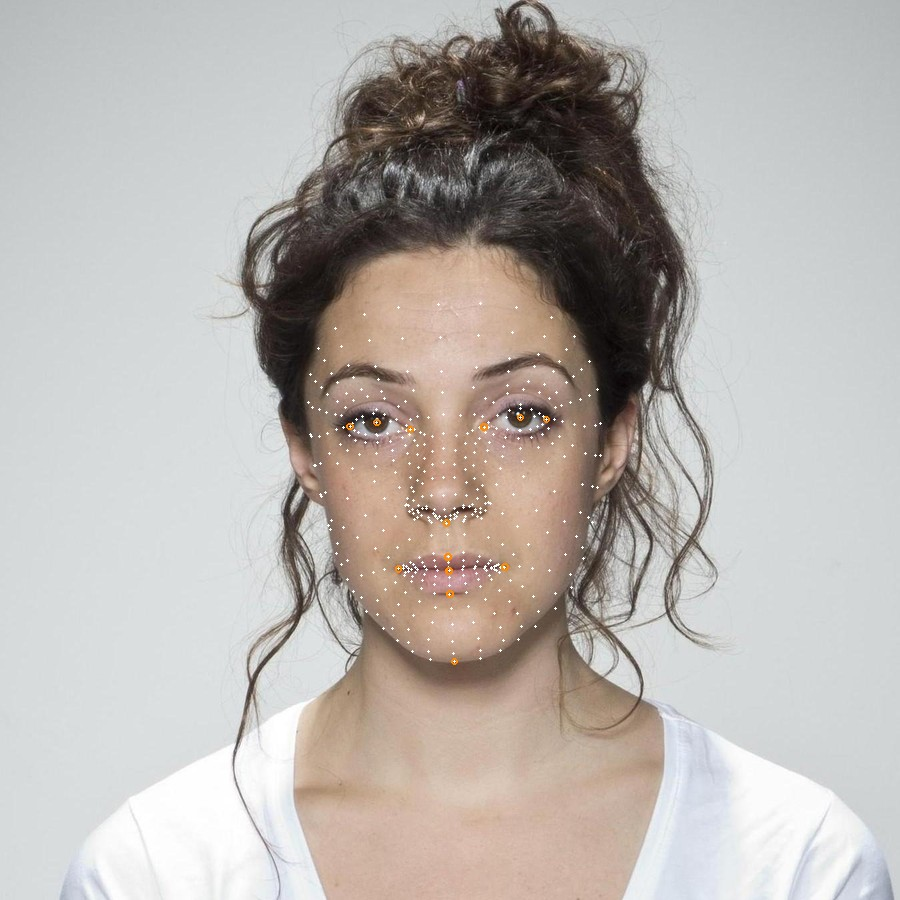

num_faces=2 on a collage of two composite faces -> /content/outputs/mediapipe_face_landmarker/6fc1c4b2efed/outputs/mediapipe_face_landmarker_two_faces_overlay.jpg


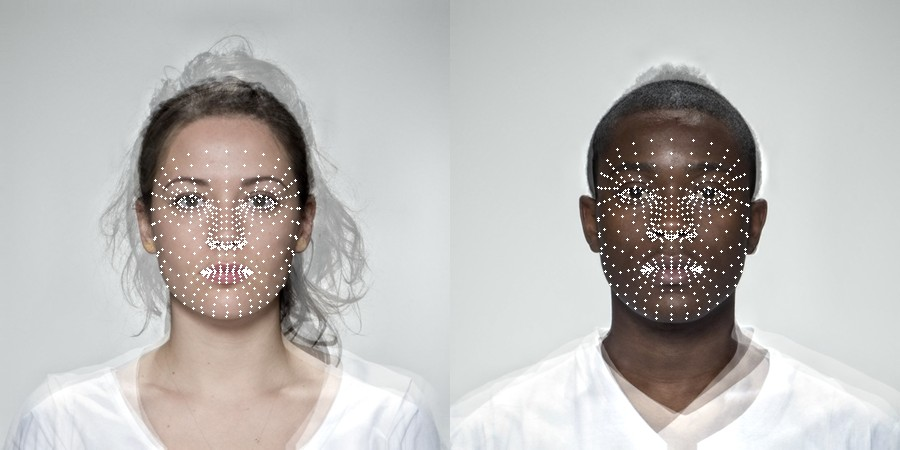

In [6]:
run_stage('inference')
show_image('mediapipe_face_landmarker_walkthrough_overlay.jpg', 'All 478 landmarks (white); the 14 evaluated points ringed in orange')
show_image('mediapipe_face_landmarker_two_faces_overlay.jpg', 'num_faces=2 on a collage of two composite faces')

**What to notice:** the input report, the configuration, one face, `landmarks_shape [478, 3]`, 52 blendshapes, a 4 × 4 matrix, three example landmark rows, the five strongest blendshapes, and the matrix — its upper-left 3 × 3 block is close to the identity because the face looks straight at the camera, and its last column holds the translation. `faces_returned` shows 1, then 2 faces on the collage, and 0 on the blank image: `num_faces` is a maximum, and "no face" is an empty result, not an error. The inference time is for one CPU call.

**Checkpoint:** a neutral face here still shows non-zero scores such as `browOuterUpLeft` around 0.6. Does that mean the person is raising an eyebrow with 60 % probability?

<details>
<summary>Check your reasoning (open after answering)</summary>

No. A blendshape score is a coefficient for an avatar rig — how much of a predefined deformation best reproduces this face's landmark geometry — not the probability that an expression is present. Part of every score reflects the person's resting facial shape (brow height, eye shape, lip shape) rather than any movement, which is why a neutral face is not all zeros. The scores are not calibrated, the pipeline applies no threshold to them, and comparing a score across different people mixes anatomy with expression. Section 8 therefore compares the **same person** in two photographs instead of reading one score in isolation.

</details>

## 6. Landmark accuracy against annotated faces · [Evaluation practice]

**Question tested:** how close are the model's landmarks to the dataset authors' annotations, and how much of that comes from the landmark network rather than from simply knowing where faces usually are?

The `evaluate` stage runs every one of the 102 neutral photographs once, with no selection. For each it takes the 14 MediaPipe points that have an annotated counterpart (`LANDMARK_MAP`: iris centres, eye corners, the base of the nose, mouth corners, four lip midpoints and the bottom of the chin) and computes the **NME**: the mean distance to the annotation divided by the **inter-ocular distance** from the annotation — the same normalisation as the upstream model card. Two baselines use no landmark network:

- **mean shape in the image** — the average annotated shape of the *other* 101 photographs, in pixels (these photographs are framed alike, so this is a stronger trivial baseline than it sounds);
- **mean shape in the detector box** — the same average expressed relative to a face box and placed in the box that the bundle's own face detector finds in this photograph.

The stage also breaks the error down by the participants' **self-reported** gender, ethnicity and age band. These groups are small; the breakdown shows where to look, not a fairness result.

**Predict before running:** will the model's mean NME be nearer 0.02, 0.05 or 0.10? Which of the 14 points do you expect to disagree most with the human annotation, and why?

Running stage 'evaluate' in the isolated environment; log: /content/outputs/mediapipe_face_landmarker/6fc1c4b2efed/logs/evaluate.log
{'model': {'images': 102, 'detected': 102, 'detection_rate': 1.0, 'nme_mean': 0.01937, 'nme_median': 0.0194, 'nme_std': 0.00355, 'nme_p90': 0.02449, 'nme_max': 0.02821, 'failure_rate_at_0.10': 0.0, 'nme_mean_bootstrap_95ci': (0.01868, 0.02006)}}
{'baseline_mean_shape_image': {'images': 102, 'detected': 102, 'detection_rate': 1.0, 'nme_mean': 0.1532, 'nme_median': 0.12684, 'nme_std': 0.09125, 'nme_p90': 0.25363, 'nme_max': 0.52274, 'failure_rate_at_0.10': 0.7059}}
{'baseline_mean_shape_detector_box': {'images': 102, 'detected': 102, 'detection_rate': 1.0, 'nme_mean': 0.0752, 'nme_median': 0.06602, 'nme_std': 0.03336, 'nme_p90': 0.1147, 'nme_max': 0.19401, 'failure_rate_at_0.10': 0.1961}}
{'per_point': {'point': 'chin_bottom_centre', 'template_index': 129, 'mediapipe_index': 152, 'mean_error_iod': 0.0389}}
{'per_point': {'point': 'subnasale', 'template_inde

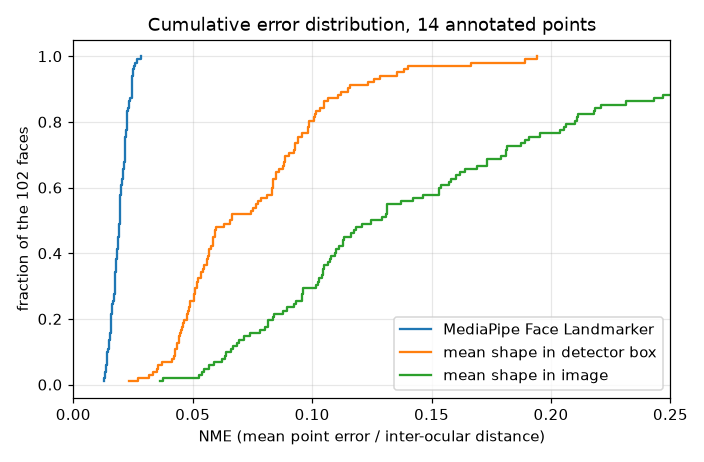

Top: three typical faces; bottom: the three largest errors. Orange rings: model; cyan crosses: annotation -> /content/outputs/mediapipe_face_landmarker/6fc1c4b2efed/outputs/mediapipe_face_landmarker_evaluation_examples.jpg


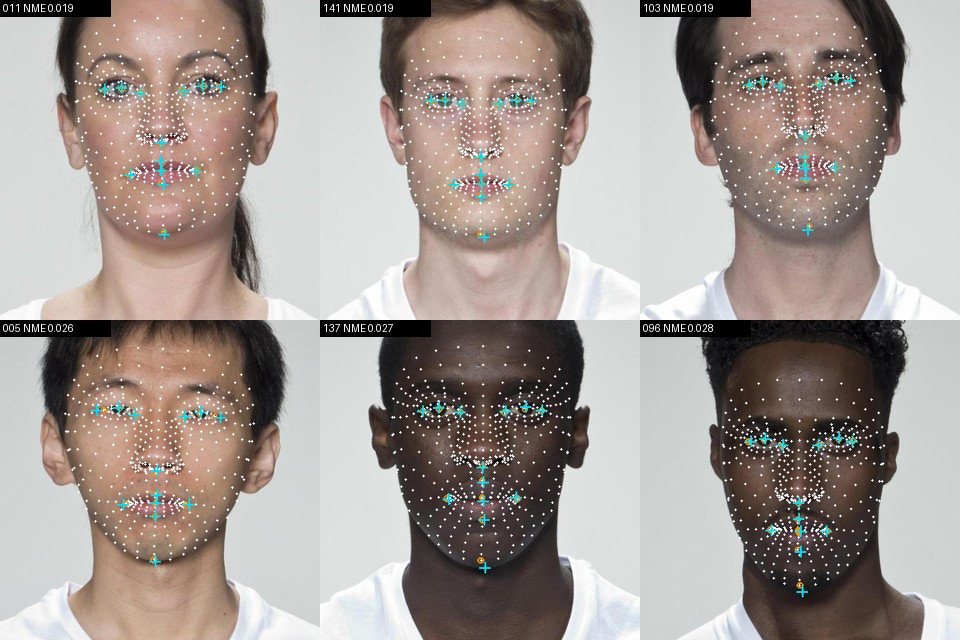

In [7]:
run_stage('evaluate')
show_image('mediapipe_face_landmarker_ced.png', 'Cumulative error distribution: the model and the two baselines')
show_image('mediapipe_face_landmarker_evaluation_examples.jpg', 'Top: three typical faces; bottom: the three largest errors. Orange rings: model; cyan crosses: annotation')

**What to notice:** the detection rate, the model's NME summary (mean, median, spread, 90th percentile, maximum, failure rate at 0.10 and a bootstrap interval for the mean over faces) beside the two baselines; the per-point errors, largest first; and the group tables with their sizes `n`. In the CED plot a curve further to the left is better. The per-image numbers are in `mediapipe_face_landmarker_evaluation_per_image.csv`.

*Photographs: Face Research Lab London Set, DeBruine & Jones (2017), CC BY 4.0; composite faces: DeBruine (2016), CC BY 4.0. The overlays drawn by this notebook are adaptations of those images.*

**Checkpoint:** the largest per-point errors are usually at the bottom of the chin and the base of the nose, not at the eyes. Is the model worst there, or is something else going on? And how should you read a group whose mean NME is a few thousandths higher than another's?

<details>
<summary>Check your reasoning (open after answering)</summary>

Part of every "error" is a **definition difference**: the annotators' "bottom centre of the chin" and MediaPipe point 152 are placed by different conventions, and on a soft contour such as the chin or the nose base a consistent offset of a few pixels is likely. Points on sharp, well-defined structures (lip midlines, inner eye corners) agree best. So the per-point table measures agreement with *this* annotation, not absolute truth; human annotators also disagree with each other (the upstream model card reports 2.56 % IOD between its own annotators). For the groups: each mean comes from 1 to 69 faces of studio photographs, one photograph per person, with no repeated runs. A difference of a few thousandths between groups of 13 and 69 faces is within what person-to-person variation can produce, and it cannot be attributed to the attribute itself — lighting, contrast, facial hair, the annotators and the point definitions all differ between faces. What you may say is "on this sample, group X had a mean NME of a, n = k"; a fairness claim needs a larger, purpose-built evaluation set. Both baselines are much worse than the model, which shows that the network, not the framing of the photographs, produces the accuracy.

</details>

## 7. Robustness under controlled perturbations · [Evaluation practice]

**Question tested:** when the same face is rotated, made smaller, blurred, darkened or brightened, or compressed, does the model still find it — and are the landmarks still in the right place?

The `robustness` stage takes the first 20 annotated faces and applies 15 settings with `perturb`, which also returns the exact geometric map from original to perturbed pixels. Each prediction is mapped back into the original coordinates and compared twice: with the prediction on the unperturbed photograph (**consistency NME** — does the output stay put?) and with the annotation (**annotation NME** — is it still right?). A face counts as a **failure** when it is detected but its annotation NME exceeds 0.10.

**Predict before running:** which will hurt more — downscaling to 12 % of the width, or rotating by 90°? And what do you expect at 180° (upside down): no detection, or something else?

Running stage 'robustness' in the isolated environment; log: /content/outputs/mediapipe_face_landmarker/6fc1c4b2efed/logs/robustness.log
{'perturbation': 'none', 'value': 0.0, 'faces': 20, 'detection_rate': 1.0, 'failure_rate_at_0.10': 0.0, 'consistency_nme_mean': 0.0, 'annotation_nme_mean': 0.02}
{'perturbation': 'rotate', 'value': 15.0, 'faces': 20, 'detection_rate': 1.0, 'failure_rate_at_0.10': 0.0, 'consistency_nme_mean': 0.0068, 'annotation_nme_mean': 0.0209}
{'perturbation': 'rotate', 'value': 30.0, 'faces': 20, 'detection_rate': 1.0, 'failure_rate_at_0.10': 0.0, 'consistency_nme_mean': 0.013, 'annotation_nme_mean': 0.024}
{'perturbation': 'rotate', 'value': 45.0, 'faces': 20, 'detection_rate': 1.0, 'failure_rate_at_0.10': 0.0, 'consistency_nme_mean': 0.022, 'annotation_nme_mean': 0.0305}
{'perturbation': 'rotate', 'value': 90.0, 'faces': 20, 'detection_rate': 1.0, 'failure_rate_at_0.10': 0.0, 'consistency_nme_mean': 0.0138, 'annotation_nme_mean': 0.0245}
{'perturbation': 'rotate

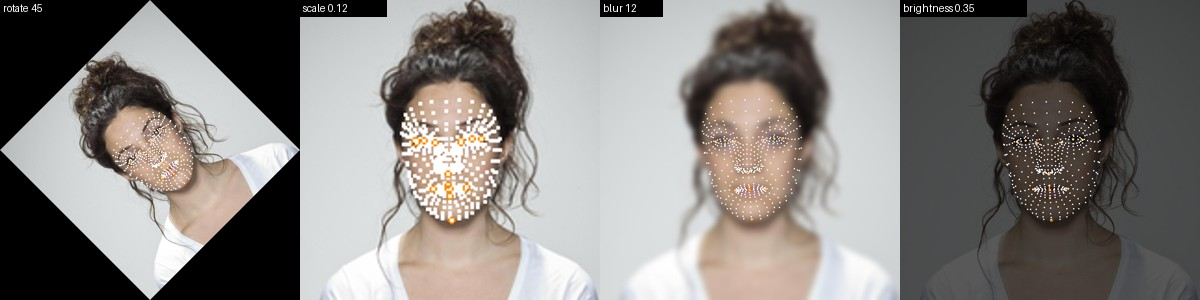

In [8]:
run_stage('robustness')
show_image('mediapipe_face_landmarker_robustness_examples.jpg', 'One face under four perturbations, with the predicted landmarks')

**What to notice:** one row per setting with the detection rate, the failure rate, and the two NMEs. Mild settings change the consistency NME by a fraction of the model's own error; strong blur and strong downscaling raise both. Look closely at the 180° row: the detector still reports faces on most images, but every one of them is a failure.

**Checkpoint:** why is a detection rate alone not enough to say that the model "works" on upside-down faces, and what would a deployment need to do about it?

<details>
<summary>Check your reasoning (open after answering)</summary>

A detection only says that the detector found something face-like; it does not say the 478 points are on the right features. At 180° the detector fires, but the mesh is fitted with the wrong orientation, so the landmarks land on the wrong parts of the face and the NME is far above 0.10 — a confident-looking wrong answer. The model returns no quality flag that would reveal this. A deployment that may see unusual orientations therefore needs its own check: restrict the input (for example, upright selfie video, which is what the model was designed for), add a plausibility test on the output geometry, or measure the failure rate on its own data. Note also that the perturbations are synthetic: a real face that is far away, out of focus or badly lit differs from a resized, blurred or darkened studio photograph, so these rows are a sanity check of sensitivity, not a field evaluation.

</details>

## 8. Blendshape sanity check on neutral and smiling photographs · [Concept]

**Question tested:** do the blendshape scores move in the direction a smile should move them? Blendshape scores have no ground truth in this sample, so this is a **sanity check**, not an evaluation.

The London Set photographed each of the 102 participants twice: with a neutral expression and smiling. The expression label comes from the dataset, not from the model. The `blendshapes` stage runs both photographs of every person and compares the **same person** across the pair, which removes most of the person-to-person differences in resting face shape. One expectation is stated before the stage runs: the mean of `mouthSmileLeft` and `mouthSmileRight` is higher on the smiling photograph. The stage reports how often that holds, the median paired difference, a **rank AUC** and a **sign test**. Five other scores — `cheekSquint`, `eyeSquint`, `eyeBlink`, `jawOpen` and `mouthClose` — are reported descriptively, with no expectation tested.

**Predict before running:** in how many of the 102 pairs will the smile score rise? And will `eyeBlink` stay flat between the two photographs, given that every participant has their eyes open in both?

Running stage 'blendshapes' in the isolated environment; log: /content/outputs/mediapipe_face_landmarker/6fc1c4b2efed/logs/blendshapes.log
{'pairs_with_a_face_in_both': 102, 'of': 102}
{'stated_expectation': 'mean(mouthSmileLeft, mouthSmileRight) is higher on the smiling photograph than on the neutral one', 'pairs': 102, 'expressive_higher': 102, 'fraction_expressive_higher': 1.0, 'median_neutral': 0.0016, 'median_expressive': 0.6378, 'median_paired_difference': 0.5724, 'rank_auc': 0.948, 'sign_test_p': 3.944304526105059e-31}
{'descriptive': 'cheekSquint', 'median_neutral': 0.0, 'median_smiling': 0.0, 'fraction_smiling_higher': 0.8039, 'rank_auc': 0.7505}
{'descriptive': 'eyeSquint', 'median_neutral': 0.2538, 'median_smiling': 0.367, 'fraction_smiling_higher': 0.8922, 'rank_auc': 0.7363}
{'descriptive': 'eyeBlink', 'median_neutral': 0.0898, 'median_smiling': 0.1312, 'fraction_smiling_higher': 0.9118, 'rank_auc': 0.6822}
{'descriptive': 'jawOpen', 'median_neutral': 0.0022, 'median_smili

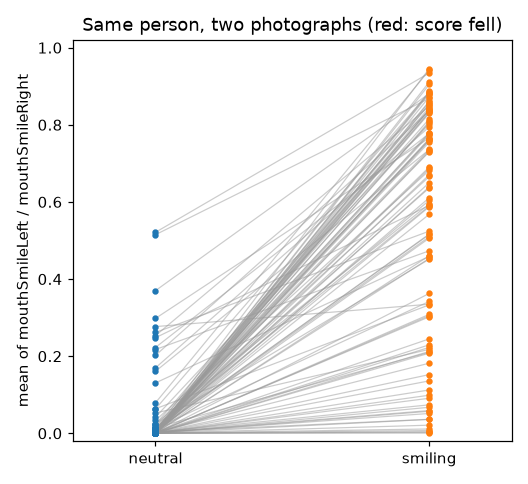

In [9]:
run_stage('blendshapes')
show_image('mediapipe_face_landmarker_smile_pairs.png', 'Smile score for each person, neutral vs smiling (grey: rose; red: fell)')

**What to notice:** the stated expectation with the share of pairs where it held, the medians, the rank AUC (0.5 is chance) and the sign-test p-value; then the descriptive scores. The paired values are in `mediapipe_face_landmarker_blendshapes_paired.csv`.

**Checkpoint:** `eyeBlink` usually rises on the smiling photographs although nobody blinked. Is that a model error? And does a rank AUC near 0.95 mean the smile score is a 95 %-accurate smile detector?

<details>
<summary>Check your reasoning (open after answering)</summary>

Not necessarily an error. A genuine smile raises the cheeks and narrows the eyes, so the eye opening really does shrink; a coefficient that measures eyelid closure from geometry will partly respond to it, and `eyeSquint` and `cheekSquint` rise for the same reason. That is why only one expectation was stated in advance and the others are described, not tested: looking at many scores and then picking the ones that moved would make chance findings look like confirmations. On the AUC: it says how well the smile score *ranks* smiling above neutral photographs in this studio set, where every smile is deliberate and the lighting is constant. It is not an accuracy, there is no threshold, and the scores are not probabilities; turning them into a smile/no-smile decision would need a threshold chosen and checked on data from the intended setting. The sign-test p-value only says that "higher in the pair" is very unlikely to be a coin flip on these 102 pairs.

</details>

## 9. New images and VIDEO mode · [Concept]

The `newdata` stage applies the same contract to images that played no part in Sections 6–8: ten composite faces, each the average of four London Set participants, so none of them is a real individual. It writes `mediapipe_face_landmarker_newdata_landmarks.csv`, `mediapipe_face_landmarker_newdata_blendshapes.csv`, `mediapipe_face_landmarker_newdata_matrices.json` and a contact sheet of overlays, and — because the composites carry annotations too — prints their NME.

Then it compares the two running modes on a 30-frame sequence made from one composite: the face rolls between −8° and +8°, so the true motion of every landmark is known. **IMAGE** mode runs the detector on every frame; **VIDEO** mode passes increasing timestamps and reuses the previous frame's landmarks to place the face region (tracking), which is how the model is meant to run on a camera stream. The error is the distance from the still-image prediction moved by the known rotation.

**Predict before running:** will VIDEO mode, which tracks the face from frame to frame, be closer to the known motion than IMAGE mode, or further from it?

Running stage 'newdata' in the isolated environment; log: /content/outputs/mediapipe_face_landmarker/6fc1c4b2efed/logs/newdata.log
{'image_id': 'composite/f_african', 'faces': 1, 'top_blendshapes': {'browOuterUpLeft': 0.531, 'mouthPucker': 0.478, 'browOuterUpRight': 0.357}, 'nme_vs_template': 0.0182}
{'image_id': 'composite/f_easian', 'faces': 1, 'top_blendshapes': {'eyeSquintLeft': 0.192, 'eyeSquintRight': 0.191, 'eyeLookInRight': 0.164}, 'nme_vs_template': 0.0157}
{'image_id': 'composite/f_multi', 'faces': 1, 'top_blendshapes': {'eyeSquintLeft': 0.227, 'eyeSquintRight': 0.19, 'browOuterUpLeft': 0.16}, 'nme_vs_template': 0.0129}
{'image_id': 'composite/f_wasian', 'faces': 1, 'top_blendshapes': {'mouthShrugLower': 0.397, 'mouthShrugUpper': 0.263, 'eyeSquintLeft': 0.209}, 'nme_vs_template': 0.0098}
{'image_id': 'composite/f_white', 'faces': 1, 'top_blendshapes': {'eyeSquintRight': 0.183, 'eyeSquintLeft': 0.178, 'eyeLookDownLeft': 0.15}, 'nme_vs_template': 0.014}
{'image_id': 'composite/

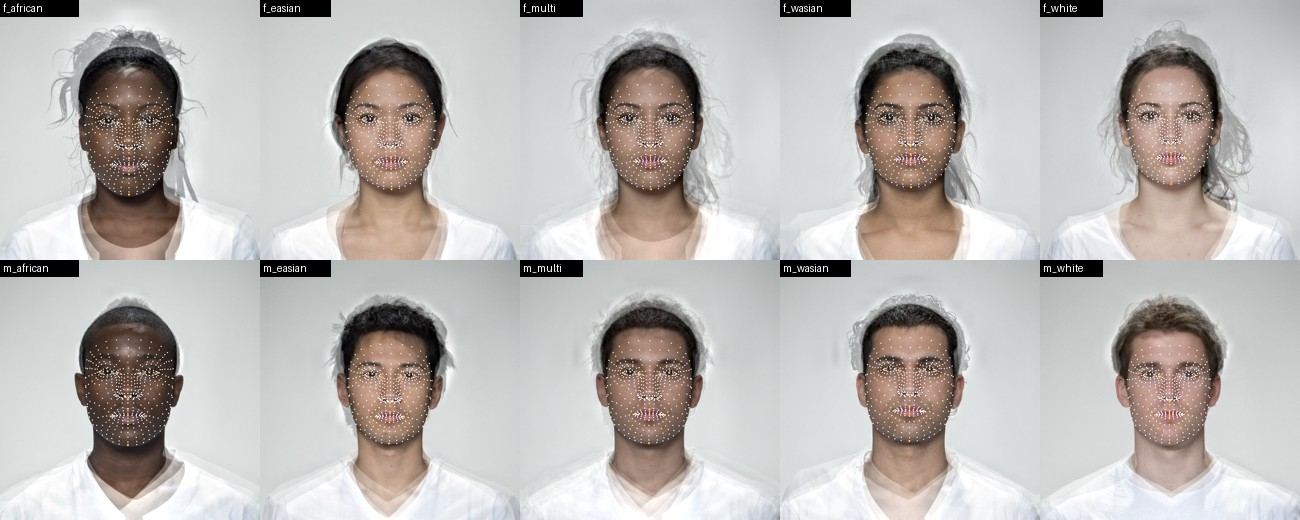

In [10]:
run_stage('newdata')
show_image('mediapipe_face_landmarker_newdata_overlays.jpg', 'New images: ten composite faces with their landmarks')

**What to notice:** one line per composite with its strongest blendshapes and its NME, a composite NME summary, the three written files, and the VIDEO-mode comparison: frames tracked, mean consistency NME and mean frame-to-frame change for each mode. Read your own numbers for the direction: on this synthetic roll, VIDEO mode may well follow the known motion *less* closely than IMAGE mode, because tracking places each frame's face region from the previous frame and can lag a rotation; its purpose is speed and stability on real camera streams, which a 30-frame synthetic sequence does not test. Composites are smoother than real faces and were built from the same population as Section 6, so their NME is a sanity check of the contract on new images, not evidence of generalisation.

*Photographs: Face Research Lab London Set, DeBruine & Jones (2017), CC BY 4.0; composite faces: DeBruine (2016), CC BY 4.0. The overlays drawn by this notebook are adaptations of those images.*

## 10. Export and provenance · [Engineering]

The `export` stage writes `mediapipe_face_landmarker_result.json` in the run's `outputs/`: the model identity (id, version, object generation, SHA-256, download URL, the four member digests, licence, and that nothing was unpickled and no remote code ran), the notebook's source revision, the runtime versions, the inference configuration, the sample repository, commit and manifest digest, and every summary from Sections 6–9 labelled as tutorial evidence. It then lists every file the run wrote with its size and digest. No artifact is produced: the bundle is used as published and nothing in this notebook changes it.

**Expected result:** the result path, the model id and revision, the runtime, and the file listing — CSV and JSON outputs, overlays and figures, and the per-stage JSON records.

In [11]:
run_stage('export')

Running stage 'export' in the isolated environment; log: /content/outputs/mediapipe_face_landmarker/6fc1c4b2efed/logs/export.log
{'result': '/content/outputs/mediapipe_face_landmarker/6fc1c4b2efed/outputs/mediapipe_face_landmarker_result.json', 'model': 'mediapipe-models/face_landmarker/face_landmarker', 'revision': '1683136941916318', 'sha256': '64184e229b263107…', 'runtime': {'python': '3.12.12', 'mediapipe': '1.0.0', 'numpy': '2.5.3', 'pillow': '12.3.0', 'machine': 'x86_64', 'cpu_count': 2, 'delegate': 'CPU (TFLite XNNPACK)'}}
{'file': 'blendshapes.json', 'bytes': 2112, 'sha256': '0823016bbe3162c2…'}
{'file': 'evaluation.json', 'bytes': 4444, 'sha256': 'e80f894d8ef975fd…'}
{'file': 'inference.json', 'bytes': 1092, 'sha256': '6418d57d89f4a163…'}
{'file': 'mediapipe_face_landmarker_blendshapes_paired.csv', 'bytes': 13785, 'sha256': 'ceddbd85cb0d092e…'}
{'file': 'mediapipe_face_landmarker_ced.png', 'bytes': 41023, 'sha256': 'cb0a420c6286622b…'}
{'file': 'mediapipe_face_landmarker_evalu

**What to notice:** every number this notebook printed is in a machine-readable file, and each file is traceable to the image, face and landmark ids it describes and to the exact bundle that produced it. This is the end of the canonical path.

## 11. Bring your own data (optional) · [Engineering]

This branch is **off by default** and never part of *Run all*: with `USE_BYOD = False` the next cell only prints how to switch it on. When it is on, your input goes through the same contract as the samples — `validate_image`, the same `FaceLandmarkerPipeline` configuration (IMAGE mode, confidence 0.5) and the same writers.

**What you can supply.** One image, or a zip of up to 20 images (flat or in folders; hidden files ignored; absolute paths, `..` and symlinks refused; at most 200 MB). Each image: any format Pillow decodes, 64..8192 px per side, at most 40,000,000 pixels and 50 MB; it is converted to RGB and an EXIF orientation applied, and both are reported. `BYOD_NUM_FACES` sets the maximum faces per image (1..10). A refusal stops the cell with a message naming the file and the rule.

**How.** Set `USE_BYOD = True`. Either set `BYOD_PATH` to a file already in the runtime (no dialog opens), or leave it empty in Colab to get an upload dialog for one file; each upload replaces the previous one. Outputs go to `outputs/byod/` in the run directory: `byod_landmarks.csv`, `byod_blendshapes.csv`, `byod_matrices.json`, `byod_overlays.jpg` and `byod_result.json`.

**Privacy.** Faces are personal data, and landmarks and blendshapes derived from them can be biometric data, which many jurisdictions protect specifically. Upload only images you are authorised to process in this runtime, preferably of people who have agreed to it. Do not upload confidential, restricted or regulated images. Your files and every output stay inside this runtime — `run_stage` runs locally and nothing is sent to any service — and they disappear when the runtime is recycled unless you download them. Delete them with the file browser when you are done.

In [12]:
USE_BYOD = False  # @param {type:"boolean"}
BYOD_PATH = ''  # @param {type:"string"}
BYOD_NUM_FACES = 1  # @param {type:"integer"}

if USE_BYOD:
    if BYOD_PATH:
        byod_path = Path(BYOD_PATH)
    else:
        from google.colab import files
        upload_dir = ROOT / 'byod_upload'
        shutil.rmtree(upload_dir, ignore_errors=True)
        upload_dir.mkdir(parents=True)
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError('Upload exactly one file: an image, or a zip of up to 20 images.')
        file_name, payload = next(iter(uploaded.items()))
        byod_path = upload_dir / Path(file_name).name
        byod_path.write_bytes(payload)
    run_stage('byod', '--byod', byod_path.resolve(), '--num-faces', BYOD_NUM_FACES)
    show_image('byod/byod_overlays.jpg', 'Your images with their landmarks')
else:
    print({'byod': 'skipped (optional)', 'to_run': 'set USE_BYOD = True, and BYOD_PATH to an image or zip in the runtime (or leave it empty for the Colab upload dialog), then run this cell'})

{'byod': 'skipped (optional)', 'to_run': 'set USE_BYOD = True, and BYOD_PATH to an image or zip in the runtime (or leave it empty for the Colab upload dialog), then run this cell'}


**What to notice:** the contract, one validation report per image (with any conversion), the faces found per image and their strongest blendshapes, the written files and `data_left_runtime: False`. Your images have no annotation, so there is no NME: what you can check is the overlay. Expect the model to work best on frontal, upright, well-lit faces that fill a reasonable part of the image — the setting of Sections 6–7.

## 12. Optional activity: change one thing — the rotation angle · [Concept]

**Predict → Change one thing → Run → Observe → Explain.** This activity is off by default and changes nothing the canonical path produced: with `RUN_ACTIVITY = False` the next cell only prints how to switch it on. It runs the `activity` stage, which repeats the Section 7 rotation test on the same 20 faces at one angle of your choice and prints it beside the Section 7 rows.

**Change one thing:** set `ACTIVITY_ROTATION` (degrees, −180..180; 120 by default) and `RUN_ACTIVITY = True`, then run the cell. Faces, bundle and settings stay fixed; only the angle changes.

**Predict before running:** Section 7 showed reliable results at 90° and failures at 180°. At 120°, will the detection rate drop, the failure rate rise, or both? Where between 90° and 180° do you expect the change?

In [13]:
RUN_ACTIVITY = False  # @param {type:"boolean"}
ACTIVITY_ROTATION = 120  # @param {type:"number"}

if RUN_ACTIVITY:
    run_stage('activity', '--rotation', ACTIVITY_ROTATION)
else:
    print({'activity': 'skipped (optional)', 'to_run': 'set RUN_ACTIVITY = True and ACTIVITY_ROTATION in -180..180, then run this cell'})

{'activity': 'skipped (optional)', 'to_run': 'set RUN_ACTIVITY = True and ACTIVITY_ROTATION in -180..180, then run this cell'}


**Observe:** the unperturbed row and the Section 7 rotation rows, then your angle with its detection rate, failure rate and the two NMEs.

**Explain:** did the result match your prediction? Try a second angle to bracket the change.

<details>
<summary>Check your reasoning (open after answering)</summary>

The detector estimates each face's rotation and the mesh network runs on an upright crop, so moderate rotations cost little. Somewhere beyond 90° the rotation estimate becomes unreliable and the mesh is fitted the wrong way up: detection often survives while the failure rate jumps, which is the pattern of Section 7's 180° row. The exact angle depends on the faces and on the bundle; with 20 faces each face is 5 % of a rate, so a change of one or two faces is within noise. Because only the angle changed, any difference is caused by it. The lesson transfers: a model can degrade by producing confident wrong output rather than by producing nothing, and only a check against ground truth or a plausibility test reveals it.

</details>

## Troubleshooting · [Engineering]

| Symptom | Likely cause | What to do |
|---|---|---|
| Section 1 stops with `This notebook needs a Linux x86_64 runtime` | a local Windows or macOS kernel, or an ARM machine | Use Google Colab, Kaggle, or a Linux x86_64 Jupyter kernel: the locked environment is built for manylinux x86_64 wheels. |
| Section 1 stops with `Not enough free disk` | the environment needs about 1.5 GB and the data about 0.2 GB | Start a fresh runtime; a `weights/` directory from an earlier run is reused and counted. |
| `Carried file integrity failure` in Section 2 | a carried file was edited in the notebook | Do not edit the infrastructure cells; open a fresh copy of the notebook from the repository. |
| `uv 0.12.15 wheel size/hash mismatch`, or a `URLError` / timeout while downloading it | a network failure or an unexpected response from PyPI | Re-run the Section 2 install cell. Never replace the pinned URL or digest. |
| `CalledProcessError` from `uv venv` or `uv pip install` (a hash mismatch, `Failed to download`, HTTP 5xx) | a transient PyPI or network failure | Re-run the Section 2 install cell: `uv` reuses what it already downloaded. If a hash mismatch repeats, stop and report it — never remove `--require-hashes`, a pin or a hash. |
| `RuntimeError: Stage '…' failed (exit 2): …` | the stage raised an error; the message after the colon is the stage's own error, its traceback is printed above it, and MediaPipe's native messages are in the run directory's `logs/<stage>.native.log` | Find the message in the rows below. A stage reads only files, so after fixing the cause you can re-run that cell and the cells after it. |
| `… is missing: run the stage that writes it before …` | a learner cell was run before an earlier stage | Run the notebook from the top, or re-run the earlier cells in order. |
| `the sample manifest changed since 'prepare'` | the carried files were regenerated mid-run | Re-run from Section 4. |
| A download error in Section 3, or `downloaded face_landmarker.task: … refusing it` | a transient Cloud Storage failure or a partial download | Re-run the Section 3 cell; nothing is written until the bytes match. |
| `ValueError: face_landmarker.task: size … != manifest …` or `sha256 … != manifest …` | a corrupted file in `weights/` | Delete `weights/mediapipe-face-landmarker-float16-v1/face_landmarker.task` and re-run the Section 3 cell. Never edit a manifest to get past a mismatch. |
| A sample fetch fails in Section 4 (`URLError`, HTTP 429, or `sample …: fetched … pinned …; refusing it`) | a network failure, rate limiting by `raw.githubusercontent.com`, or a changed file | Wait a minute and re-run the Section 4 cell; verified files are kept in `weights/face-samples/` and only missing ones are fetched. |
| `OSError: libEGL.so.1` or `libGLESv2.so.2: cannot open shared object file` in a stage | a different `mediapipe` build than the locked 1.0.0 (some releases link OpenGL ES libraries that minimal Linux images lack) | Keep the carried lock; do not change the `mediapipe` pin. |
| `ModuleNotFoundError: No module named 'google.colab'` with `USE_BYOD = True` | the upload dialog needs Google Colab | Set `BYOD_PATH` to a file already in the runtime, or use Colab for the upload. |
| `not a decodable image`, `each side must be within 64..8192 px`, `above the … ceiling` | a BYOD file outside the contract | Convert it to JPEG or PNG, or resize it, and try again. |
| `BYOD zip has an unsafe member path` or `holds … files` | an archive with absolute or `..` paths, symlinks, or more than 20 images | Re-create the zip with plain relative names and at most 20 images. |
| BYOD returns 0 faces | the face is too small, strongly turned or rotated, partly hidden, or there is no face | Try a frontal, upright photograph in which the face fills a larger part of the image; zero faces is a valid result, not an error. |

## Interpretation and limits · [Evaluation practice]

The question this notebook can answer is narrow: on 102 front-facing studio photographs, how well do 14 of the Face Landmarker's 478 points agree with the dataset authors' annotations, how does that compare with knowing only where faces usually are, how sensitive is it to simple image changes, and do its smile scores move in the right direction between two photographs of the same person? Your run answers each part in Sections 6–8; read the values there rather than from this text.

The numbers are tutorial / sanity evidence, not a benchmark. The 102 participants were photographed in one studio, facing the camera, under the same lighting; most are young adults, and 69 of 102 self-reported as white. Each measurement is one pass with no repeated runs, and only the mean NME carries an interval (a bootstrap over faces). 14 points are not 478: the forehead, cheeks, jaw line and iris contours are not checked. Part of each per-point error is a difference between the annotators' and MediaPipe's point definitions. The group breakdown has groups of 1 to 69 faces and cannot support a fairness conclusion; the upstream model card reports its own geographic, gender and skin-tone evaluation on 1,700 images, which this notebook does not reproduce. The perturbations are synthetic, the VIDEO-mode sequence is a synthetic roll, and the blendshape check tests one stated direction on deliberate studio smiles. Public sample faces may have been seen by the upstream model during training; that cannot be ruled out. Blendshape scores are not calibrated probabilities, and the pipeline sets no threshold on them.

Three things to carry to real data. **Measure on your own setting:** camera, distance, lighting, pose and the people in front of the camera all change the error; the upstream design target is a front-facing phone camera at arm's length. **A detection is not a correct result:** Section 7 showed faces detected with landmarks in the wrong place, and the model reports no quality flag that would catch it. **Faces are personal and biometric data:** this model does not identify anyone, but its outputs describe a person's face geometry and expressions; process them only with a lawful basis, keep them local where possible, and never use them to identify, profile or monitor people.

Successful execution proves that the recorded repository revision's pipeline modules and stage runner, carried in this standalone notebook and run in an isolated hash-locked environment, can stage and digest-verify the pinned task bundle, fetch and validate digest-pinned public face photographs, run the landmarker in IMAGE and VIDEO modes on the CPU, evaluate 14 landmarks against annotations beside two baselines, measure robustness and blendshape direction, and emit the shown machine-readable outputs and provenance — without the repository being reachable. It does **not** establish benchmark superiority, production fitness, fairness across demographic groups, or accuracy on faces unlike the ones shown.

## Conclude with evidence · [Evaluation practice]

Complete this in your own words, using the numbers your run printed:

> On [102 neutral studio photographs of the London Set / your own annotated images], the MediaPipe Face Landmarker (task bundle version float16/1, object generation 1683136941916318) detected [detection rate] of the faces and placed 14 annotated landmarks with a mean NME of [mean] (median [median], 90th percentile [p90]), against [baseline] for the mean shape in the detector box and [baseline] for the mean shape in the image. The largest per-point disagreement was at [point]. Under perturbation, [setting] was the first to produce failures, and at 180° [what happened]. The smile score was higher on the smiling photograph in [k] of [n] pairs. The most important failure mode or uncertainty is [for example: confident wrong landmarks on upside-down faces; small groups; one studio setting]. These numbers do not show [accuracy in my deployment / fairness across groups / that blendshape scores are probabilities / ...]. Next I would [specific next experiment].

<details>
<summary>Check your reasoning: what makes a conclusion strong? (open after writing yours)</summary>

A strong conclusion names the data (102 front-facing studio photographs, one per person), the measure (NME over 14 points, normalised by the annotated inter-ocular distance) and both baselines beside the model's number. It keeps the measured landmark accuracy apart from the sanity checks (perturbations, blendshape direction, VIDEO mode), and it says that blendshape scores are not probabilities. It states the main failure mode — detected faces with wrong landmarks at large rotations — and the limits: one studio, small groups, synthetic perturbations, possible training overlap. It does not generalise to other cameras, poses or populations and makes no fairness claim. It ends with a specific next step, such as annotating a sample from the intended setting. A weak conclusion says only that "the model is accurate and robust".

</details>

**Transfer:** switch on BYOD (Section 11) with frontal photographs from your own intended setting — a webcam, a phone camera, a document photo — that you are authorised to use. Before running, predict which of Section 7's perturbations your images resemble most, and check the overlays for landmarks that are detected but misplaced.

## References

- Bazarevsky, V., Kartynnik, Y., Vakunov, A., Raveendran, K., & Grundmann, M. (2019). *BlazeFace: Sub-millisecond neural face detection on mobile GPUs* (arXiv:1907.05047). arXiv. https://doi.org/10.48550/arXiv.1907.05047
- DeBruine, L. (2016). *Young adult composite faces* [Data set]. figshare. https://doi.org/10.6084/m9.figshare.4055130.v1
- DeBruine, L., & Jones, B. (2017). *Face Research Lab London Set* (Version 5) [Data set]. figshare. https://doi.org/10.6084/m9.figshare.5047666.v5
- Google. (2023). *MediaPipe Face Landmarker task bundle `face_landmarker.task`, float16, version 1* [Model]. https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task
- Grishchenko, I., Ablavatski, A., Kartynnik, Y., Raveendran, K., & Grundmann, M. (2020). *Attention Mesh: High-fidelity face mesh prediction in real-time* (arXiv:2006.10962). arXiv. https://doi.org/10.48550/arXiv.2006.10962
- Kartynnik, Y., Ablavatski, A., Grishchenko, I., & Grundmann, M. (2019). *Real-time facial surface geometry from monocular video on mobile GPUs* (arXiv:1907.06724). arXiv. https://doi.org/10.48550/arXiv.1907.06724
- Lugaresi, C., Tang, J., Nash, H., McClanahan, C., Uboweja, E., Hays, M., Zhang, F., Chang, C.-L., Yong, M. G., Lee, J., Chang, W.-T., Hua, W., Georg, M., & Grundmann, M. (2019). *MediaPipe: A framework for building perception pipelines* (arXiv:1906.08172). arXiv. https://doi.org/10.48550/arXiv.1906.08172
- Sagonas, C., Antonakos, E., Tzimiropoulos, G., Zafeiriou, S., & Pantic, M. (2016). 300 Faces In-The-Wild Challenge: Database and results. *Image and Vision Computing, 47*, 3–18. https://doi.org/10.1016/j.imavis.2016.01.002 (the NME and failure-rate conventions)
- Upstream model cards: MediaPipe Face Mesh V2 (https://storage.googleapis.com/mediapipe-assets/Model%20Card%20MediaPipe%20Face%20Mesh%20V2.pdf), MediaPipe Blendshape V2 (https://storage.googleapis.com/mediapipe-assets/Model%20Card%20Blendshape%20V2.pdf), BlazeFace short range (https://storage.googleapis.com/mediapipe-assets/MediaPipe%20BlazeFace%20Model%20Card%20(Short%20Range).pdf)
- Upstream source: https://github.com/google-ai-edge/mediapipe (Apache-2.0)
- Repository README: https://github.com/kurtvalcorza/mediapipe-face-landmarker-pipeline/blob/main/README.md
- Repository model card: https://github.com/kurtvalcorza/mediapipe-face-landmarker-pipeline/blob/main/MODEL_CARD.md
- Weights notes: https://github.com/kurtvalcorza/mediapipe-face-landmarker-pipeline/blob/main/docs/WEIGHTS.md
- uv (the installer that builds the isolated environment): https://docs.astral.sh/uv/
- DIMER Notebook Specification 2.2 and Model Card Specification 1.2 (in the ml-worker repository)